In [1]:
import fitness_landscape as fl
import os
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt

### DMS and Megascale folding dataset

In [26]:
# Prepare file list
file_list = os.listdir('../data_files/megascale_folding/')
file_list = [file for file in file_list if file != '.DS_Store' or not file.startswith('megascale_folding_tmap')]
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/megascale_folding', file))

    # Extract sequence objects
    sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
    fitness = np.array(df['DMS_score'])

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences)}

    # Construct fitness landscape with Hamming graph for DMS data
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="hamming",
    )

    # Attach fitness values
    layer_name = f"dms_score"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Check if there is more than a single connected component and skip if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):
        continue
        # landscape = landscape.get_components()[0]


    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior='uniform')

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

16it [00:18,  1.01s/it]/home/matthew-spence/graph-ruggedness-de/landscapy/src/fitness_landscape/transforms/eigenmode.py:87: RuntimeWarning: Computing all eigenpairs for a large graph; this may be slow or memory-intensive. Pass k to compute a truncated basis instead.
  warnings.warn(
31it [00:40,  1.15it/s]/home/matthew-spence/graph-ruggedness-de/landscapy/src/fitness_landscape/transforms/eigenmode.py:87: RuntimeWarning: Computing all eigenpairs for a large graph; this may be slow or memory-intensive. Pass k to compute a truncated basis instead.
  warnings.warn(
64it [01:13,  1.15s/it]


ParserError: Error tokenizing data. C error: Expected 1 fields in line 23, saw 3


In [27]:
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")
out_json = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)


In [2]:
# Reload results
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")

with open(out_pkl, "rb") as f:
    results = pickle.load(f)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Build dataframe
# -----------------------------
rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": r["tmap"]["t_map"],
        "t_lo": r["tmap"]["t_lower_confidence_interval"],
        "t_hi": r["tmap"]["t_upper_confidence_interval"],
    })

df = pd.DataFrame(rows)

# Coerce numeric + drop non-finite
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t", "t_lo", "t_hi"]).reset_index(drop=True)

# -----------------------------
# Fix CI ordering (ensure lo <= hi)
# -----------------------------
lo = np.minimum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
hi = np.maximum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
df["t_lo"] = lo
df["t_hi"] = hi

# -----------------------------
# Drop poorly fitted datasets (avoid div-by-zero)
# -----------------------------
eps = 1e-300  # tiny, only to avoid division by zero
poor_fit = ((df["t_hi"] / np.maximum(df["t_lo"], eps)) >= 10.0) & (df["t_hi"] > 1.0)
df = df.loc[~poor_fit].reset_index(drop=True)

# -----------------------------
# Ensure t is inside [lo, hi]
# Boundary MAP values (e.g., t=1e-10) can fall just outside profile CI due to
# grid resolution / interpolation artifacts. Keep rows and expand CI to include t.
# -----------------------------
bad_low = df["t"] < df["t_lo"]
bad_high = df["t"] > df["t_hi"]
bad = bad_low | bad_high

df["ci_was_adjusted"] = bad

if bad.any():
    print("Rows where t is outside [t_lo, t_hi] (boundary-adjusting CI to include t):")
    print(df.loc[bad, ["dataset", "t", "t_lo", "t_hi"]])

    # Expand interval only as much as needed to include t.
    df.loc[bad_low, "t_lo"] = df.loc[bad_low, "t"]
    df.loc[bad_high, "t_hi"] = df.loc[bad_high, "t"]

    print(f"Adjusted CI bounds for {int(bad.sum())} datasets; no rows dropped.")

# -----------------------------
# Sort by t descending
# -----------------------------
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# -----------------------------
# Asymmetric error bars (guaranteed non-negative now)
# -----------------------------
t = df["t"].to_numpy()
t_lo = df["t_lo"].to_numpy()
t_hi = df["t_hi"].to_numpy()
yerr = np.vstack([t - t_lo, t_hi - t])


Rows where t is outside [t_lo, t_hi] (boundary-adjusting CI to include t):
        dataset         t      t_lo      t_hi
0    AMFR-HUMAN  5.109929  4.847684  5.103205
1    ARGR-ECOLI  3.315492  3.046233  3.312086
2    BBC1-YEAST  4.116057  3.904829  4.111081
3    BCHB-CHLTE  4.116057  3.904921  4.114803
4    CATR-CHLRE  4.116057  3.718396  4.109187
5   CBPA2-HUMAN  4.840960  4.592519  4.834590
6    CBX4-HUMAN  5.109929  4.847627  5.103203
7    CSN4-MOUSE  4.840960  4.397327  4.833764
8    CUE1-YEAST  4.116057  3.714552  4.108821
10  DNJA1-HUMAN  5.393842  5.117027  5.386744
11  DOCK1-MOUSE  4.344750  4.121775  4.339062
12  EPHB2-HUMAN  4.840960  4.592519  4.834590
13   FECA-ECOLI  3.694151  3.457350  3.689132
14  FKBP3-HUMAN  3.315492  2.999122  3.310497
15    HCP-LAMBD  3.499704  3.214488  3.495911
16  HECD1-HUMAN  5.693530  5.401334  5.686038
18   ISDH-STAAW  4.344750  4.119483  4.338974
19   MAFG-MOUSE  4.586149  4.138138  4.578005
20  MBD11-ARATH  5.393842  4.970530  5.386356
21   

## Robustness and mechanism follow-ups for Figure 2 (36 DMS domains)

The cells below add five reviewer-oriented checks on the same 36-domain subset used in the main bar plot:

1. Null permutation model for `t_MAP` (small initial `n_perm`, focused on smoothest and most rugged domains).
2. Regression of `t_MAP` against per-domain fitness-distribution summaries.
3. Regression of `t_MAP` against simple structure-derived predictors from each domain's PDB entry.
4. Graph-size robustness by downsampling each domain to the smallest number of measured variants.
5. Control analysis showing whether leading SVD axes map onto distinct amino-acid preference profiles and structural predictors, rather than a single thermodynamic function projected across heterogeneous regions.

Note: replicate counts are intentionally small for iteration speed. Increase these for final statistics.


In [4]:
from pathlib import Path
import re
import requests
from scipy.spatial.distance import pdist, squareform
from scipy.stats import skew, percentileofscore, spearmanr, pearsonr, linregress, f as f_dist, wilcoxon
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DMS_DIR = Path('../data_files/megascale_folding')
PDB_CACHE_DIR = Path('../data_files/pdb_cache')
PDB_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_dms_tmap_table(results, apply_poor_fit_filter=True, clamp_ci_to_t=True, verbose=True):
    rows = []
    for r in results:
        file_name = r['file']
        dataset = '-'.join(file_name.replace('.csv', '').split('_')[0:2])
        rows.append({
            'dataset': dataset,
            'file': file_name,
            'filepath': str(DMS_DIR / file_name),
            'n_sequences': int(r.get('n_sequences', np.nan)),
            't': float(r['tmap']['t_map']),
            't_lo': float(r['tmap']['t_lower_confidence_interval']),
            't_hi': float(r['tmap']['t_upper_confidence_interval']),
        })

    table = pd.DataFrame(rows)
    n_raw = len(table)

    for c in ['t', 't_lo', 't_hi']:
        table[c] = pd.to_numeric(table[c], errors='coerce')

    table = table.replace([np.inf, -np.inf], np.nan).dropna(subset=['t', 't_lo', 't_hi']).reset_index(drop=True)
    n_after_finite = len(table)

    lo = np.minimum(table['t_lo'].to_numpy(), table['t_hi'].to_numpy())
    hi = np.maximum(table['t_lo'].to_numpy(), table['t_hi'].to_numpy())
    table['t_lo'] = lo
    table['t_hi'] = hi

    eps = 1e-300
    poor_fit = ((table['t_hi'] / np.maximum(table['t_lo'], eps)) >= 10.0) & (table['t_hi'] > 1.0)
    table['poor_fit'] = poor_fit

    if apply_poor_fit_filter:
        table = table.loc[~poor_fit].reset_index(drop=True)

    bad_low = table['t'] < table['t_lo']
    bad_high = table['t'] > table['t_hi']
    bad = bad_low | bad_high
    table['ci_was_adjusted'] = bad

    if clamp_ci_to_t:
        table.loc[bad_low, 't_lo'] = table.loc[bad_low, 't']
        table.loc[bad_high, 't_hi'] = table.loc[bad_high, 't']

    if verbose:
        n_poor = int(poor_fit.sum())
        n_ci = int(bad.sum())
        print(
            f'Table build counts: raw={n_raw}, after_finite={n_after_finite}, '
            f'poor_fit_removed={n_poor if apply_poor_fit_filter else 0}, '
            f'ci_adjusted={n_ci}, final={len(table)}'
        )
        if n_ci > 0:
            print('CI-adjusted examples (first 10):')
            print(table.loc[bad, ['dataset', 't', 't_lo', 't_hi']].head(10))

    table = table.sort_values('t', ascending=False).reset_index(drop=True)
    return table


def regression_global_f_pvalue(y_true, y_pred, n_features):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)
    p = int(n_features)

    if n <= p + 1 or n < 3:
        return np.nan, np.nan

    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_reg = ss_tot - ss_res

    if not np.isfinite(ss_tot) or ss_tot <= 0:
        return np.nan, np.nan

    df_model = p
    df_resid = n - p - 1

    if df_model <= 0 or df_resid <= 0:
        return np.nan, np.nan

    ms_reg = ss_reg / df_model
    ms_res = ss_res / df_resid

    if ms_res <= 0:
        if ms_reg > 0:
            return np.inf, 0.0
        return np.nan, np.nan

    f_stat = ms_reg / ms_res
    p_value = float(f_dist.sf(f_stat, df_model, df_resid))
    return float(f_stat), p_value


dms_tmap_df = build_dms_tmap_table(results, apply_poor_fit_filter=False, clamp_ci_to_t=True, verbose=True)
print(f'Retained domains after Figure 2 filtering: {len(dms_tmap_df)}')
dms_tmap_df.head()


Table build counts: raw=63, after_finite=63, poor_fit_removed=0, ci_adjusted=51, final=63
CI-adjusted examples (first 10):
        dataset         t      t_lo      t_hi
0    AMFR-HUMAN  5.109929  4.847684  5.109929
1    ARGR-ECOLI  3.315492  3.046233  3.315492
2    BBC1-YEAST  4.116057  3.904829  4.116057
3    BCHB-CHLTE  4.116057  3.904921  4.116057
4    CATR-CHLRE  4.116057  3.718396  4.116057
5   CBPA2-HUMAN  4.840960  4.592519  4.840960
6    CBX4-HUMAN  5.109929  4.847627  5.109929
7    CSN4-MOUSE  4.840960  4.397327  4.840960
8    CUE1-YEAST  4.116057  3.714552  4.116057
10  DNJA1-HUMAN  5.393842  5.117027  5.393842
Retained domains after Figure 2 filtering: 63


,dataset,file,filepath,n_sequences,t,t_lo,t_hi,poor_fit,ci_was_adjusted
0,POLG-PESV,POLG_PESV_Tsuboyama_2023_2MXD.csv,../data_files/megascale_folding/POLG_PESV_Tsub...,5131,6.343783,6.018216,6.343783,False,True
1,SDA-BACSU,SDA_BACSU_Tsuboyama_2023_1PV0.csv,../data_files/megascale_folding/SDA_BACSU_Tsub...,2771,6.009869,5.701438,6.009869,False,True
2,HECD1-HUMAN,HECD1_HUMAN_Tsuboyama_2023_3DKM.csv,../data_files/megascale_folding/HECD1_HUMAN_Ts...,5587,5.693530,5.401334,5.693530,False,True
3,YNZC-BACSU,YNZC_BACSU_Tsuboyama_2023_2JVD.csv,../data_files/megascale_folding/YNZC_BACSU_Tsu...,2301,5.693530,5.401328,5.693530,False,True
4,OBSCN-HUMAN,OBSCN_HUMAN_Tsuboyama_2023_1V1C.csv,../data_files/megascale_folding/OBSCN_HUMAN_Ts...,3198,5.393842,5.117027,5.393842,False,True


In [5]:
import re
from unittest.mock import patch
MUT_TOKEN_RE = re.compile(r'([A-Z])(\d+)([A-Z\*])')


def load_domain_dataframe(file_name):
    domain_df = pd.read_csv(DMS_DIR / file_name)
    domain_df = domain_df.replace([np.inf, -np.inf], np.nan)
    domain_df = domain_df.dropna(subset=['mutated_sequence', 'DMS_score']).reset_index(drop=True)
    return domain_df


def build_hamming_landscape_from_df(domain_df):
    sequences = [fl.BaseNumpySequence(seq) for seq in domain_df['mutated_sequence']]
    fitness = domain_df['DMS_score'].to_numpy(dtype=float)

    landscape = fl.FitnessLandscape.build(
        sequences,
        graph='hamming',
    )

    if not nx.is_connected(landscape.graph):
        raise ValueError('Sampled landscape is disconnected.')

    return landscape, fitness


def compute_tmap_on_landscape_values(
    landscape,
    values,
    eigenvalues=None,
    eigenvectors=None,
    layer_name='tmp_layer',
    detach=True,
    t_min=1e-10,
    t_max=1e2,
    prior='uniform',
):
    values = np.asarray(values, dtype=float)
    landscape.attach(name=layer_name, values=values, dtype='numeric')
    landscape.view(layer_name)

    tmap_kwargs = {
        't_min': t_min,
        't_max': t_max,
        'prior': prior,
    }

    # Reuse precomputed graph-spectrum basis when provided.
    if eigenvalues is not None and eigenvectors is not None:
        tmap_kwargs['_eigenvalues'] = np.asarray(eigenvalues, dtype=float)
        tmap_kwargs['_eigenvectors'] = np.asarray(eigenvectors, dtype=float)

    try:
        tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
            landscape,
            **tmap_kwargs,
        )
    finally:
        if detach:
            landscape.detach(layer_name)

    return float(tmap_res['t_map'])


class _TMapPermutationStatistic:
    def __init__(
        self,
        landscape,
        *,
        eigenvalues=None,
        eigenvectors=None,
        layer_prefix='perm',
        t_min=1e-10,
        t_max=1e2,
        prior='uniform',
    ):
        self.landscape = landscape
        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        self.layer_prefix = layer_prefix
        self.t_min = t_min
        self.t_max = t_max
        self.prior = prior
        self.calls = 0
        self.null_samples = []

    def __call__(self, left, right):
        values = np.concatenate([
            np.asarray(left, dtype=float),
            np.asarray(right, dtype=float),
        ])
        t_val = compute_tmap_on_landscape_values(
            self.landscape,
            values,
            eigenvalues=self.eigenvalues,
            eigenvectors=self.eigenvectors,
            layer_name=f'{self.layer_prefix}_{self.calls}',
            detach=True,
            t_min=self.t_min,
            t_max=self.t_max,
            prior=self.prior,
        )

        if self.calls > 0:
            self.null_samples.append(float(t_val))

        self.calls += 1
        return float(t_val)


def run_tmap_permutation_test(
    landscape,
    fitness,
    *,
    n_permutations,
    seed=None,
    rng=None,
    eigenvalues=None,
    eigenvectors=None,
    layer_prefix='perm',
    t_min=1e-10,
    t_max=1e2,
    prior='uniform',
):
    fitness = np.asarray(fitness, dtype=float)

    if fitness.ndim != 1:
        raise ValueError('fitness must be one-dimensional.')
    if len(fitness) == 0:
        raise ValueError('fitness must contain at least one value.')
    if seed is not None and rng is not None:
        raise ValueError('Provide either seed or rng, not both.')
    if int(n_permutations) < 0:
        raise ValueError('n_permutations must be non-negative.')

    n_permutations = int(n_permutations)

    if len(fitness) == 1:
        observed_t = compute_tmap_on_landscape_values(
            landscape,
            fitness,
            eigenvalues=eigenvalues,
            eigenvectors=eigenvectors,
            layer_name=f'{layer_prefix}_observed',
            detach=True,
            t_min=t_min,
            t_max=t_max,
            prior=prior,
        )
        return {
            'observed_t_map': float(observed_t),
            'null_samples': [float(observed_t)] * n_permutations,
            'landscapy_result': None,
        }

    statistic = _TMapPermutationStatistic(
        landscape,
        eigenvalues=eigenvalues,
        eigenvectors=eigenvectors,
        layer_prefix=layer_prefix,
        t_min=t_min,
        t_max=t_max,
        prior=prior,
    )

    groups = {
        'left': fitness[:1].copy(),
        'right': fitness[1:].copy(),
    }

    default_rng_factory = np.random.default_rng

    if rng is not None:
        with patch.object(
            np.random,
            'default_rng',
            side_effect=lambda *args, **kwargs: (
                rng if len(args) == 0 and len(kwargs) == 0
                else default_rng_factory(*args, **kwargs)
            ),
        ):
            result = fl.analysis.permutation_test(
                groups=groups,
                statistic_func=statistic,
                n_permutations=n_permutations,
                alternative='two-sided',
            )
    elif seed is not None:
        with patch.object(
            np.random,
            'default_rng',
            side_effect=lambda *args, **kwargs: (
                default_rng_factory(seed) if len(args) == 0 and len(kwargs) == 0
                else default_rng_factory(*args, **kwargs)
            ),
        ):
            result = fl.analysis.permutation_test(
                groups=groups,
                statistic_func=statistic,
                n_permutations=n_permutations,
                alternative='two-sided',
            )
    else:
        result = fl.analysis.permutation_test(
            groups=groups,
            statistic_func=statistic,
            n_permutations=n_permutations,
            alternative='two-sided',
        )

    pair_result = next(iter(result.values()))
    return {
        'observed_t_map': float(pair_result['observed']),
        'null_samples': [float(x) for x in statistic.null_samples],
        'landscapy_result': pair_result,
    }


def infer_wildtype_sequence(domain_df):
    wt_seq = list(domain_df['mutated_sequence'].iloc[0])

    if 'mutant' not in domain_df.columns:
        return ''.join(wt_seq)

    for mutant in domain_df['mutant'].astype(str):
        for token in mutant.split(':'):
            match = MUT_TOKEN_RE.fullmatch(token.strip())
            if not match:
                continue

            wt_aa, pos_str, _ = match.groups()
            idx = int(pos_str) - 1

            if 0 <= idx < len(wt_seq):
                wt_seq[idx] = wt_aa

    return ''.join(wt_seq)


def estimate_wt_fitness(domain_df):
    if 'mutant' in domain_df.columns:
        wt_mask = domain_df['mutant'].astype(str).str.upper().eq('WT')
        if wt_mask.any():
            return float(domain_df.loc[wt_mask, 'DMS_score'].iloc[0]), 'explicit_wt_row'

    wt_seq = infer_wildtype_sequence(domain_df)
    seq_mask = domain_df['mutated_sequence'].astype(str).eq(wt_seq)
    if seq_mask.any():
        return float(domain_df.loc[seq_mask, 'DMS_score'].iloc[0]), 'inferred_wt_sequence'

    # ProteinGym substitution sets are often centered around WT ~= 0.
    return 0.0, 'assumed_zero'


def domain_fitness_summary(domain_df):
    values = domain_df['DMS_score'].to_numpy(dtype=float)
    wt_score, wt_source = estimate_wt_fitness(domain_df)

    mean_val = float(values.mean())
    std_val = float(values.std(ddof=0))

    return {
        'fitness_mean': mean_val,
        'fitness_variance': float(values.var(ddof=0)),
        'fitness_skewness': float(skew(values, bias=False, nan_policy='omit')) if len(values) >= 3 else np.nan,
        'wt_score': wt_score,
        'wt_score_source': wt_source,
        'wt_minus_mean': wt_score - mean_val,
        'wt_zscore': (wt_score - mean_val) / std_val if std_val > 0 else np.nan,
        'wt_percentile': float(percentileofscore(values, wt_score, kind='mean')),
        'n_variants': int(len(values)),
    }


In [36]:
# 1) Null model: permute fitness values on the fixed Hamming graph.
# Small initial replicate count for quick iteration.
PERMUTATION_REPS = 100
TAIL_SIZE = 1  # smoothest and rugged tails to evaluate first
rng = np.random.default_rng(123)

from fitness_landscape.transforms.eigenmode import eigenmode_decomposition

connected_perm_rows = []
skipped_perm_files = []
for row in dms_tmap_df.itertuples(index=False):
    try:
        domain_df = load_domain_dataframe(row.file)
        build_hamming_landscape_from_df(domain_df)
    except ValueError:
        skipped_perm_files.append(row.file)
        continue
    connected_perm_rows.append(row._asdict())

connected_perm_df = pd.DataFrame(connected_perm_rows).sort_values('t', ascending=False).reset_index(drop=True)
print(
    f'Using {len(connected_perm_df)} connected domains for permutation tests; '
    f'skipped {len(skipped_perm_files)} disconnected domains.'
)

selected_perm_domains = pd.concat(
    [connected_perm_df.head(TAIL_SIZE), connected_perm_df.tail(TAIL_SIZE)],
    axis=0,
).drop_duplicates(subset='file').reset_index(drop=True)

perm_rows = []
for row in tqdm(selected_perm_domains.itertuples(index=False), total=len(selected_perm_domains), desc='Permutation tests'):
    domain_df = load_domain_dataframe(row.file)
    landscape, fitness = build_hamming_landscape_from_df(domain_df)

    # Graph topology is fixed across permutations for this domain; compute spectrum once.
    eigvals, eigvecs = eigenmode_decomposition(
        landscape,
        matrix='norm_laplacian',
    )

    perm_test = run_tmap_permutation_test(
        landscape,
        fitness,
        n_permutations=PERMUTATION_REPS,
        rng=rng,
        eigenvalues=eigvals,
        eigenvectors=eigvecs,
        layer_prefix='perm',
    )
    null_t_values = perm_test['null_samples']

    null_arr = np.asarray(null_t_values, dtype=float)
    null_mean = float(null_arr.mean())
    null_std = float(null_arr.std(ddof=1)) if len(null_arr) > 1 else np.nan

    observed = float(perm_test['observed_t_map'])
    z_score = (observed - null_mean) / null_std if np.isfinite(null_std) and null_std > 0 else np.nan

    # Empirical permutation p-values with +1 correction.
    n_perm = len(null_arr)
    p_empirical_high = float((np.sum(null_arr >= observed) + 1) / (n_perm + 1))
    p_empirical_low = float((np.sum(null_arr <= observed) + 1) / (n_perm + 1))
    p_empirical_two_sided = float(min(1.0, 2.0 * min(p_empirical_high, p_empirical_low)))

    percentile_rank = float(np.mean(null_arr < observed) * 100.0)

    perm_rows.append({
        'dataset': row.dataset,
        'file': row.file,
        'observed_t_map': observed,
        'null_mean_t_map': null_mean,
        'null_std_t_map': null_std,
        'null_min_t_map': float(null_arr.min()),
        'null_max_t_map': float(null_arr.max()),
        'z_score_vs_null': z_score,
        'p_empirical_high': p_empirical_high,
        'p_empirical_low': p_empirical_low,
        'p_empirical_two_sided': p_empirical_two_sided,
        'percentile_vs_null': percentile_rank,
        'n_perm': int(n_perm),
        'n_eigenvalues': int(len(eigvals)),
        'null_samples': null_t_values,
    })

perm_results_df = pd.DataFrame(perm_rows).sort_values('observed_t_map', ascending=False).reset_index(drop=True)
display(
    perm_results_df[
        [
            'dataset',
            'observed_t_map',
            'null_mean_t_map',
            'null_std_t_map',
            'z_score_vs_null',
            'p_empirical_two_sided',
            'percentile_vs_null',
            'n_perm',
        ]
    ]
)


Using 63 connected domains for permutation tests; skipped 0 disconnected domains.


Permutation tests:   0%|          | 0/2 [00:00<?, ?it/s]/home/matthew-spence/graph-ruggedness-de/landscapy/src/fitness_landscape/transforms/eigenmode.py:87: RuntimeWarning: Computing all eigenpairs for a large graph; this may be slow or memory-intensive. Pass k to compute a truncated basis instead.
  warnings.warn(
Permutation tests: 100%|██████████| 2/2 [02:52<00:00, 86.16s/it] 


,dataset,observed_t_map,null_mean_t_map,null_std_t_map,z_score_vs_null,p_empirical_two_sided,percentile_vs_null,n_perm
0,POLG-PESV,6.343783,0.050310,0.069668,90.335810,0.019802,100.0,100
1,SOX30-HUMAN,2.819018,0.071567,0.114494,23.996482,0.019802,100.0,100


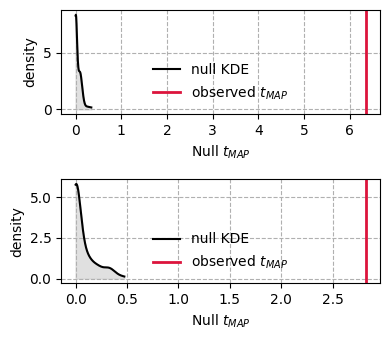

In [37]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(
    len(perm_results_df), 1,
    figsize=(4, 1.75 * len(perm_results_df)),
    squeeze=False
)

for ax, row in zip(axes.ravel(), perm_results_df.itertuples(index=False)):
    samples = np.asarray(row.null_samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if len(samples) >= 2 and np.std(samples) > 0:
        x_grid = np.linspace(samples.min(), samples.max(), 300)
        kde = gaussian_kde(samples)
        y_kde = kde(x_grid)

        ax.plot(x_grid, y_kde, color='black', lw=1.5, label='null KDE')
        ax.fill_between(x_grid, 0, y_kde, color='lightgrey', alpha=0.7)
    else:
        # Fallback if too few/degenerate samples
        ax.axvline(samples[0] if len(samples) else row.null_mean_t_map, color='black', lw=1.5, label='null KDE (degenerate)')
    ax.grid(True, linestyle="--")
    ax.axvline(row.observed_t_map, color='crimson', lw=2, label='observed $t_{MAP}$')
    ax.set_xlabel(r'Null $t_{MAP}$')
    ax.set_ylabel('density')
    ax.legend(frameon=False)
    

plt.tight_layout()
plt.savefig('../figures/figure_2/permutation_test_kde.pdf')
plt.show()


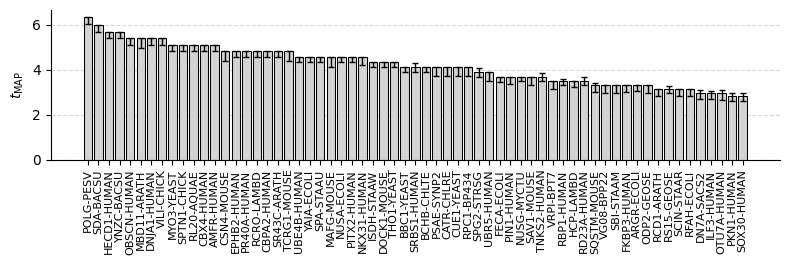

In [7]:
# SEARCH_TAG: TMAP_BAR_WITH_PERM_SIGNIFICANCE
# Remake t_MAP barplot without permutation-significance stars.
if 'dms_tmap_df' not in globals():
    raise RuntimeError('Run the t_MAP table cell first (requires dms_tmap_df).')

# Build plotting frame (same core structure as the original bar plot).
df = dms_tmap_df.copy().sort_values('t', ascending=False).reset_index(drop=True)

t = df['t'].to_numpy(dtype=float)
yerr = np.vstack([
    np.clip(t - df['t_lo'].to_numpy(dtype=float), a_min=0.0, a_max=None),
    np.clip(df['t_hi'].to_numpy(dtype=float) - t, a_min=0.0, a_max=None),
])

# -----------------------------
# Plot (single bar call; x aligned with errorbar)
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(8, 2.75))

ax.bar(
    x,
    t,
    color='lightgrey',
    edgecolor='black',
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=x,
    y=t,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    zorder=3
)

step = 1  # change to 3 if you truly want every 3rd label
ax.set_xticks(x[::step])
ax.set_xticklabels(df['dataset'].iloc[::step], rotation=90, fontsize=8)

ax.set_ylabel(r'$t_{\mathrm{MAP}}$')
# ax.set_yscale('log')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', ls='--', c='0.85', zorder=1)

plt.tight_layout()
plt.savefig('../figures/figure_2/tmap_vs_dms.pdf')
plt.show()



Downsampling each domain to n=636 variants.


Downsampling: 100%|██████████| 63/63 [01:52<00:00,  1.79s/it]

Spearman correlation (observed vs downsampled mean t_MAP): rho=0.513, p=2.32e-05, n=61
Pearson correlation (observed vs downsampled mean t_MAP): r=0.501, p=3.87e-05, n=61
Paired Wilcoxon test (observed vs downsampled mean t_MAP): W=0.000, p=1.63e-11


,dataset,t,downsample_t_mean,downsample_t_std,successful_reps
0,SDA-BACSU,6.009869,3.260552,2.071119e-01,3
1,YNZC-BACSU,5.693530,3.499704,5.438960e-16,3
2,OBSCN-HUMAN,5.393842,2.871227,9.042902e-02,3
3,MBD11-ARATH,5.393842,3.629336,1.122642e-01,3
4,DNJA1-HUMAN,5.393842,3.499704,5.438960e-16,3
...,...,...,...,...,...
56,DN7A-SACS2,2.975646,2.576919,8.115983e-02,3
57,ILF3-HUMAN,2.975646,2.354833,7.284075e-02,3
58,OTU7A-HUMAN,2.975646,2.975646,0.000000e+00,1
59,PKN1-HUMAN,2.819018,2.230883,6.900666e-02,3


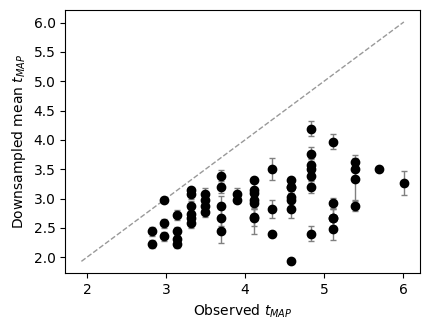

In [39]:
# 4) Subsample control: downsample all domains to the smallest domain size.
SUBSAMPLE_REPS = 3  # small initial setting for turnaround speed
MAX_ATTEMPTS_FACTOR = 20
subsample_rng = np.random.default_rng(2026)

target_n = int(dms_tmap_df['n_sequences'].min())
print(f'Downsampling each domain to n={target_n} variants.')

subsample_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='Downsampling'):
    domain_df = load_domain_dataframe(row.file)
    sample_t_values = []

    max_attempts = max(SUBSAMPLE_REPS * MAX_ATTEMPTS_FACTOR, 20)
    attempts = 0

    while len(sample_t_values) < SUBSAMPLE_REPS and attempts < max_attempts:
        attempts += 1

        if len(domain_df) == target_n:
            sample_df = domain_df
        else:
            chosen_idx = subsample_rng.choice(len(domain_df), size=target_n, replace=False)
            sample_df = domain_df.iloc[chosen_idx].reset_index(drop=True)

        try:
            sample_landscape, sample_fitness = build_hamming_landscape_from_df(sample_df)
        except ValueError:
            continue

        sample_t = compute_tmap_on_landscape_values(
            sample_landscape,
            sample_fitness,
            layer_name='sampled_fitness',
            detach=True,
        )
        sample_t_values.append(sample_t)

        if len(domain_df) == target_n:
            break

    arr = np.asarray(sample_t_values, dtype=float)

    subsample_rows.append(
        {
            'dataset': row.dataset,
            'file': row.file,
            'observed_t_map': float(row.t),
            'downsample_t_mean': float(arr.mean()) if len(arr) else np.nan,
            'downsample_t_std': float(arr.std(ddof=1)) if len(arr) > 1 else 0.0,
            'successful_reps': int(len(arr)),
            'attempts': int(attempts),
            'downsample_samples': sample_t_values,
        }
    )

subsample_df = pd.DataFrame(subsample_rows)
rank_compare_df = dms_tmap_df.merge(
    subsample_df[['file', 'downsample_t_mean', 'downsample_t_std', 'successful_reps']],
    on='file',
    how='left',
)

valid_rank_df = rank_compare_df.dropna(subset=['t', 'downsample_t_mean']).reset_index(drop=True)
if len(valid_rank_df) >= 3:
    rho, p_spearman = spearmanr(valid_rank_df['t'], valid_rank_df['downsample_t_mean'])
    r_pearson, p_pearson = pearsonr(valid_rank_df['t'].to_numpy(float), valid_rank_df['downsample_t_mean'].to_numpy(float))

    print(
        f'Spearman correlation (observed vs downsampled mean t_MAP): '
        f'rho={rho:.3f}, p={p_spearman:.3g}, n={len(valid_rank_df)}'
    )
    print(
        f'Pearson correlation (observed vs downsampled mean t_MAP): '
        f'r={r_pearson:.3f}, p={p_pearson:.3g}, n={len(valid_rank_df)}'
    )

    if len(valid_rank_df) >= 5:
        try:
            w_stat, p_wilcoxon = wilcoxon(
                valid_rank_df['t'].to_numpy(float),
                valid_rank_df['downsample_t_mean'].to_numpy(float),
                alternative='two-sided',
                zero_method='wilcox',
            )
            print(
                f'Paired Wilcoxon test (observed vs downsampled mean t_MAP): '
                f'W={w_stat:.3f}, p={p_wilcoxon:.3g}'
            )
        except ValueError as exc:
            print(f'Paired Wilcoxon test not computed: {exc}')

rank_out = valid_rank_df.sort_values('t', ascending=False).reset_index(drop=True)
display(rank_out[['dataset', 't', 'downsample_t_mean', 'downsample_t_std', 'successful_reps']])

plt.figure(figsize=(4.4, 3.4))
plt.errorbar(
    rank_out['t'],
    rank_out['downsample_t_mean'],
    yerr=rank_out['downsample_t_std'],
    fmt='o',
    color='black',
    ecolor='grey',
    elinewidth=1,
    capsize=2,
)

xy_min = float(min(rank_out['t'].min(), rank_out['downsample_t_mean'].min()))
xy_max = float(max(rank_out['t'].max(), rank_out['downsample_t_mean'].max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], ls='--', c='0.6', lw=1)

plt.xlabel('Observed $t_{MAP}$')
plt.ylabel('Downsampled mean $t_{MAP}$')
# plt.title('Graph-size robustness')
plt.tight_layout()
plt.savefig('../figures/SI_figures/SI_figure_DMS/graph_size_sampling_vs_tmap.pdf')
plt.show()


DMS substitution-matrix dimensionality:   0%|          | 0/63 [00:00<?, ?it/s]

,dataset,t_map,submat_rows_used,submat_n_components_90,submat_effective_dimensionality,submat_sv1_fraction,error
0,POLG-PESV,6.343783,53,7,6.135708,0.445422,
1,SDA-BACSU,6.009869,44,5,3.883200,0.645490,
2,HECD1-HUMAN,5.693530,70,10,9.363255,0.308647,
3,YNZC-BACSU,5.693530,39,8,6.503368,0.450261,
4,OBSCN-HUMAN,5.393842,65,9,7.717028,0.413882,
...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,55,7,5.967047,0.487513,
59,ILF3-HUMAN,2.975646,71,7,5.817783,0.498859,
60,OTU7A-HUMAN,2.975646,41,9,9.720900,0.287065,
61,PKN1-HUMAN,2.819018,71,6,5.401324,0.496311,


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,slope,slope_p,n_domains
0,submat_n_components_80,-0.064091,0.617758,-0.036125,0.778649,-0.043744,0.617758,63
1,submat_n_components_90,-0.058239,0.650273,-0.019135,0.881670,-0.036829,0.650273,63
2,submat_sv1_fraction,-0.054022,0.674114,-0.129161,0.313028,-0.540984,0.674114,63
3,submat_participation_ratio,0.029072,0.821064,0.112110,0.381689,0.019110,0.821064,63
4,submat_effective_dimensionality,0.010933,0.932228,0.054309,0.672482,0.005778,0.932228,63
5,submat_spectrum_entropy,0.000083,0.999486,0.054309,0.672482,0.000318,0.999486,63


Multivariate dimensionality model: R^2=0.199, F=2.313, p=0.0459, n=63


,feature,standardized_coef,stdcoef_t_stat,stdcoef_p_value
2,submat_effective_dimensionality,10.369487,3.237270,0.002030
4,submat_spectrum_entropy,-6.751473,-2.902230,0.005290
3,submat_participation_ratio,-5.553722,-3.028338,0.003714
5,submat_sv1_fraction,-2.883463,-2.637076,0.010803
0,submat_n_components_80,-0.885604,-2.014150,0.048807
1,submat_n_components_90,-0.134138,-0.354386,0.724380


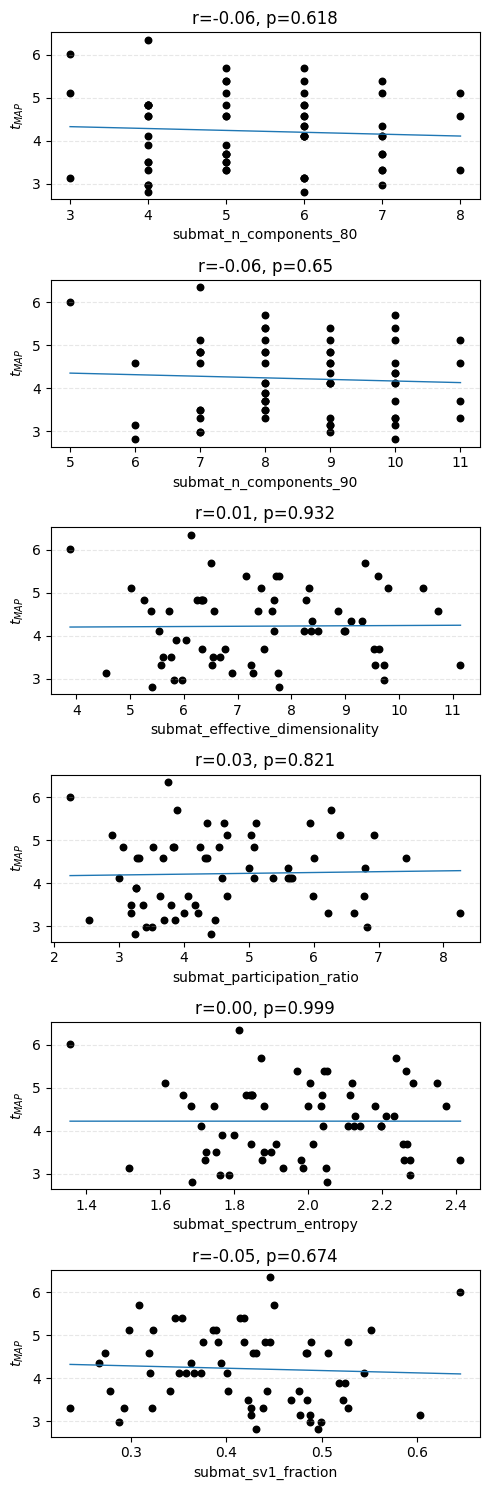

In [6]:
# Experiment 7: DMS-only substitution-matrix effective dimensionality vs ruggedness.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr, linregress, f as f_dist
from scipy.stats import t as student_t
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

AA20_DMS = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_DMS = re.compile(r'([A-Z])([0-9]+)([A-Z])')


def _parse_single_mutant_token_local(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None

    m = MUT_TOKEN_RE_DMS.fullmatch(tokens[0])
    if m is None:
        return None

    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa


def _extract_single_mutation_table_local(domain_df):
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_local(getattr(row, 'mutant', ''))
        if parsed is None:
            continue

        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_DMS:
            continue

        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue

        rows.append({
            'position': int(position),
            'wt_aa': wt_aa,
            'mut_aa': mut_aa,
            'DMS_score': score,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])

    out_df = pd.DataFrame(rows)
    out_df = out_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return out_df


def _effective_dimensionality_from_substitution_matrix(matrix_df, wt_per_position, min_measured_per_row=5):
    # matrix_df is position x 20-AA matrix of substitution effects; we mask per-position WT then row-center.
    mat = matrix_df.copy()

    # Remove WT column entry at each position to focus on non-WT substitution effects (19-AA subspace per row).
    for pos, wt in wt_per_position.items():
        if pos in mat.index and wt in mat.columns:
            mat.loc[pos, wt] = np.nan

    arr = mat.to_numpy(dtype=float)
    measured_counts = np.isfinite(arr).sum(axis=1)
    keep_rows = measured_counts >= int(min_measured_per_row)
    arr = arr[keep_rows]

    n_rows = int(arr.shape[0])
    n_cols = int(arr.shape[1]) if arr.ndim == 2 else 0

    out = {
        'submat_rows_used': n_rows,
        'submat_cols_total': n_cols,
        'submat_mean_measured_per_row': float(np.mean(measured_counts[keep_rows])) if n_rows > 0 else np.nan,
        'submat_n_components_80': np.nan,
        'submat_n_components_90': np.nan,
        'submat_spectrum_entropy': np.nan,
        'submat_effective_dimensionality': np.nan,
        'submat_participation_ratio': np.nan,
        'submat_sv1_fraction': np.nan,
    }

    if n_rows < 2:
        return out

    row_means = np.nanmean(arr, axis=1)
    nan_mask = ~np.isfinite(arr)
    if nan_mask.any():
        arr[nan_mask] = row_means[np.where(nan_mask)[0]]

    # Row-centering isolates amino-acid preference shape from per-position overall sensitivity.
    arr = arr - arr.mean(axis=1, keepdims=True)

    if (not np.isfinite(arr).all()) or np.allclose(arr, 0.0):
        return out

    singular_vals = np.linalg.svd(arr, full_matrices=False, compute_uv=False)
    power = singular_vals ** 2
    total = float(power.sum())
    if total <= 0:
        return out

    p = power / total
    p_nz = p[p > 0]

    out['submat_n_components_80'] = int(np.searchsorted(np.cumsum(p), 0.80) + 1)
    out['submat_n_components_90'] = int(np.searchsorted(np.cumsum(p), 0.90) + 1)

    entropy = float(-np.sum(p_nz * np.log(p_nz)))
    out['submat_spectrum_entropy'] = entropy
    out['submat_effective_dimensionality'] = float(np.exp(entropy))
    out['submat_participation_ratio'] = float(1.0 / np.sum(p ** 2))
    out['submat_sv1_fraction'] = float(p[0]) if len(p) > 0 else np.nan

    return out


subdim_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='DMS substitution-matrix dimensionality'):
    out = {
        'dataset': row.dataset,
        'file': row.file,
        't_map': float(row.t),
        'n_single_mutants': 0,
        'error': '',
    }

    try:
        domain_df = load_domain_dataframe(row.file)

        if 'extract_single_mutation_table' in globals():
            mut_df = extract_single_mutation_table(domain_df)
        else:
            mut_df = _extract_single_mutation_table_local(domain_df)

        out['n_single_mutants'] = int(len(mut_df))
        if len(mut_df) == 0:
            raise ValueError('No usable single-mutation records.')

        submat = (
            mut_df
            .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
            .reindex(columns=AA20_DMS)
            .sort_index()
        )

        if submat.shape[0] < 2:
            raise ValueError('Too few positions with substitution effects.')

        wt_per_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
        dim_metrics = _effective_dimensionality_from_substitution_matrix(submat, wt_per_pos)
        out.update(dim_metrics)

    except Exception as exc:
        out['error'] = str(exc)
        for k in [
            'submat_rows_used', 'submat_cols_total', 'submat_mean_measured_per_row',
            'submat_n_components_80', 'submat_n_components_90', 'submat_spectrum_entropy',
            'submat_effective_dimensionality', 'submat_participation_ratio', 'submat_sv1_fraction',
        ]:
            out[k] = np.nan

    subdim_rows.append(out)


dms_subdim_df = pd.DataFrame(subdim_rows).sort_values('t_map', ascending=False).reset_index(drop=True)

preview_cols = [
    'dataset', 't_map', 'submat_rows_used', 'submat_n_components_90',
    'submat_effective_dimensionality', 'submat_sv1_fraction', 'error'
]
display(dms_subdim_df[preview_cols])

dim_features = [
    'submat_n_components_80',
    'submat_n_components_90',
    'submat_effective_dimensionality',
    'submat_participation_ratio',
    'submat_spectrum_entropy',
    'submat_sv1_fraction',
]

assoc_rows = []
for feat in dim_features:
    tmp = dms_subdim_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    spear_rho, spear_p = spearmanr(x, y)
    lr = linregress(x, y)

    assoc_rows.append({
        'feature': feat,
        'pearson_r': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_rho': float(spear_rho),
        'spearman_p': float(spear_p),
        'slope': float(lr.slope),
        'slope_p': float(lr.pvalue),
        'n_domains': int(len(tmp)),
    })

subdim_assoc_df = pd.DataFrame(assoc_rows)
if len(subdim_assoc_df) > 0:
    subdim_assoc_df = subdim_assoc_df.sort_values('pearson_r', key=np.abs, ascending=False).reset_index(drop=True)

display(subdim_assoc_df)

# Optional multivariate linear model on all dimensionality metrics with global and coefficient-level p-values.
multi_feats = [f for f in dim_features if f in dms_subdim_df.columns]
multi_df = dms_subdim_df.dropna(subset=['t_map'] + multi_feats).copy()

if len(multi_df) >= len(multi_feats) + 3 and len(multi_feats) > 0:
    X = multi_df[multi_feats].to_numpy(dtype=float)
    y = multi_df['t_map'].to_numpy(dtype=float)

    multi_model = make_pipeline(StandardScaler(), LinearRegression())
    multi_model.fit(X, y)
    y_hat = multi_model.predict(X)
    r2 = float(multi_model.score(X, y))

    n, p = X.shape
    rss = float(np.sum((y - y_hat) ** 2))
    tss = float(np.sum((y - y.mean()) ** 2))
    df1 = int(p)
    df2 = int(n - p - 1)

    if df2 > 0 and rss > 0 and tss > 0:
        f_stat = ((tss - rss) / df1) / (rss / df2)
        model_p = float(f_dist.sf(f_stat, df1, df2))
    else:
        f_stat, model_p = np.nan, np.nan

    coef_vals = multi_model.named_steps['linearregression'].coef_.astype(float)
    coef_df = pd.DataFrame(
        {
            'feature': multi_feats,
            'standardized_coef': coef_vals,
            'stdcoef_t_stat': np.nan,
            'stdcoef_p_value': np.nan,
        }
    )

    if df2 > 0:
        Z = StandardScaler().fit_transform(X)
        X_design = np.column_stack([np.ones(n), Z])
        beta_hat, *_ = np.linalg.lstsq(X_design, y, rcond=None)
        resid = y - X_design @ beta_hat
        sigma2 = float(np.sum(resid ** 2) / df2)

        XtX_inv = np.linalg.pinv(X_design.T @ X_design)
        se = np.sqrt(np.diag(sigma2 * XtX_inv))[1:]

        with np.errstate(divide='ignore', invalid='ignore'):
            t_stats = coef_vals / se
        p_vals = 2.0 * student_t.sf(np.abs(t_stats), df=df2)

        coef_df['stdcoef_t_stat'] = t_stats
        coef_df['stdcoef_p_value'] = p_vals

    coef_df = coef_df.sort_values('standardized_coef', key=np.abs, ascending=False)

    print(f'Multivariate dimensionality model: R^2={r2:.3f}, F={f_stat:.3f}, p={model_p:.3g}, n={len(multi_df)}')
    display(coef_df)
else:
    print('Insufficient complete data for multivariate dimensionality model.')

# Plot all dimensionality predictors in a 1-column by n-row grid.
plot_features = dim_features
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.0, 2.5 * len(plot_features)), squeeze=False)

for ax, feat in zip(axes.ravel(), plot_features):
    tmp = dms_subdim_df.dropna(subset=[feat, 't_map']).copy()
    if len(tmp) < 3 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        ax.text(0.5, 0.5, f'{feat}: insufficient data', ha='center', va='center')
        ax.set_axis_off()
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    lr = linregress(x, y)

    ax.scatter(x, y, c='black', s=22)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, lr.slope * x_line + lr.intercept, color='tab:blue', lw=1)

    ax.set_xlabel(feat)
    ax.set_ylabel(r'$t_{MAP}$')
    ax.set_title(f'r={lr.rvalue:.2f}, p={lr.pvalue:.3g}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


Complementary full-dataset check (no partition conditioning):
Spearman on full data + segmented regression y(feature) ~ t_MAP with knot at 1.0.


,feature,n_domains,rho,rho_p,seg_knot_tmap,seg_r2,seg_slope_low,seg_slope_low_p,seg_slope_high,seg_slope_high_p,seg_slope_change,seg_slope_change_p,upper_seg_n,u_R,u_R_p,u_R2,u_rho,u_rho_p
0,submat_sv1_fraction,63,-0.129161,0.313028,0.5,2.918394e-03,0.095159,5.983562e-25,-0.005395,0.676665,-0.100554,5.752607e-07,63,-0.054022,0.674114,2.918394e-03,-0.129161,0.313028
1,submat_participation_ratio,63,0.112110,0.381689,0.5,8.451697e-04,1.004609,1.644591e-17,0.044228,0.822524,-0.960381,8.720732e-04,63,0.029072,0.821064,8.451697e-04,0.112110,0.381689
2,submat_effective_dimensionality,63,0.054309,0.672482,0.5,1.195296e-04,1.643556,6.192250e-23,0.020688,0.932789,-1.622868,1.266591e-05,63,0.010933,0.932228,1.195296e-04,0.054309,0.672482
3,submat_spectrum_entropy,63,0.054309,0.672482,0.5,6.867757e-09,0.440195,2.674135e-38,0.000022,0.999490,-0.440173,2.262250e-13,63,0.000083,0.999486,6.867756e-09,0.054309,0.672482
4,submat_n_components_80,63,-0.036125,0.778649,0.5,4.107614e-03,1.235229,2.361120e-22,-0.093901,0.620678,-1.329131,4.499173e-06,63,-0.064091,0.617758,4.107614e-03,-0.036125,0.778649
5,submat_n_components_90,63,-0.019135,0.881670,0.5,3.391733e-03,1.925896,1.736995e-30,-0.092093,0.652984,-2.017989,1.735185e-09,63,-0.058239,0.650273,3.391733e-03,-0.019135,0.881670


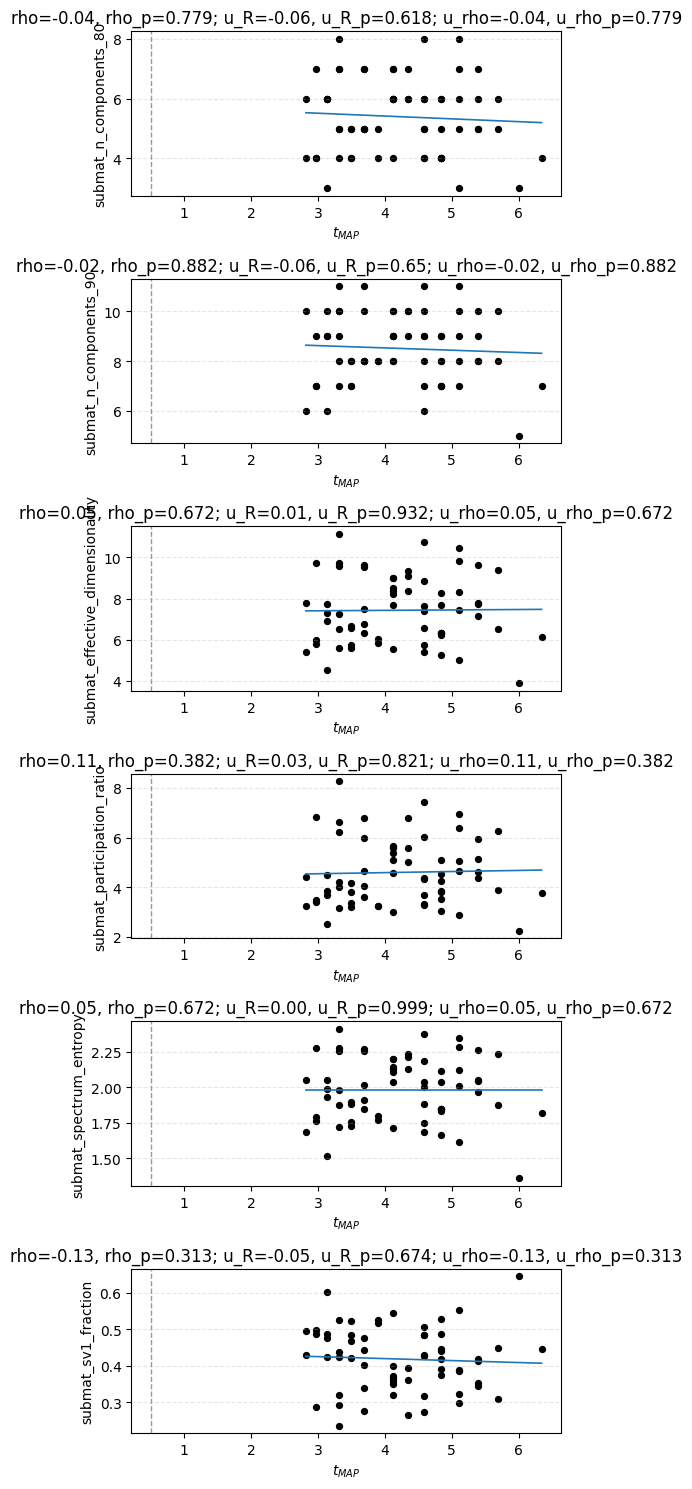

In [7]:
# SEARCH_TAG: SEGMENTED_FULLDATA_CHECK_DMS_SUBMAT
# Complementary full-dataset analysis (avoids conditioning on t_MAP partitions):
# Spearman + segmented regression vs t_MAP with knot at 1.0.
from scipy.stats import spearmanr, pearsonr

SEGMENT_KNOT_TMAP = 0.5

if 'segmented_regression_on_tmap' not in globals():
    from scipy.stats import t as student_t
    def segmented_regression_on_tmap(x_tmap, y_feature, knot=1.0):
        x = np.asarray(x_tmap, dtype=float)
        y = np.asarray(y_feature, dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        out = {
            'n': int(len(x)),
            'knot': float(knot),
            'slope_low': np.nan,
            'slope_low_p': np.nan,
            'slope_high': np.nan,
            'slope_high_p': np.nan,
            'slope_change': np.nan,
            'slope_change_p': np.nan,
            'r2': np.nan,
            'y_hat': np.full(len(x), np.nan),
            'x_used': x,
            'y_used': y,
        }

        if len(x) < 6 or np.unique(x).size < 3:
            return out

        h = np.clip(x - float(knot), 0.0, None)
        X = np.column_stack([np.ones(len(x)), x, h])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta

        n = len(x)
        p = X.shape[1]
        df_resid = n - p
        if df_resid <= 0:
            return out

        resid = y - y_hat
        rss = float(np.sum(resid ** 2))
        tss = float(np.sum((y - y.mean()) ** 2))
        r2 = float(1.0 - rss / tss) if tss > 0 else np.nan

        sigma2 = rss / df_resid if df_resid > 0 else np.nan
        XtX_inv = np.linalg.pinv(X.T @ X)
        cov = sigma2 * XtX_inv if np.isfinite(sigma2) else np.full_like(XtX_inv, np.nan)

        b0, b1, b2 = beta
        slope_low = float(b1)
        slope_high = float(b1 + b2)

        var_low = float(cov[1, 1]) if np.isfinite(cov[1, 1]) else np.nan
        var_change = float(cov[2, 2]) if np.isfinite(cov[2, 2]) else np.nan
        var_high = float(cov[1, 1] + cov[2, 2] + 2.0 * cov[1, 2]) if np.isfinite(cov[1, 2]) else np.nan

        def _t_p(value, var, df):
            if not np.isfinite(value) or not np.isfinite(var) or var <= 0 or df <= 0:
                return np.nan, np.nan
            se = np.sqrt(var)
            t_stat = value / se
            p_val = 2.0 * student_t.sf(np.abs(t_stat), df=df)
            return float(t_stat), float(p_val)

        _, p_low = _t_p(slope_low, var_low, df_resid)
        _, p_high = _t_p(slope_high, var_high, df_resid)
        _, p_change = _t_p(float(b2), var_change, df_resid)

        out.update(
            {
                'slope_low': slope_low,
                'slope_low_p': p_low,
                'slope_high': slope_high,
                'slope_high_p': p_high,
                'slope_change': float(b2),
                'slope_change_p': p_change,
                'r2': r2,
                'y_hat': y_hat,
                'x_used': x,
                'y_used': y,
            }
        )
        return out

if 'dms_subdim_df' not in globals():
    raise RuntimeError('Run Experiment 7 first (requires dms_subdim_df).')

if 'dim_features' not in globals():
    dim_features = [
        'submat_n_components_80',
        'submat_n_components_90',
        'submat_effective_dimensionality',
        'submat_participation_ratio',
        'submat_spectrum_entropy',
        'submat_sv1_fraction',
    ]

rows = []
fit_cache = {}
for feat in dim_features:
    tmp = dms_subdim_df[['t_map', feat]].copy().dropna()
    if len(tmp) < 5:
        continue

    x = tmp['t_map'].to_numpy(dtype=float)
    y = tmp[feat].to_numpy(dtype=float)

    if np.unique(x).size < 3 or np.unique(y).size < 2:
        continue

    spearman_rho, spearman_p = spearmanr(x, y)
    piece = segmented_regression_on_tmap(x, y, knot=SEGMENT_KNOT_TMAP)

    upper_mask = x >= SEGMENT_KNOT_TMAP
    n_upper = int(np.sum(upper_mask))
    upper_seg_pearson_r = np.nan
    upper_seg_pearson_p = np.nan
    upper_seg_r2 = np.nan
    upper_seg_spearman_rho = np.nan
    upper_seg_spearman_p = np.nan

    if n_upper >= 3:
        x_upper = x[upper_mask]
        y_upper = y[upper_mask]
        if np.unique(x_upper).size >= 2 and np.unique(y_upper).size >= 2:
            upper_seg_pearson_r, upper_seg_pearson_p = pearsonr(x_upper, y_upper)
            upper_seg_r2 = float(upper_seg_pearson_r ** 2)
            upper_seg_spearman_rho, upper_seg_spearman_p = spearmanr(x_upper, y_upper)

    rows.append(
        {
            'feature': feat,
            'n_domains': int(piece['n']),
            'rho': float(spearman_rho),
            'rho_p': float(spearman_p),
            'seg_knot_tmap': float(piece['knot']),
            'seg_r2': float(piece['r2']),
            'seg_slope_low': float(piece['slope_low']),
            'seg_slope_low_p': float(piece['slope_low_p']),
            'seg_slope_high': float(piece['slope_high']),
            'seg_slope_high_p': float(piece['slope_high_p']),
            'seg_slope_change': float(piece['slope_change']),
            'seg_slope_change_p': float(piece['slope_change_p']),
            'upper_seg_n': int(n_upper),
            'u_R': float(upper_seg_pearson_r),
            'u_R_p': float(upper_seg_pearson_p),
            'u_R2': float(upper_seg_r2),
            'u_rho': float(upper_seg_spearman_rho),
            'u_rho_p': float(upper_seg_spearman_p),
        }
    )
    fit_cache[feat] = piece

submat_segmented_df = pd.DataFrame(rows)
if len(submat_segmented_df) > 0:
    submat_segmented_df = submat_segmented_df.sort_values('rho', key=np.abs, ascending=False).reset_index(drop=True)

print('Complementary full-dataset check (no partition conditioning):')
print('Spearman on full data + segmented regression y(feature) ~ t_MAP with knot at 1.0.')
display(submat_segmented_df)

# Plot all features with segmented fit overlay.
plot_features = [f for f in dim_features if f in fit_cache]
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.2, 2.5 * max(1, len(plot_features))), squeeze=False)

if len(plot_features) == 0:
    axes[0, 0].text(0.5, 0.5, 'No features with sufficient data', ha='center', va='center')
    axes[0, 0].set_axis_off()
else:
    for ax, feat in zip(axes.ravel(), plot_features):
        piece = fit_cache[feat]
        x = piece['x_used']
        y = piece['y_used']

        ax.scatter(x, y, c='black', s=18)

        x_line = np.linspace(np.min(x), np.max(x), 300)
        h_line = np.clip(x_line - SEGMENT_KNOT_TMAP, 0.0, None)

        X = np.column_stack([np.ones(len(x)), x, np.clip(x - SEGMENT_KNOT_TMAP, 0.0, None)])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_line = beta[0] + beta[1] * x_line + beta[2] * h_line

        ax.plot(x_line, y_line, color='tab:blue', lw=1.2)
        ax.axvline(SEGMENT_KNOT_TMAP, color='0.6', lw=1, ls='--')

        row = submat_segmented_df.loc[submat_segmented_df['feature'] == feat].iloc[0]
        ax.set_xlabel(r'$t_{MAP}$')
        ax.set_ylabel(feat)
        ax.set_title(
            f"rho={row['rho']:.2f}, rho_p={row['rho_p']:.3g}; "
            f"u_R={row['u_R']:.2f}, u_R_p={row['u_R_p']:.3g}; "
            f"u_rho={row['u_rho']:.2f}, u_rho_p={row['u_rho_p']:.3g}"
        )
        ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


All-domain subset: 63 domains.
Spearman on full subset + segmented regression y(feature) ~ t_MAP with knot at SEGMENT_KNOT_TMAP.


,feature,n_domains,rho,rho_p,seg_knot_tmap,seg_r2,seg_slope_low,seg_slope_low_p,seg_slope_high,seg_slope_high_p,seg_slope_change,seg_slope_change_p,upper_seg_n,u_R,u_R_p,u_R2,u_rho,u_rho_p
0,submat_sv1_fraction,63,-0.129161,0.313028,0.5,2.918394e-03,0.095159,5.983562e-25,-0.005395,0.676665,-0.100554,5.752607e-07,63,-0.054022,0.674114,2.918394e-03,-0.129161,0.313028
1,submat_participation_ratio,63,0.112110,0.381689,0.5,8.451697e-04,1.004609,1.644591e-17,0.044228,0.822524,-0.960381,8.720732e-04,63,0.029072,0.821064,8.451697e-04,0.112110,0.381689
2,submat_effective_dimensionality,63,0.054309,0.672482,0.5,1.195296e-04,1.643556,6.192250e-23,0.020688,0.932789,-1.622868,1.266591e-05,63,0.010933,0.932228,1.195296e-04,0.054309,0.672482
3,submat_spectrum_entropy,63,0.054309,0.672482,0.5,6.867757e-09,0.440195,2.674135e-38,0.000022,0.999490,-0.440173,2.262250e-13,63,0.000083,0.999486,6.867756e-09,0.054309,0.672482
4,submat_n_components_80,63,-0.036125,0.778649,0.5,4.107614e-03,1.235229,2.361120e-22,-0.093901,0.620678,-1.329131,4.499173e-06,63,-0.064091,0.617758,4.107614e-03,-0.036125,0.778649
5,submat_n_components_90,63,-0.019135,0.881670,0.5,3.391733e-03,1.925896,1.736995e-30,-0.092093,0.652984,-2.017989,1.735185e-09,63,-0.058239,0.650273,3.391733e-03,-0.019135,0.881670


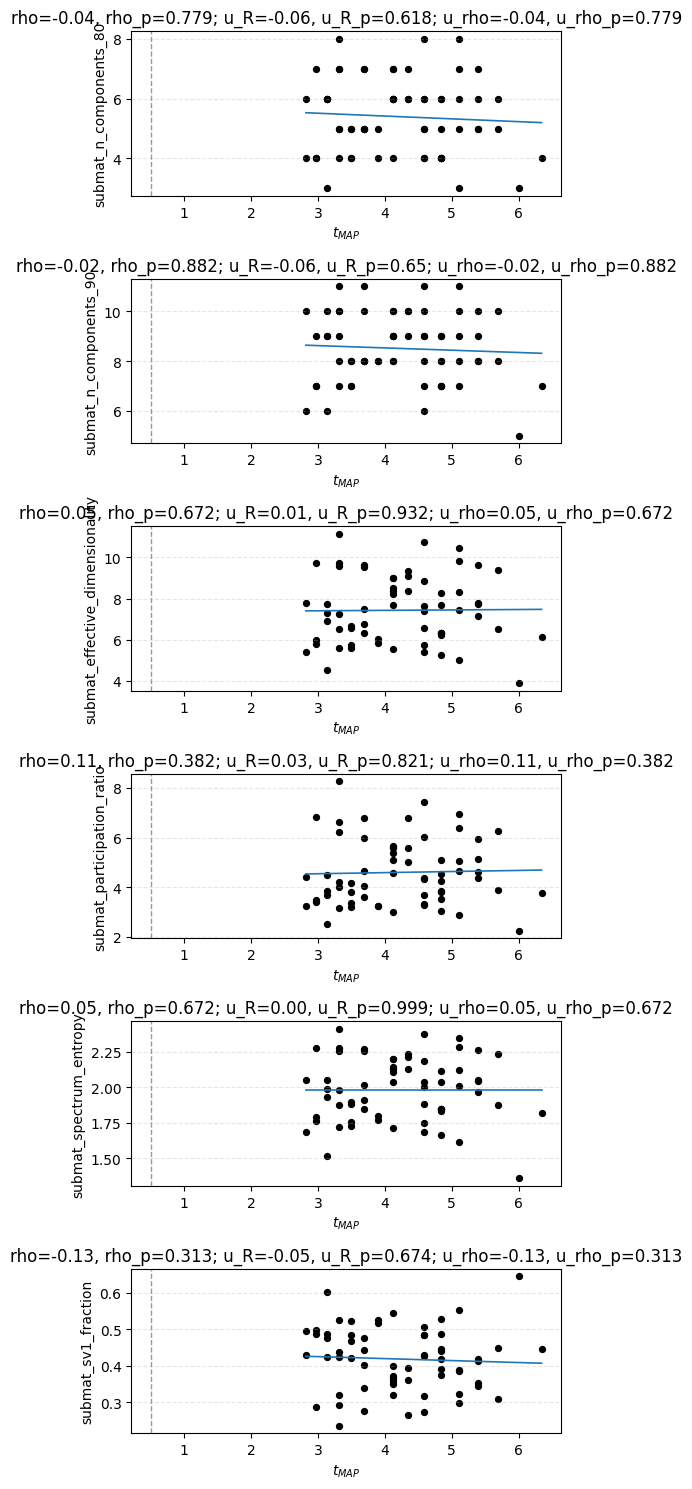

In [8]:
# SEARCH_TAG: SEGMENTED_FULLDATA_CHECK_DMS_SUBMAT_PERM_SIGNIFICANT
# Repeat the same Spearman + segmented regression analysis on all domains.
from scipy.stats import spearmanr, pearsonr

if 'dms_subdim_df' not in globals():
    raise RuntimeError('Run Experiment 7 first (requires dms_subdim_df).')
if 'segmented_regression_on_tmap' not in globals():
    raise RuntimeError('Run the full-data segmented regression cell first (defines segmented_regression_on_tmap).')

all_domain_subdim_df = dms_subdim_df.copy()

if len(all_domain_subdim_df) == 0:
    print('No domains available in dms_subdim_df.')
    submat_segmented_df = pd.DataFrame()
else:
    if 'dim_features' not in globals():
        dim_features = [
            'submat_n_components_80',
            'submat_n_components_90',
            'submat_effective_dimensionality',
            'submat_participation_ratio',
            'submat_spectrum_entropy',
            'submat_sv1_fraction',
        ]

    rows = []
    fit_cache = {}

    for feat in dim_features:
        tmp = all_domain_subdim_df[['t_map', feat]].copy().dropna()
        if len(tmp) < 5:
            continue

        x = tmp['t_map'].to_numpy(dtype=float)
        y = tmp[feat].to_numpy(dtype=float)

        if np.unique(x).size < 3 or np.unique(y).size < 2:
            continue

        spearman_rho, spearman_p = spearmanr(x, y)
        piece = segmented_regression_on_tmap(x, y, knot=SEGMENT_KNOT_TMAP)

        upper_mask = x >= SEGMENT_KNOT_TMAP
        n_upper = int(np.sum(upper_mask))
        upper_seg_pearson_r = np.nan
        upper_seg_pearson_p = np.nan
        upper_seg_r2 = np.nan
        upper_seg_spearman_rho = np.nan
        upper_seg_spearman_p = np.nan

        if n_upper >= 3:
            x_upper = x[upper_mask]
            y_upper = y[upper_mask]
            if np.unique(x_upper).size >= 2 and np.unique(y_upper).size >= 2:
                upper_seg_pearson_r, upper_seg_pearson_p = pearsonr(x_upper, y_upper)
                upper_seg_r2 = float(upper_seg_pearson_r ** 2)
                upper_seg_spearman_rho, upper_seg_spearman_p = spearmanr(x_upper, y_upper)

        rows.append(
            {
                'feature': feat,
                'n_domains': int(piece['n']),
                'rho': float(spearman_rho),
                'rho_p': float(spearman_p),
                'seg_knot_tmap': float(piece['knot']),
                'seg_r2': float(piece['r2']),
                'seg_slope_low': float(piece['slope_low']),
                'seg_slope_low_p': float(piece['slope_low_p']),
                'seg_slope_high': float(piece['slope_high']),
                'seg_slope_high_p': float(piece['slope_high_p']),
                'seg_slope_change': float(piece['slope_change']),
                'seg_slope_change_p': float(piece['slope_change_p']),
                'upper_seg_n': int(n_upper),
                'u_R': float(upper_seg_pearson_r),
                'u_R_p': float(upper_seg_pearson_p),
                'u_R2': float(upper_seg_r2),
                'u_rho': float(upper_seg_spearman_rho),
                'u_rho_p': float(upper_seg_spearman_p),
            }
        )
        fit_cache[feat] = piece

    submat_segmented_df = pd.DataFrame(rows)
    if len(submat_segmented_df) > 0:
        submat_segmented_df = submat_segmented_df.sort_values('rho', key=np.abs, ascending=False).reset_index(drop=True)

    print(f'All-domain subset: {len(all_domain_subdim_df)} domains.')
    print('Spearman on full subset + segmented regression y(feature) ~ t_MAP with knot at SEGMENT_KNOT_TMAP.')
    display(submat_segmented_df)

    plot_features = [f for f in dim_features if f in fit_cache]
    fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.2, 2.5 * max(1, len(plot_features))), squeeze=False)

    if len(plot_features) == 0:
        axes[0, 0].text(0.5, 0.5, 'No features with sufficient data in all-domain subset', ha='center', va='center')
        axes[0, 0].set_axis_off()
    else:
        for ax, feat in zip(axes.ravel(), plot_features):
            piece = fit_cache[feat]
            x = piece['x_used']
            y = piece['y_used']

            ax.scatter(x, y, c='black', s=18)

            x_line = np.linspace(np.min(x), np.max(x), 300)
            h_line = np.clip(x_line - SEGMENT_KNOT_TMAP, 0.0, None)

            X = np.column_stack([np.ones(len(x)), x, np.clip(x - SEGMENT_KNOT_TMAP, 0.0, None)])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            y_line = beta[0] + beta[1] * x_line + beta[2] * h_line

            ax.plot(x_line, y_line, color='tab:blue', lw=1.2)
            ax.axvline(SEGMENT_KNOT_TMAP, color='0.6', lw=1, ls='--')

            row = submat_segmented_df.loc[submat_segmented_df['feature'] == feat].iloc[0]
            ax.set_xlabel(r'$t_{MAP}$')
            ax.set_ylabel(feat)
            ax.set_title(
                f"rho={row['rho']:.2f}, rho_p={row['rho_p']:.3g}; "
                f"u_R={row['u_R']:.2f}, u_R_p={row['u_R_p']:.3g}; "
                f"u_rho={row['u_rho']:.2f}, u_rho_p={row['u_rho_p']:.3g}"
            )
            ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()



In [ ]:
## Figure plot

FEATURE_TO_PLOT = 'submat_n_components_90'

if 'SEGMENT_KNOT_TMAP' not in globals():
    raise RuntimeError('Run SEGMENTED_FULLDATA_CHECK_DMS_SUBMAT first (requires SEGMENT_KNOT_TMAP).')

if 'fit_cache' in globals() and FEATURE_TO_PLOT in fit_cache and 'submat_segmented_df' in globals():
    piece = fit_cache[FEATURE_TO_PLOT]
    stats_df = submat_segmented_df
else:
    raise RuntimeError(
        'Run the all-domain segmented-regression cell first (expects fit_cache and submat_segmented_df).'
    )

x = np.asarray(piece['x_used'], dtype=float)
y = np.asarray(piece['y_used'], dtype=float)

if len(x) == 0:
    raise RuntimeError('No data available for plotting.')

X = np.column_stack([np.ones(len(x)), x, np.clip(x - SEGMENT_KNOT_TMAP, 0.0, None)])
beta, *_ = np.linalg.lstsq(X, y, rcond=None)

x_line = np.linspace(np.min(x), np.max(x), 300)
h_line = np.clip(x_line - SEGMENT_KNOT_TMAP, 0.0, None)
y_line = beta[0] + beta[1] * x_line + beta[2] * h_line

row = stats_df.loc[stats_df['feature'] == FEATURE_TO_PLOT].iloc[0]

fig, ax = plt.subplots(figsize=(2.5, 1.75))

ax.scatter(
    x,
    y,
    s=26,
    facecolor='lightgrey',
    edgecolor='black',
    linewidth=0.75,
    zorder=3,
)
ax.plot(x_line, y_line, color='black', linewidth=1.25, zorder=4)
ax.set_xlabel(r'$t_{\mathrm{MAP}}$')

ax.grid(axis='y', ls='--', c='0.85', zorder=1)

plt.tight_layout()
from pathlib import Path
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'tmap_vs_submat_n_components_90_segmented.pdf')
plt.show()


In [9]:
# SEARCH_TAG: LEFT_SV_PREREQ_HELPERS
# Minimal prerequisite helpers for LEFT_SV_STRUCTURAL_CLUSTERING and LEFT_SV_DOMAIN_VIS_AMFR_4G3O.
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests

PDB_AA3_TO_1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'MSE': 'M', 'SEC': 'U', 'PYL': 'O',
}


def extract_pdb_id_from_file(file_name):
    stem = Path(str(file_name)).stem
    token = stem.split('_')[-1].strip().upper()
    m = re.search(r'([0-9][A-Z0-9]{3})$', token)
    if m:
        return m.group(1)
    if len(token) >= 4:
        return token[-4:]
    raise ValueError(f'Cannot parse PDB id from file name: {file_name}')


def fetch_pdb_text(pdb_id, cache_dir=None, timeout=30):
    pdb_id = str(pdb_id).upper()

    if cache_dir is None:
        cache_dir = globals().get('PDB_CACHE_DIR', Path('../data_files/pdb_cache'))
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_candidates = [
        cache_dir / f'{pdb_id}.pdb',
        cache_dir / f'{pdb_id.lower()}.pdb',
        cache_dir / f'pdb{pdb_id.lower()}.ent',
    ]

    for p in cache_candidates:
        if p.exists():
            return p.read_text(), str(p)

    urls = [
        f'https://files.rcsb.org/download/{pdb_id}.pdb',
        f'https://files.rcsb.org/view/{pdb_id}.pdb',
    ]

    last_err = None
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout)
            if r.status_code == 200 and ('ATOM' in r.text or 'MODEL' in r.text):
                out_path = cache_dir / f'{pdb_id}.pdb'
                out_path.write_text(r.text)
                return r.text, str(out_path)
        except Exception as exc:
            last_err = exc

    raise FileNotFoundError(f'Unable to retrieve PDB {pdb_id}. Last error: {last_err}')


def extract_main_chain_ensemble(pdb_text):
    # Parse CA coordinates by model/chain/residue.
    models = defaultdict(lambda: defaultdict(dict))
    model_id = 1

    for line in str(pdb_text).splitlines():
        rec = line[:6].strip()
        if rec == 'MODEL':
            model_raw = line[10:14].strip()
            try:
                model_id = int(model_raw)
            except Exception:
                model_id = 1
            continue

        if rec != 'ATOM':
            continue

        atom_name = line[12:16].strip()
        if atom_name != 'CA':
            continue

        altloc = line[16].strip()
        if altloc not in ('', 'A', '1'):
            continue

        chain = line[21].strip() or 'A'
        resname = line[17:20].strip().upper()
        try:
            resseq = int(line[22:26])
        except Exception:
            continue
        icode = line[26].strip()

        try:
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
        except Exception:
            continue

        key = (resseq, icode, resname)
        if key not in models[model_id][chain]:
            models[model_id][chain][key] = (x, y, z)

    if len(models) == 0:
        raise ValueError('No CA atoms parsed from PDB text.')

    model_ids = sorted(models.keys())
    first_model = model_ids[0]

    # Main chain = chain with most CA residues in first model.
    chain_sizes = {ch: len(res_map) for ch, res_map in models[first_model].items()}
    if len(chain_sizes) == 0:
        raise ValueError('No chains found in first model.')
    main_chain = sorted(chain_sizes.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

    first_keys = list(models[first_model][main_chain].keys())
    common_keys = [
        key for key in first_keys
        if all(main_chain in models[mid] and key in models[mid][main_chain] for mid in model_ids)
    ]
    if len(common_keys) == 0:
        raise ValueError('No common CA residues across ensemble models for selected main chain.')

    coords_models = []
    valid_model_ids = []
    for mid in model_ids:
        if main_chain not in models[mid]:
            continue
        if not all(key in models[mid][main_chain] for key in common_keys):
            continue
        arr = np.array([models[mid][main_chain][key] for key in common_keys], dtype=float)
        if arr.shape[0] == len(common_keys):
            coords_models.append(arr)
            valid_model_ids.append(mid)

    if len(coords_models) == 0:
        raise ValueError('No complete model found after enforcing common-residue set.')

    residue_rows = []
    seq_chars = []
    for i, (resseq, icode, resname) in enumerate(common_keys):
        aa = PDB_AA3_TO_1.get(resname, 'X')
        residue_rows.append({
            'position': int(i),
            'chain': str(main_chain),
            'resseq': int(resseq),
            'icode': str(icode),
            'resname': str(resname),
            'aa': aa,
        })
        seq_chars.append(aa)

    residue_df = pd.DataFrame(residue_rows)
    structure_seq = ''.join(seq_chars)

    return residue_df, coords_models, valid_model_ids, str(main_chain), structure_seq


def align_dms_to_structure_positions(wt_seq, structure_seq):
    # Global alignment (Needleman-Wunsch) and mapping: dms position (1-based) -> structure index (0-based).
    a = str(wt_seq)
    b = str(structure_seq)

    if len(a) == 0 or len(b) == 0:
        return {}, np.nan

    match = 2.0
    mismatch = -1.0
    gap = -2.0

    n, m = len(a), len(b)
    score = np.zeros((n + 1, m + 1), dtype=float)
    ptr = np.zeros((n + 1, m + 1), dtype=np.int8)  # 1=diag, 2=up, 3=left

    for i in range(1, n + 1):
        score[i, 0] = score[i - 1, 0] + gap
        ptr[i, 0] = 2
    for j in range(1, m + 1):
        score[0, j] = score[0, j - 1] + gap
        ptr[0, j] = 3

    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            bj = b[j - 1]
            s_diag = score[i - 1, j - 1] + (match if ai == bj else mismatch)
            s_up = score[i - 1, j] + gap
            s_left = score[i, j - 1] + gap
            best = s_diag
            move = 1
            if s_up > best:
                best = s_up
                move = 2
            if s_left > best:
                best = s_left
                move = 3
            score[i, j] = best
            ptr[i, j] = move

    # Traceback
    i, j = n, m
    aln_a = []
    aln_b = []
    while i > 0 or j > 0:
        move = ptr[i, j] if (i >= 0 and j >= 0) else 0
        if i > 0 and j > 0 and move == 1:
            aln_a.append(a[i - 1]); aln_b.append(b[j - 1]); i -= 1; j -= 1
        elif i > 0 and (j == 0 or move == 2):
            aln_a.append(a[i - 1]); aln_b.append('-'); i -= 1
        else:
            aln_a.append('-'); aln_b.append(b[j - 1]); j -= 1

    aln_a = aln_a[::-1]
    aln_b = aln_b[::-1]

    mapping = {}
    i_dms = -1
    i_struct = -1
    n_match = 0
    n_pairs = 0

    for ca, cb in zip(aln_a, aln_b):
        if ca != '-':
            i_dms += 1
        if cb != '-':
            i_struct += 1

        if ca != '-' and cb != '-':
            # DMS positions are 1-based in mutation annotations.
            mapping[int(i_dms + 1)] = int(i_struct)
            n_pairs += 1
            if ca == cb:
                n_match += 1

    seq_identity = float(n_match / n_pairs) if n_pairs > 0 else np.nan
    return mapping, seq_identity



Left-SV structural clustering:   0%|          | 0/63 [00:00<?, ?it/s]

Domains processed: 63
Domains with successful clustering run: 63


,dataset,t_map,status,n_positions_submat,n_positions_mapped,n_axes_tested,n_axes_clustered_p05,frac_axes_clustered_p05,mean_axis_cluster_z,n_axis_pairs_separated_p05,frac_axis_pairs_separated_p05,mean_pair_sep_z,error
0,POLG-PESV,6.343783,ok,53,53,3,3,1.000000,-3.377792,0,0.0,-6.014426,
1,SDA-BACSU,6.009869,ok,44,44,3,1,0.333333,-2.044484,0,0.0,-3.521518,
2,HECD1-HUMAN,5.693530,ok,70,70,3,1,0.333333,-1.433447,0,0.0,-3.385746,
3,YNZC-BACSU,5.693530,ok,39,39,3,0,0.000000,-0.852850,0,0.0,-2.085756,
4,OBSCN-HUMAN,5.393842,ok,65,65,3,2,0.666667,-2.198791,0,0.0,-4.441117,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,55,55,3,2,0.666667,-1.974225,0,0.0,-3.415278,
59,ILF3-HUMAN,2.975646,ok,71,71,3,3,1.000000,-3.314344,0,0.0,-6.251352,
60,OTU7A-HUMAN,2.975646,ok,41,41,3,1,0.333333,-1.101027,0,0.0,-2.257043,
61,PKN1-HUMAN,2.819018,ok,71,71,3,2,0.666667,-2.652482,0,0.0,-4.591290,


,dataset,axis,explained_power_fraction,n_positions_selected,observed_mean_pair_dist,null_mean_pair_dist,z_vs_null,p_cluster_one_sided
0,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,0.388723,12,10.419717,12.380900,-2.082219,0.019934
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,2,0.200719,12,12.356364,12.497169,-0.137763,0.438538
2,AMFR_HUMAN_Tsuboyama_2023_4G3O,3,0.105236,12,10.916372,12.438310,-1.535148,0.089701
3,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,0.425863,18,11.133127,14.877749,-4.347393,0.003322
4,ARGR_ECOLI_Tsuboyama_2023_1AOY,2,0.231243,18,14.698931,14.818373,-0.128969,0.435216
...,...,...,...,...,...,...,...,...
184,YAIA_ECOLI_Tsuboyama_2023_2KVT,2,0.164073,13,13.822218,15.189232,-0.888023,0.192691
185,YAIA_ECOLI_Tsuboyama_2023_2KVT,3,0.138642,13,11.467314,15.280371,-2.234146,0.009967
186,YNZC_BACSU_Tsuboyama_2023_2JVD,1,0.450261,10,10.620824,13.083105,-1.452592,0.069767
187,YNZC_BACSU_Tsuboyama_2023_2JVD,2,0.192635,10,11.652871,12.875877,-0.744488,0.245847


,dataset,axis_a,axis_b,observed_cross_dist,null_mean_cross_dist,z_sep_vs_null,p_separation_one_sided
0,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,2,11.108774,12.422852,-2.311828,0.980066
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,3,10.824075,12.455787,-2.813922,1.000000
2,AMFR_HUMAN_Tsuboyama_2023_4G3O,2,3,11.086760,12.457838,-2.404406,0.993355
3,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,2,12.700108,14.812093,-3.658639,1.000000
4,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,3,13.299425,14.777504,-2.741829,1.000000
...,...,...,...,...,...,...,...
184,YAIA_ECOLI_Tsuboyama_2023_2KVT,1,3,11.278327,15.094541,-4.016319,1.000000
185,YAIA_ECOLI_Tsuboyama_2023_2KVT,2,3,12.365327,15.250322,-3.016207,1.000000
186,YNZC_BACSU_Tsuboyama_2023_2JVD,1,2,10.332653,12.939731,-2.927655,1.000000
187,YNZC_BACSU_Tsuboyama_2023_2JVD,1,3,11.115852,12.972354,-1.980983,0.986711


Association with t_MAP (domain level):


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,slope,slope_p,n_domains
0,mean_axis_cluster_z,-0.235033,0.063707,-0.226556,0.074177,-0.225311,0.063707,63
1,mean_pair_sep_z,-0.208892,0.100381,-0.185060,0.146494,-0.112281,0.100381,63
2,frac_axes_clustered_p05,0.159672,0.211295,0.167334,0.189911,0.433751,0.211295,63
3,n_axes_clustered_p05,0.159672,0.211295,0.167334,0.189911,0.144584,0.211295,63
4,median_axis_cluster_p,-0.069091,0.590539,-0.162534,0.203117,-0.403833,0.590539,63
5,median_pair_sep_p,0.034595,0.787799,0.096246,0.453027,0.195894,0.787799,63
6,frac_axis_pairs_separated_p05,-0.015578,0.903552,-0.014016,0.913182,-0.323261,0.903552,63
7,n_axis_pairs_separated_p05,-0.015578,0.903552,-0.014016,0.913182,-0.107754,0.903552,63


Association with substitution-matrix effective dimensionality:


,feature,target,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,mean_pair_sep_z,submat_n_components_90,0.571530,9.968640e-07,0.612248,9.711599e-08,63
1,mean_axis_cluster_z,submat_n_components_90,0.552636,2.650558e-06,0.569246,1.125610e-06,63
2,frac_axes_clustered_p05,submat_n_components_90,-0.514229,1.625107e-05,-0.544960,3.877721e-06,63
3,n_axes_clustered_p05,submat_n_components_90,-0.514229,1.625107e-05,-0.544960,3.877721e-06,63
4,mean_pair_sep_z,submat_effective_dimensionality,0.515274,1.551310e-05,0.540995,4.702594e-06,63
5,mean_axis_cluster_z,submat_effective_dimensionality,0.520849,1.207557e-05,0.521697,1.161932e-05,63
6,n_axes_clustered_p05,submat_effective_dimensionality,-0.473901,8.737500e-05,-0.488104,4.949035e-05,63
7,frac_axes_clustered_p05,submat_effective_dimensionality,-0.473901,8.737500e-05,-0.488104,4.949035e-05,63
8,n_axis_pairs_separated_p05,submat_n_components_90,0.138608,2.786413e-01,0.150070,2.404131e-01,63
9,n_axis_pairs_separated_p05,submat_effective_dimensionality,0.120383,3.473185e-01,0.118729,3.540319e-01,63


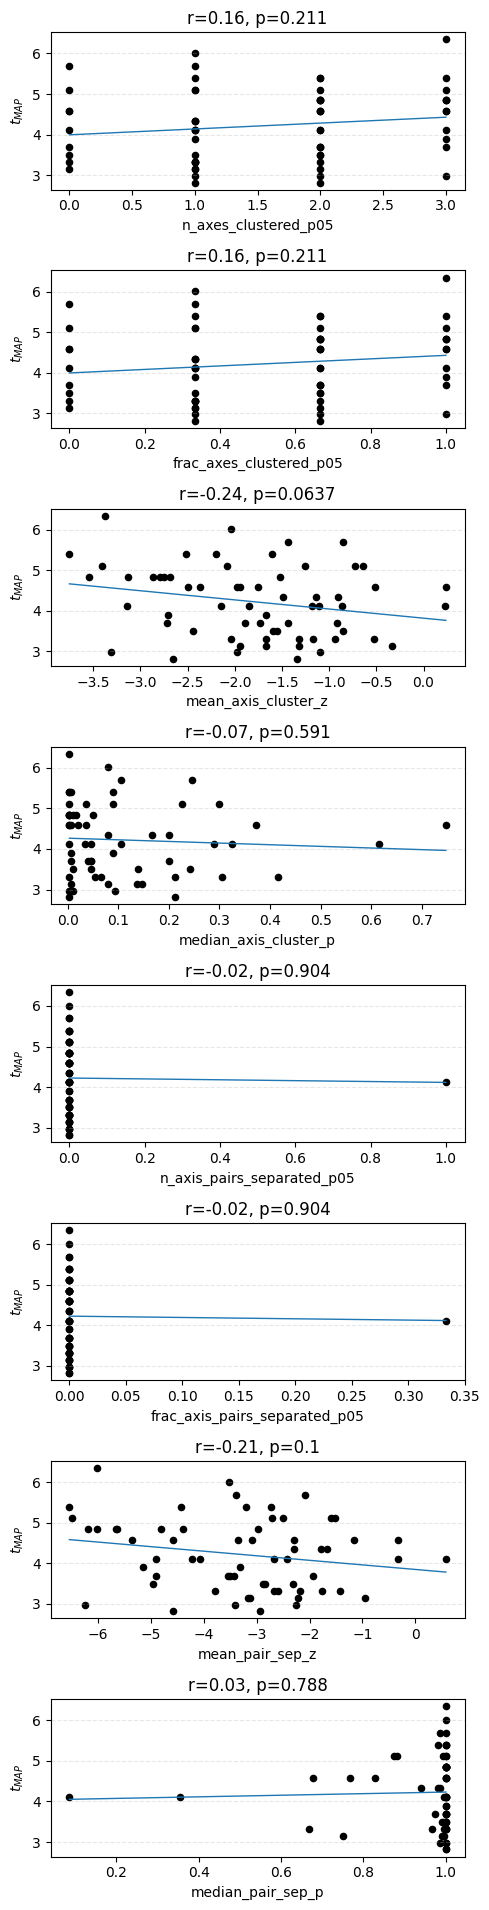

Axis-level correlation (t_MAP vs p_cluster_one_sided): Pearson r=-0.097, p=0.183; Spearman rho=-0.146, p=0.045; n=189


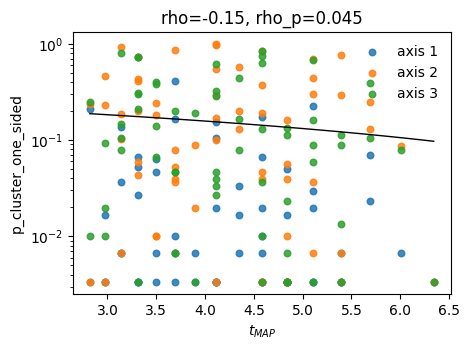

In [10]:
# SEARCH_TAG: LEFT_SV_STRUCTURAL_CLUSTERING
# Experiment 8: Are high-loading positions on each LEFT singular vector spatially clustered in 3D?
import re
import binascii
from itertools import combinations
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.stats import pearsonr, spearmanr, linregress

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
SV_TOP_K = 3
SV_TOP_LOADING_QUANTILE = 0.75   # top quartile by absolute loading
SV_NULL_REPS = 300               # increase for final runs
SV_MIN_ROWS_FOR_SVD = 8
SV_MIN_MEASURED_PER_ROW = 5
SV_RANDOM_SEED = 2026

AA20_SV = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_SV = re.compile(r'([A-Z])([0-9]+)([A-Z])')


def _parse_single_mutant_token_sv(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None

    m = MUT_TOKEN_RE_SV.fullmatch(tokens[0])
    if m is None:
        return None

    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa


def _extract_single_mutation_table_sv(domain_df):
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_sv(getattr(row, 'mutant', ''))
        if parsed is None:
            continue

        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_SV:
            continue

        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue

        rows.append(
            {
                'position': int(position),
                'wt_aa': wt_aa,
                'mut_aa': mut_aa,
                'DMS_score': score,
            }
        )

    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])

    mut_df = pd.DataFrame(rows)
    mut_df = mut_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return mut_df


def _mean_pairwise_ca_distance(coords, indices):
    idx = np.asarray(sorted(set(indices)), dtype=int)
    if len(idx) < 2:
        return np.nan

    pts = coords[idx]
    d = squareform(pdist(pts))
    tri = np.triu_indices(len(idx), k=1)
    return float(np.mean(d[tri]))


def _mean_cross_ca_distance(coords, idx_a, idx_b):
    a = np.asarray(sorted(set(idx_a)), dtype=int)
    b = np.asarray(sorted(set(idx_b)), dtype=int)
    if len(a) == 0 or len(b) == 0:
        return np.nan

    d = cdist(coords[a], coords[b])
    return float(np.mean(d))


def _build_wt_sequence_fallback(mut_df):
    if len(mut_df) == 0:
        raise ValueError('Cannot infer WT sequence from empty mutation table.')

    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    min_pos = int(wt_by_pos.index.min())
    max_pos = int(wt_by_pos.index.max())

    if min_pos != 1:
        raise ValueError('Fallback WT sequence inference requires positions starting at 1.')

    seq = ''.join(wt_by_pos.reindex(range(1, max_pos + 1)).fillna('X').tolist())
    return seq


def _compute_left_sv_structural_clustering_for_domain(file_name):
    out = {
        'file': file_name,
        'dataset': Path(file_name).stem,
        'status': 'ok',
        'error': '',
        'pdb_id': np.nan,
        'n_single_mutants': np.nan,
        'n_positions_submat': np.nan,
        'n_positions_mapped': np.nan,
        'sequence_alignment_identity': np.nan,
        'n_axes_tested': 0,
        'n_axes_clustered_p05': 0,
        'frac_axes_clustered_p05': np.nan,
        'mean_axis_cluster_z': np.nan,
        'median_axis_cluster_p': np.nan,
        'n_axis_pairs_tested': 0,
        'n_axis_pairs_separated_p05': 0,
        'frac_axis_pairs_separated_p05': np.nan,
        'mean_pair_sep_z': np.nan,
        'median_pair_sep_p': np.nan,
    }

    axis_rows = []
    pair_rows = []

    try:
        domain_df = load_domain_dataframe(file_name)
        mut_df = _extract_single_mutation_table_sv(domain_df)
        out['n_single_mutants'] = int(len(mut_df))

        if len(mut_df) == 0:
            raise ValueError('No usable single-mutation records.')

        submat_df = (
            mut_df
            .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
            .reindex(columns=AA20_SV)
            .sort_index()
        ).copy(deep=True)

        wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
        col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}

        # Build an explicit writable ndarray to avoid read-only assignment errors.
        arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)
        if not arr_all.flags.writeable:
            arr_all = arr_all.copy()

        # Mask per-position WT entries so we analyze non-WT substitutions.
        for r_i, pos in enumerate(submat_df.index.to_numpy()):
            wt = wt_by_pos.get(int(pos), None)
            c_i = col_to_idx.get(wt, None)
            if c_i is not None:
                arr_all[r_i, c_i] = np.nan

        measured_per_row = np.isfinite(arr_all).sum(axis=1)
        keep_mask = measured_per_row >= SV_MIN_MEASURED_PER_ROW

        kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
        arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

        if arr.shape[0] < SV_MIN_ROWS_FOR_SVD:
            raise ValueError(f'Insufficient rows after filtering: {arr.shape[0]} < {SV_MIN_ROWS_FOR_SVD}.')

        row_means = np.nanmean(arr, axis=1)
        nan_mask = ~np.isfinite(arr)
        if nan_mask.any():
            arr[nan_mask] = row_means[np.where(nan_mask)[0]]

        arr = arr - np.mean(arr, axis=1, keepdims=True)
        if not np.isfinite(arr).all() or np.allclose(arr, 0.0):
            raise ValueError('Centered substitution matrix is degenerate.')

        U, S, Vt = np.linalg.svd(arr, full_matrices=False)
        dms_positions = kept_positions.astype(int)
        out['n_positions_submat'] = int(len(dms_positions))

        out['pdb_id'] = extract_pdb_id_from_file(file_name)
        pdb_text, _ = fetch_pdb_text(out['pdb_id'])
        residue_df, coords_models, model_ids, main_chain, structure_seq = extract_main_chain_ensemble(pdb_text)

        if 'infer_wildtype_sequence' in globals():
            wt_seq = infer_wildtype_sequence(domain_df)
        else:
            wt_seq = _build_wt_sequence_fallback(mut_df)

        if 'align_dms_to_structure_positions' not in globals():
            raise ValueError('align_dms_to_structure_positions is not defined; run the reviewer-metrics setup cells first.')

        dms_to_struct_map, seq_ident = align_dms_to_structure_positions(wt_seq, structure_seq)
        out['sequence_alignment_identity'] = float(seq_ident)

        mapped_positions = [int(p) for p in dms_positions if int(p) in dms_to_struct_map]
        out['n_positions_mapped'] = int(len(mapped_positions))
        if len(mapped_positions) < SV_MIN_ROWS_FOR_SVD:
            raise ValueError('Too few mapped positions for clustering test.')

        coords = np.asarray(coords_models[0], dtype=float)
        mapped_pool = np.asarray(sorted({int(dms_to_struct_map[p]) for p in mapped_positions}), dtype=int)

        if len(mapped_pool) < SV_MIN_ROWS_FOR_SVD:
            raise ValueError('Too few unique mapped structure positions.')

        k_eff = int(min(SV_TOP_K, U.shape[1]))
        if k_eff < 1:
            raise ValueError('No usable singular vectors.')

        seed = SV_RANDOM_SEED + int(binascii.crc32(str(file_name).encode('utf-8')) % 1_000_000)
        rng = np.random.default_rng(seed)

        axis_sets = {}
        for axis_idx in range(k_eff):
            abs_load = np.abs(U[:, axis_idx])
            n_select = int(max(3, np.ceil((1.0 - SV_TOP_LOADING_QUANTILE) * len(abs_load))))
            top_idx = np.argsort(abs_load)[::-1][:n_select]

            top_positions = [int(dms_positions[i]) for i in top_idx if int(dms_positions[i]) in dms_to_struct_map]
            top_struct = sorted({int(dms_to_struct_map[p]) for p in top_positions})

            row_axis = {
                'file': file_name,
                'dataset': out['dataset'],
                'pdb_id': out['pdb_id'],
                'axis': int(axis_idx + 1),
                'singular_value': float(S[axis_idx]),
                'explained_power_fraction': float((S[axis_idx] ** 2) / np.sum(S ** 2)),
                'n_positions_selected': int(len(top_struct)),
                'observed_mean_pair_dist': np.nan,
                'null_mean_pair_dist': np.nan,
                'null_std_pair_dist': np.nan,
                'z_vs_null': np.nan,
                'p_cluster_one_sided': np.nan,
                'cluster_effect_ratio_obs_over_null': np.nan,
            }

            if len(top_struct) >= 3 and len(mapped_pool) >= len(top_struct):
                obs = _mean_pairwise_ca_distance(coords, top_struct)

                null_vals = []
                for _ in range(SV_NULL_REPS):
                    rand_idx = rng.choice(mapped_pool, size=len(top_struct), replace=False)
                    null_vals.append(_mean_pairwise_ca_distance(coords, rand_idx))

                null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
                if len(null_arr) > 0 and np.isfinite(obs):
                    null_mean = float(np.mean(null_arr))
                    null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
                    p_cluster = float((np.sum(null_arr <= obs) + 1) / (len(null_arr) + 1))
                    z_val = float((obs - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
                    ratio = float(obs / null_mean) if np.isfinite(null_mean) and null_mean != 0 else np.nan

                    row_axis.update(
                        {
                            'observed_mean_pair_dist': float(obs),
                            'null_mean_pair_dist': null_mean,
                            'null_std_pair_dist': null_std,
                            'z_vs_null': z_val,
                            'p_cluster_one_sided': p_cluster,
                            'cluster_effect_ratio_obs_over_null': ratio,
                        }
                    )
                    axis_sets[int(axis_idx + 1)] = top_struct

            axis_rows.append(row_axis)

        # Between-axis separation test: are high-loading sets from different axes farther apart than random?
        for ax_a, ax_b in combinations(sorted(axis_sets.keys()), 2):
            idx_a = axis_sets[ax_a]
            idx_b = axis_sets[ax_b]

            row_pair = {
                'file': file_name,
                'dataset': out['dataset'],
                'pdb_id': out['pdb_id'],
                'axis_a': int(ax_a),
                'axis_b': int(ax_b),
                'n_a': int(len(idx_a)),
                'n_b': int(len(idx_b)),
                'observed_cross_dist': np.nan,
                'null_mean_cross_dist': np.nan,
                'null_std_cross_dist': np.nan,
                'z_sep_vs_null': np.nan,
                'p_separation_one_sided': np.nan,
                'sep_effect_ratio_obs_over_null': np.nan,
            }

            if len(mapped_pool) >= (len(idx_a) + len(idx_b)):
                obs_cross = _mean_cross_ca_distance(coords, idx_a, idx_b)

                null_vals = []
                for _ in range(SV_NULL_REPS):
                    samp = rng.choice(mapped_pool, size=(len(idx_a) + len(idx_b)), replace=False)
                    ra = samp[:len(idx_a)]
                    rb = samp[len(idx_a):]
                    null_vals.append(_mean_cross_ca_distance(coords, ra, rb))

                null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
                if len(null_arr) > 0 and np.isfinite(obs_cross):
                    null_mean = float(np.mean(null_arr))
                    null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
                    p_sep = float((np.sum(null_arr >= obs_cross) + 1) / (len(null_arr) + 1))
                    z_sep = float((obs_cross - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
                    ratio = float(obs_cross / null_mean) if np.isfinite(null_mean) and null_mean != 0 else np.nan

                    row_pair.update(
                        {
                            'observed_cross_dist': float(obs_cross),
                            'null_mean_cross_dist': null_mean,
                            'null_std_cross_dist': null_std,
                            'z_sep_vs_null': z_sep,
                            'p_separation_one_sided': p_sep,
                            'sep_effect_ratio_obs_over_null': ratio,
                        }
                    )

            pair_rows.append(row_pair)

        axis_df = pd.DataFrame(axis_rows)
        pair_df = pd.DataFrame(pair_rows)

        valid_axis = axis_df.dropna(subset=['p_cluster_one_sided']) if len(axis_df) else pd.DataFrame()
        valid_pair = pair_df.dropna(subset=['p_separation_one_sided']) if len(pair_df) else pd.DataFrame()

        out['n_axes_tested'] = int(len(valid_axis))
        out['n_axes_clustered_p05'] = int((valid_axis['p_cluster_one_sided'] < 0.05).sum()) if len(valid_axis) else 0
        out['frac_axes_clustered_p05'] = float(out['n_axes_clustered_p05'] / out['n_axes_tested']) if out['n_axes_tested'] > 0 else np.nan
        out['mean_axis_cluster_z'] = float(valid_axis['z_vs_null'].mean()) if len(valid_axis) else np.nan
        out['median_axis_cluster_p'] = float(valid_axis['p_cluster_one_sided'].median()) if len(valid_axis) else np.nan

        out['n_axis_pairs_tested'] = int(len(valid_pair))
        out['n_axis_pairs_separated_p05'] = int((valid_pair['p_separation_one_sided'] < 0.05).sum()) if len(valid_pair) else 0
        out['frac_axis_pairs_separated_p05'] = (
            float(out['n_axis_pairs_separated_p05'] / out['n_axis_pairs_tested']) if out['n_axis_pairs_tested'] > 0 else np.nan
        )
        out['mean_pair_sep_z'] = float(valid_pair['z_sep_vs_null'].mean()) if len(valid_pair) else np.nan
        out['median_pair_sep_p'] = float(valid_pair['p_separation_one_sided'].median()) if len(valid_pair) else np.nan

    except Exception as exc:
        out['status'] = 'error'
        out['error'] = f"{type(exc).__name__}: {exc}"

    return out, axis_rows, pair_rows


domain_rows = []
axis_rows_all = []
pair_rows_all = []

for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='Left-SV structural clustering'):
    domain_out, axis_rows, pair_rows = _compute_left_sv_structural_clustering_for_domain(row.file)
    domain_out['dataset'] = row.dataset
    domain_out['t_map'] = float(row.t)

    domain_rows.append(domain_out)
    axis_rows_all.extend(axis_rows)
    pair_rows_all.extend(pair_rows)

left_sv_domain_df = pd.DataFrame(domain_rows).sort_values('t_map', ascending=False).reset_index(drop=True)
left_sv_axis_df = pd.DataFrame(axis_rows_all)
left_sv_pair_df = pd.DataFrame(pair_rows_all)

print('Domains processed:', len(left_sv_domain_df))
print('Domains with successful clustering run:', int((left_sv_domain_df['status'] == 'ok').sum()))

display(
    left_sv_domain_df[
        [
            'dataset', 't_map', 'status', 'n_positions_submat', 'n_positions_mapped',
            'n_axes_tested', 'n_axes_clustered_p05', 'frac_axes_clustered_p05',
            'mean_axis_cluster_z', 'n_axis_pairs_separated_p05', 'frac_axis_pairs_separated_p05',
            'mean_pair_sep_z', 'error'
        ]
    ]
)

if len(left_sv_axis_df) > 0:
    axis_show = left_sv_axis_df.dropna(subset=['p_cluster_one_sided']).copy()
    axis_show = axis_show.sort_values(['dataset', 'axis']).reset_index(drop=True)
    display(
        axis_show[
            [
                'dataset', 'axis', 'explained_power_fraction', 'n_positions_selected',
                'observed_mean_pair_dist', 'null_mean_pair_dist', 'z_vs_null', 'p_cluster_one_sided'
            ]
        ]
    )

if len(left_sv_pair_df) > 0:
    pair_show = left_sv_pair_df.dropna(subset=['p_separation_one_sided']).copy()
    pair_show = pair_show.sort_values(['dataset', 'axis_a', 'axis_b']).reset_index(drop=True)
    display(
        pair_show[
            [
                'dataset', 'axis_a', 'axis_b', 'observed_cross_dist',
                'null_mean_cross_dist', 'z_sep_vs_null', 'p_separation_one_sided'
            ]
        ]
    )

# Domain-level associations to ruggedness (t_MAP) and, when available, effective dimensionality.
summary_features = [
    'n_axes_clustered_p05',
    'frac_axes_clustered_p05',
    'mean_axis_cluster_z',
    'median_axis_cluster_p',
    'n_axis_pairs_separated_p05',
    'frac_axis_pairs_separated_p05',
    'mean_pair_sep_z',
    'median_pair_sep_p',
]

assoc_rows_tmap = []
for feat in summary_features:
    tmp = left_sv_domain_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    rho, rho_p = spearmanr(x, y)
    lr = linregress(x, y)

    assoc_rows_tmap.append(
        {
            'feature': feat,
            'pearson_r': float(pear_r),
            'pearson_p': float(pear_p),
            'spearman_rho': float(rho),
            'spearman_p': float(rho_p),
            'slope': float(lr.slope),
            'slope_p': float(lr.pvalue),
            'n_domains': int(len(tmp)),
        }
    )

left_sv_assoc_tmap_df = pd.DataFrame(assoc_rows_tmap)
if len(left_sv_assoc_tmap_df) > 0:
    left_sv_assoc_tmap_df = left_sv_assoc_tmap_df.sort_values('spearman_rho', key=np.abs, ascending=False).reset_index(drop=True)

print('Association with t_MAP (domain level):')
display(left_sv_assoc_tmap_df)

if 'dms_subdim_df' in globals():
    merged = left_sv_domain_df.merge(
        dms_subdim_df[['file', 'submat_effective_dimensionality', 'submat_n_components_90']],
        on='file',
        how='left'
    )

    assoc_rows_dim = []
    for feat in ['n_axes_clustered_p05', 'frac_axes_clustered_p05', 'mean_axis_cluster_z', 'n_axis_pairs_separated_p05', 'mean_pair_sep_z']:
        for target in ['submat_effective_dimensionality', 'submat_n_components_90']:
            tmp = merged.dropna(subset=[feat, target]).copy()
            if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
                continue

            x = tmp[feat].to_numpy(dtype=float)
            y = tmp[target].to_numpy(dtype=float)

            pear_r, pear_p = pearsonr(x, y)
            rho, rho_p = spearmanr(x, y)

            assoc_rows_dim.append(
                {
                    'feature': feat,
                    'target': target,
                    'pearson_r': float(pear_r),
                    'pearson_p': float(pear_p),
                    'spearman_rho': float(rho),
                    'spearman_p': float(rho_p),
                    'n_domains': int(len(tmp)),
                }
            )

    left_sv_assoc_dim_df = pd.DataFrame(assoc_rows_dim)
    if len(left_sv_assoc_dim_df) > 0:
        left_sv_assoc_dim_df = left_sv_assoc_dim_df.sort_values('spearman_rho', key=np.abs, ascending=False).reset_index(drop=True)

    print('Association with substitution-matrix effective dimensionality:')
    display(left_sv_assoc_dim_df)

# Plot all summary-vs-ruggedness relationships in SI style (1 column by n rows).
plot_features = summary_features
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.0, 2.4 * len(plot_features)), squeeze=False)

for ax, feat in zip(axes.ravel(), plot_features):
    tmp = left_sv_domain_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 4 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        ax.text(0.5, 0.5, f'{feat}: insufficient data', ha='center', va='center')
        ax.set_axis_off()
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    lr = linregress(x, y)

    ax.scatter(x, y, c='black', s=20)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, lr.slope * x_line + lr.intercept, color='tab:blue', lw=1)

    ax.set_xlabel(feat)
    ax.set_ylabel(r'$t_{MAP}$')
    ax.set_title(f'r={lr.rvalue:.2f}, p={lr.pvalue:.3g}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# Additional plot: axis-level p_cluster_one_sided vs domain t_MAP.
req_axis_cols = {'file', 'p_cluster_one_sided'}
req_domain_cols = {'file', 't_map'}

if req_axis_cols.issubset(set(left_sv_axis_df.columns)) and req_domain_cols.issubset(set(left_sv_domain_df.columns)):
    axis_corr_df = (
        left_sv_axis_df
        .merge(left_sv_domain_df[['file', 't_map']], on='file', how='left')
        .dropna(subset=['t_map', 'p_cluster_one_sided'])
        .copy()
    )
else:
    axis_corr_df = pd.DataFrame(columns=['file', 't_map', 'p_cluster_one_sided', 'axis'])

if len(axis_corr_df) >= 5 and np.unique(axis_corr_df['t_map'].to_numpy(float)).size >= 2:
    x = axis_corr_df['t_map'].to_numpy(dtype=float)
    y = axis_corr_df['p_cluster_one_sided'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    rho, rho_p = spearmanr(x, y)

    print(
        f"Axis-level correlation (t_MAP vs p_cluster_one_sided): "
        f"Pearson r={pear_r:.3f}, p={pear_p:.3g}; Spearman rho={rho:.3f}, p={rho_p:.3g}; n={len(axis_corr_df)}"
    )

    plt.figure(figsize=(4.8, 3.6))

    if 'axis' in axis_corr_df.columns:
        for axis_id in sorted(axis_corr_df['axis'].dropna().unique()):
            sub = axis_corr_df.loc[axis_corr_df['axis'] == axis_id]
            plt.scatter(sub['t_map'], sub['p_cluster_one_sided'], s=22, alpha=0.85, label=f'axis {int(axis_id)}')
    else:
        plt.scatter(x, y, c='black', s=22)

    x_line = np.linspace(float(np.min(x)), float(np.max(x)), 100)
    slope, intercept = np.polyfit(x, y, 1)
    plt.plot(x_line, slope * x_line + intercept, color='black', lw=1)

    plt.xlabel(r'$t_{MAP}$')
    plt.ylabel('p_cluster_one_sided')
    plt.yscale('log')
    plt.title(f"rho={rho:.2f}, rho_p={rho_p:.3g}")
    if 'axis' in axis_corr_df.columns:
        plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print('Axis-level t_MAP vs p_cluster_one_sided plot: insufficient data.')



In [11]:
LEFT_SV_AXIS_ALPHA = 0.05

if 'left_sv_axis_df' not in globals():
    raise RuntimeError('Run the LEFT_SV_STRUCTURAL_CLUSTERING cell first (requires left_sv_axis_df).')

axis_pivot = (
    left_sv_axis_df[['file', 'axis', 'p_cluster_one_sided']]
    .drop_duplicates(subset=['file', 'axis'])
    .pivot(index='file', columns='axis', values='p_cluster_one_sided')
)

if 'left_sv_domain_df' in globals():
    all_files = pd.Index(left_sv_domain_df['file'].astype(str), name='file')
elif 'dms_tmap_df' in globals():
    all_files = pd.Index(dms_tmap_df['file'].astype(str), name='file')
else:
    all_files = pd.Index(axis_pivot.index.astype(str), name='file')

axis_pivot = axis_pivot.reindex(all_files)
all_three_mask = axis_pivot.reindex(columns=[1, 2, 3]).lt(LEFT_SV_AXIS_ALPHA).all(axis=1)
axis1_mask = axis_pivot.get(1, pd.Series(index=axis_pivot.index, dtype=float)).lt(LEFT_SV_AXIS_ALPHA)

left_sv_structural_count_df = pd.DataFrame(
    [
        {
            'subset': f'all_domains (n={len(axis_pivot)})',
            'n_all_3_axes_p_lt_0p05': int(all_three_mask.sum()),
            'n_axis_1_p_lt_0p05': int(axis1_mask.sum()),
        },
    ]
)

display(left_sv_structural_count_df)
print(f"All domains: all 3 axes p<{LEFT_SV_AXIS_ALPHA:.2f} in {int(all_three_mask.sum())} domains; axis 1 p<{LEFT_SV_AXIS_ALPHA:.2f} in {int(axis1_mask.sum())} domains.")


,subset,n_all_3_axes_p_lt_0p05,n_axis_1_p_lt_0p05
0,all_domains (n=63),12,50


All domains: all 3 axes p<0.05 in 12 domains; axis 1 p<0.05 in 50 domains.



### Distinct-Pressure Control for Leading SVD Axes

Supplementary control for the claim that the leading SVD axes isolate distinct biophysical pressures. The code cell below profiles each axis by its amino-acid preference vector (`Vt`) and by structural predictors of its position loadings (`U`), then saves an SI figure and CSV summaries.


Left-SV distinct-pressure control:   0%|          | 0/63 [00:00<?, ?it/s]

Domains processed: 63
Domains with successful distinct-pressure profiling: 63


,dataset,t_map,status,n_axes_profiled,aa_unique_dominant_labels,structure_unique_dominant_labels,all_three_axes_have_distinct_aa_labels,all_three_axes_have_distinct_structure_labels,error
0,POLG-PESV,6.343783,ok,3,3,2,True,False,
1,SDA-BACSU,6.009869,ok,3,2,1,False,False,
2,HECD1-HUMAN,5.693530,ok,3,3,2,True,False,
3,YNZC-BACSU,5.693530,ok,3,2,3,False,True,
4,OBSCN-HUMAN,5.393842,ok,3,3,3,True,True,
...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,3,2,1,False,False,
59,ILF3-HUMAN,2.975646,ok,3,2,1,False,False,
60,OTU7A-HUMAN,2.975646,ok,3,3,3,True,True,
61,PKN1-HUMAN,2.819018,ok,3,3,1,True,False,


Median AA-property correlations by axis:


,Hydrophobicity,Small-residue preference,H-bond donor,H-bond acceptor,Positive charge,Negative charge,Aromaticity
axis,,,,,,,
1,0.583609,-0.433665,-0.087535,-0.167921,-0.093327,-0.275500,0.175428
2,0.075996,-0.045564,-0.006845,-0.021222,-0.256341,-0.050344,0.027057
3,-0.217184,-0.282399,0.219982,0.074234,-0.071484,0.053351,0.554899


...

,Packing density,Exposure proxy,Backbone curvature,CA B-factor
axis,,,,
1,0.438030,-0.466084,0.004543,-0.193992
2,0.162436,-0.201916,0.052413,-0.114833
3,0.208391,-0.196715,-0.044802,-0.072341


Axis-level dominant-pressure summary (for figure legend / text):


,axis,median_top_aa_property,median_top_aa_corr,median_top_structure_predictor,median_top_structure_rho
0,1,Hydrophobicity,0.583609,Exposure proxy,-0.466084
1,2,Positive charge,-0.256341,Exposure proxy,-0.201916
2,3,Aromaticity,0.554899,Packing density,0.208391


Within-domain label-diversity summary across the first three axes:


,family,metric,count,n_domains,fraction
0,AA-property labels,>=2 unique labels across first 3 axes,63,63,1.000000
1,AA-property labels,all 3 axes have different labels,37,63,0.587302
2,Structure labels,>=2 unique labels across first 3 axes,52,63,0.825397
3,Structure labels,all 3 axes have different labels,27,63,0.428571


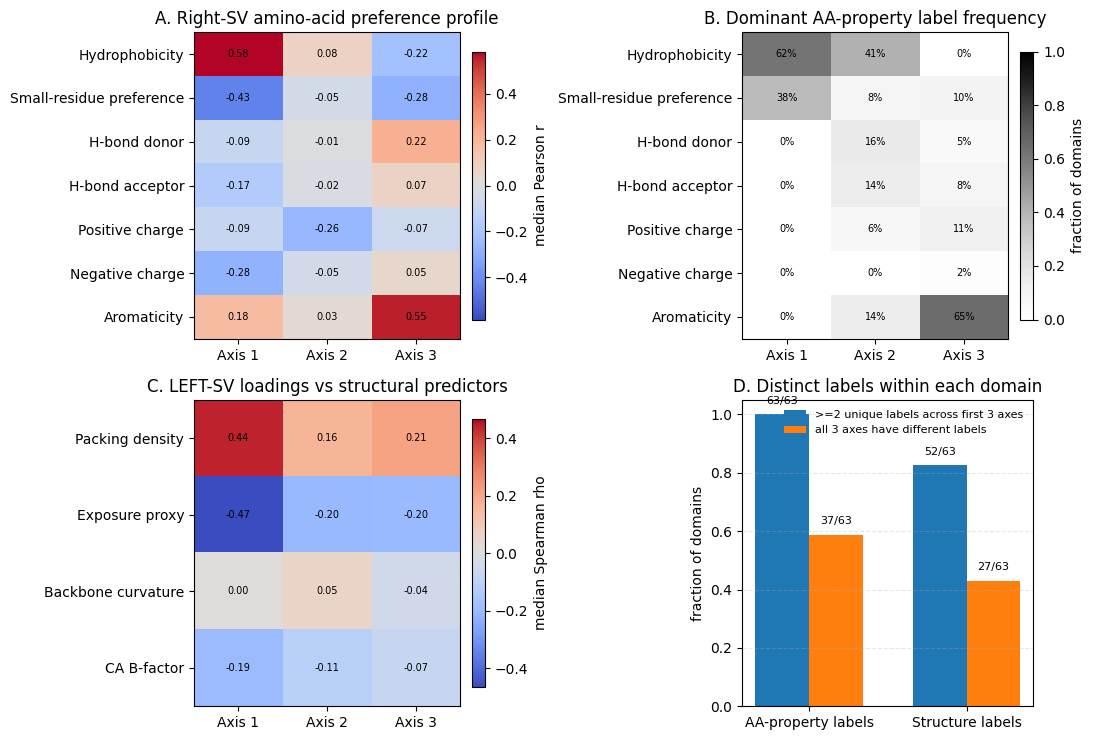

Supplementary control figure written to: ../figures/SI_figures/SI_figure_DMS/left_sv_distinct_biophysical_pressures_control.pdf
Axis-level table written to: ../figures/SI_figures/SI_figure_DMS/left_sv_distinct_pressure_axis_profiles.csv
Domain-level table written to: ../figures/SI_figures/SI_figure_DMS/left_sv_distinct_pressure_domain_summary.csv


In [12]:

# SEARCH_TAG: LEFT_SV_DISTINCT_PRESSURES_CONTROL
# Experiment 8c: Control analysis for whether leading LEFT/RIGHT SVD axes capture
# distinct biophysical pressures rather than a single thermodynamic function split
# across structural regions.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from matplotlib.colors import TwoSlopeNorm
from tqdm.auto import tqdm

DISTINCT_PRESSURE_TOP_K = 3
DISTINCT_PRESSURE_MIN_ROWS_FOR_SVD = 8
DISTINCT_PRESSURE_MIN_MEASURED_PER_ROW = 5
DISTINCT_PRESSURE_MIN_STRUCT_POINTS = 5
DISTINCT_PRESSURE_CONTACT_CUTOFF = 10.0
DISTINCT_PRESSURE_KNN = 8
DISTINCT_PRESSURE_OUTDIR = Path('../figures/SI_figures/SI_figure_DMS')
DISTINCT_PRESSURE_OUTDIR.mkdir(parents=True, exist_ok=True)
DISTINCT_PRESSURE_FIG_PATH = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_biophysical_pressures_control.pdf'
DISTINCT_PRESSURE_AXIS_CSV = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_pressure_axis_profiles.csv'
DISTINCT_PRESSURE_DOMAIN_CSV = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_pressure_domain_summary.csv'
DISTINCT_PRESSURE_AA_SUMMARY_CSV = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_pressure_aa_summary.csv'
DISTINCT_PRESSURE_STRUCTURE_SUMMARY_CSV = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_pressure_structure_summary.csv'
DISTINCT_PRESSURE_UNIQUENESS_CSV = DISTINCT_PRESSURE_OUTDIR / 'left_sv_distinct_pressure_uniqueness_summary.csv'

AA20_CONTROL = list('ACDEFGHIKLMNPQRSTVWY')
AA_PROPERTY_COLS = [
    'hydrophobicity',
    'small_residue',
    'hbond_donor',
    'hbond_acceptor',
    'positive_charge',
    'negative_charge',
    'aromaticity',
]
AA_PROPERTY_LABELS = {
    'hydrophobicity': 'Hydrophobicity',
    'small_residue': 'Small-residue preference',
    'hbond_donor': 'H-bond donor',
    'hbond_acceptor': 'H-bond acceptor',
    'positive_charge': 'Positive charge',
    'negative_charge': 'Negative charge',
    'aromaticity': 'Aromaticity',
}
STRUCTURE_PREDICTOR_COLS = [
    'packing_contact_density',
    'exposure_knn_distance',
    'backbone_curvature_deg',
    'ca_bfactor',
]
STRUCTURE_PREDICTOR_LABELS = {
    'packing_contact_density': 'Packing density',
    'exposure_knn_distance': 'Exposure proxy',
    'backbone_curvature_deg': 'Backbone curvature',
    'ca_bfactor': 'CA B-factor',
}
STRUCTURE_LABELS_SIGNED = {
    ('packing_contact_density', 1): 'dense packing',
    ('packing_contact_density', -1): 'low packing',
    ('exposure_knn_distance', 1): 'surface exposure',
    ('exposure_knn_distance', -1): 'buried core',
    ('backbone_curvature_deg', 1): 'backbone curvature',
    ('backbone_curvature_deg', -1): 'backbone straightness',
    ('ca_bfactor', 1): 'flexibility',
    ('ca_bfactor', -1): 'rigidity',
}

required = [
    'dms_tmap_df',
    'load_domain_dataframe',
    'infer_wildtype_sequence',
    'extract_pdb_id_from_file',
    'fetch_pdb_text',
    'extract_main_chain_ensemble',
    'align_dms_to_structure_positions',
]
missing_required = [name for name in required if name not in globals()]
if missing_required:
    raise RuntimeError(f'Run prerequisite reviewer cells first; missing symbols: {missing_required}')


def _zscore_vector(values):
    arr = np.asarray(values, dtype=float)
    mu = np.nanmean(arr)
    sigma = np.nanstd(arr, ddof=0)
    if (not np.isfinite(sigma)) or sigma <= 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - mu) / sigma


def _build_aa_property_table():
    raw = pd.DataFrame(
        {
            'aa': AA20_CONTROL,
            'hydrophobicity': [1.8, 2.5, -3.5, -3.5, 2.8, -0.4, -3.2, 4.5, -3.9, 3.8, 1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7, 4.2, -0.9, -1.3],
            'small_residue': [-88.6, -108.5, -111.1, -138.4, -189.9, -60.1, -153.2, -166.7, -168.6, -166.7, -162.9, -114.1, -112.7, -143.8, -173.4, -89.0, -116.1, -140.0, -227.8, -193.6],
            'hbond_donor': [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1],
            'hbond_acceptor': [0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1],
            'positive_charge': [0, 0, 0, 0, 0, 0, 0.25, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            'negative_charge': [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            'aromaticity': [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        }
    )
    for col in AA_PROPERTY_COLS:
        raw[col] = _zscore_vector(raw[col].to_numpy(dtype=float))
    return raw


def _parse_ca_bfactors(pdb_text, main_chain):
    bfactor_map = {}
    has_model_records = False
    in_first_model = True

    for line in str(pdb_text).splitlines():
        rec = line[:6].strip()
        if rec == 'MODEL':
            has_model_records = True
            try:
                model_no = int(line[10:14].strip())
            except Exception:
                model_no = 1
            in_first_model = (model_no == 1)
            continue
        if rec == 'ENDMDL':
            if has_model_records and in_first_model:
                break
            continue
        if has_model_records and not in_first_model:
            continue
        if rec != 'ATOM':
            continue

        atom_name = line[12:16].strip()
        if atom_name != 'CA':
            continue

        altloc = line[16].strip()
        if altloc not in ('', 'A', '1'):
            continue

        chain = line[21].strip() or 'A'
        if chain != main_chain:
            continue

        resname = line[17:20].strip().upper()
        try:
            resseq = int(line[22:26])
        except Exception:
            continue
        icode = line[26].strip()

        try:
            bfactor = float(line[60:66])
        except Exception:
            bfactor = np.nan

        key = (int(resseq), str(icode), str(resname))
        if key not in bfactor_map:
            bfactor_map[key] = float(bfactor) if np.isfinite(bfactor) else np.nan

    return bfactor_map


def _compute_structure_predictor_table(residue_df, coords, pdb_text, main_chain):
    coords = np.asarray(coords, dtype=float)
    n_res = int(coords.shape[0])
    if n_res != len(residue_df):
        raise ValueError('Residue dataframe and coordinate array length mismatch.')

    if n_res < 2:
        raise ValueError('Need at least two residues to compute structural predictors.')

    dist_mat = squareform(pdist(coords))
    seq_sep = np.abs(np.subtract.outer(np.arange(n_res), np.arange(n_res)))
    nonlocal_mask = seq_sep > 1
    nonself_mask = ~np.eye(n_res, dtype=bool)

    contact_density = np.sum((dist_mat <= DISTINCT_PRESSURE_CONTACT_CUTOFF) & nonlocal_mask, axis=1).astype(float)

    dist_for_knn = np.array(dist_mat, dtype=float, copy=True)
    dist_for_knn[~(nonself_mask & nonlocal_mask)] = np.inf
    knn_eff = int(max(1, min(DISTINCT_PRESSURE_KNN, max(1, n_res - 2))))
    nearest = np.sort(dist_for_knn, axis=1)[:, :knn_eff]
    nearest[~np.isfinite(nearest)] = np.nan
    exposure_knn_distance = np.nanmean(nearest, axis=1)

    curvature = np.full(n_res, np.nan, dtype=float)
    for idx in range(1, n_res - 1):
        v_prev = coords[idx - 1] - coords[idx]
        v_next = coords[idx + 1] - coords[idx]
        denom = np.linalg.norm(v_prev) * np.linalg.norm(v_next)
        if denom <= 0:
            continue
        cosang = np.clip(np.dot(v_prev, v_next) / denom, -1.0, 1.0)
        angle = np.degrees(np.arccos(cosang))
        curvature[idx] = 180.0 - angle

    bfactor_map = _parse_ca_bfactors(pdb_text, str(main_chain))
    ca_bfactor = []
    for row in residue_df.itertuples(index=False):
        key = (int(row.resseq), str(row.icode), str(row.resname))
        ca_bfactor.append(float(bfactor_map.get(key, np.nan)))

    out = residue_df[['position', 'chain', 'resseq', 'icode', 'resname']].copy()
    out['struct_idx'] = np.arange(n_res, dtype=int)
    out['packing_contact_density'] = contact_density
    out['exposure_knn_distance'] = exposure_knn_distance
    out['backbone_curvature_deg'] = curvature
    out['ca_bfactor'] = np.asarray(ca_bfactor, dtype=float)
    return out


def _safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if np.sum(valid) < 3:
        return np.nan
    x = x[valid]
    y = y[valid]
    if np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan
    return float(pearsonr(x, y)[0])


def _safe_spearmanr(x, y, min_n=DISTINCT_PRESSURE_MIN_STRUCT_POINTS):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_n):
        return np.nan, np.nan, n_valid
    x = x[valid]
    y = y[valid]
    if np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan, np.nan, n_valid
    rho, p = spearmanr(x, y)
    return float(rho), float(p), n_valid


def _prepare_left_sv_domain_for_pressure_control(file_name):
    domain_df = load_domain_dataframe(file_name)

    if '_extract_single_mutation_table_sv' in globals():
        mut_df = _extract_single_mutation_table_sv(domain_df)
    elif '_extract_single_mutation_table_local' in globals():
        mut_df = _extract_single_mutation_table_local(domain_df)
    else:
        raise RuntimeError('Need a single-mutant extraction helper; run the LEFT_SV_STRUCTURAL_CLUSTERING or Experiment 7 cell first.')

    if len(mut_df) == 0:
        raise ValueError('No usable single-mutation records.')

    submat_df = (
        mut_df
        .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
        .reindex(columns=AA20_CONTROL)
        .sort_index()
    ).copy(deep=True)

    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}

    arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)
    for row_idx, pos in enumerate(submat_df.index.to_numpy(dtype=int)):
        wt = wt_by_pos.get(int(pos), None)
        col_idx = col_to_idx.get(wt, None)
        if col_idx is not None:
            arr_all[row_idx, col_idx] = np.nan

    measured_per_row = np.isfinite(arr_all).sum(axis=1)
    keep_mask = measured_per_row >= int(DISTINCT_PRESSURE_MIN_MEASURED_PER_ROW)
    kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
    arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

    if arr.shape[0] < int(DISTINCT_PRESSURE_MIN_ROWS_FOR_SVD):
        raise ValueError(
            f'Insufficient rows after filtering: {arr.shape[0]} < {DISTINCT_PRESSURE_MIN_ROWS_FOR_SVD}.'
        )

    row_means = np.nanmean(arr, axis=1)
    nan_mask = ~np.isfinite(arr)
    if nan_mask.any():
        arr[nan_mask] = row_means[np.where(nan_mask)[0]]

    arr = arr - np.mean(arr, axis=1, keepdims=True)
    if (not np.isfinite(arr).all()) or np.allclose(arr, 0.0):
        raise ValueError('Centered substitution matrix is degenerate.')

    U, S, Vt = np.linalg.svd(arr, full_matrices=False)
    power = S ** 2
    power_frac = power / np.sum(power)

    pdb_id = extract_pdb_id_from_file(file_name)
    pdb_text, _ = fetch_pdb_text(pdb_id)
    residue_df, coords_models, model_ids, main_chain, structure_seq = extract_main_chain_ensemble(pdb_text)
    coords = np.asarray(coords_models[0], dtype=float)
    structure_predictor_df = _compute_structure_predictor_table(residue_df, coords, pdb_text, main_chain)

    wt_seq = infer_wildtype_sequence(domain_df) if 'infer_wildtype_sequence' in globals() else _build_wt_sequence_fallback(mut_df)
    dms_to_struct_map, seq_ident = align_dms_to_structure_positions(wt_seq, structure_seq)

    mapped_mask = np.array([int(pos) in dms_to_struct_map for pos in kept_positions], dtype=bool)
    if int(np.sum(mapped_mask)) < int(DISTINCT_PRESSURE_MIN_ROWS_FOR_SVD):
        raise ValueError('Too few mapped positions for distinct-pressure control.')

    mapped_dms_positions = kept_positions[mapped_mask]
    mapped_struct_idx = np.array([int(dms_to_struct_map[int(pos)]) for pos in mapped_dms_positions], dtype=int)
    U_map = U[mapped_mask, :]

    return {
        'mut_df': mut_df,
        'submat_df': submat_df,
        'kept_positions': kept_positions,
        'U': U,
        'S': S,
        'Vt': Vt,
        'power_frac': power_frac,
        'pdb_id': pdb_id,
        'pdb_text': pdb_text,
        'main_chain': main_chain,
        'residue_df': residue_df,
        'coords': coords,
        'structure_predictor_df': structure_predictor_df,
        'mapped_dms_positions': mapped_dms_positions,
        'mapped_struct_idx': mapped_struct_idx,
        'U_map': U_map,
        'sequence_alignment_identity': float(seq_ident),
        'n_single_mutants': int(len(mut_df)),
        'n_positions_submat': int(len(kept_positions)),
        'n_positions_mapped': int(len(mapped_dms_positions)),
    }


def _dominant_aa_property(profile_vec, property_table):
    corr_map = {}
    for prop in AA_PROPERTY_COLS:
        corr_map[prop] = _safe_pearsonr(profile_vec, property_table[prop].to_numpy(dtype=float))

    corr_ser = pd.Series(corr_map, dtype=float)
    finite = corr_ser.dropna()
    if len(finite) == 0:
        oriented = corr_ser.copy()
        return 1.0, oriented, '', np.nan

    dominant_prop = finite.abs().idxmax()
    sign = np.sign(float(corr_ser[dominant_prop]))
    orient = float(sign) if sign != 0 else 1.0
    oriented = corr_ser * orient
    dominant_prop = oriented.dropna().abs().idxmax()
    return orient, oriented, str(dominant_prop), float(oriented[dominant_prop])


def _signed_structure_label(prop_name, rho_value):
    if not isinstance(prop_name, str) or len(prop_name) == 0 or not np.isfinite(rho_value):
        return ''
    sign_key = 1 if float(rho_value) >= 0 else -1
    return STRUCTURE_LABELS_SIGNED.get((prop_name, sign_key), prop_name)


aa_property_table = _build_aa_property_table().set_index('aa').reindex(AA20_CONTROL)

axis_rows = []
domain_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='Left-SV distinct-pressure control'):
    domain_out = {
        'dataset': row.dataset,
        'file': row.file,
        't_map': float(row.t),
        'status': 'ok',
        'error': '',
        'pdb_id': '',
        'sequence_alignment_identity': np.nan,
        'n_single_mutants': np.nan,
        'n_positions_submat': np.nan,
        'n_positions_mapped': np.nan,
        'n_axes_profiled': 0,
        'aa_unique_dominant_labels': np.nan,
        'structure_unique_dominant_labels': np.nan,
        'all_three_axes_have_distinct_aa_labels': np.nan,
        'all_three_axes_have_distinct_structure_labels': np.nan,
    }

    try:
        prepared = _prepare_left_sv_domain_for_pressure_control(row.file)
        k_eff = int(min(DISTINCT_PRESSURE_TOP_K, prepared['U'].shape[1]))
        if k_eff < 1:
            raise ValueError('No usable singular vectors.')

        domain_out.update(
            {
                'pdb_id': prepared['pdb_id'],
                'sequence_alignment_identity': prepared['sequence_alignment_identity'],
                'n_single_mutants': prepared['n_single_mutants'],
                'n_positions_submat': prepared['n_positions_submat'],
                'n_positions_mapped': prepared['n_positions_mapped'],
                'n_axes_profiled': k_eff,
            }
        )

        domain_axis_rows = []
        for ax_idx in range(k_eff):
            orient, aa_corr_ser, dominant_aa_prop, dominant_aa_corr = _dominant_aa_property(
                prepared['Vt'][ax_idx, :],
                aa_property_table,
            )

            axis_loading_df = (
                pd.DataFrame(
                    {
                        'struct_idx': prepared['mapped_struct_idx'],
                        'loading_signed': prepared['U_map'][:, ax_idx] * orient,
                    }
                )
                .groupby('struct_idx', as_index=False)['loading_signed']
                .mean()
            )
            axis_loading_df['loading_abs'] = np.abs(axis_loading_df['loading_signed'].to_numpy(dtype=float))

            merged_df = prepared['structure_predictor_df'].merge(axis_loading_df, on='struct_idx', how='inner')
            structure_corr = {}
            structure_p = {}
            structure_n = {}
            for pred in STRUCTURE_PREDICTOR_COLS:
                rho, pval, n_used = _safe_spearmanr(
                    merged_df['loading_abs'].to_numpy(dtype=float),
                    merged_df[pred].to_numpy(dtype=float),
                )
                structure_corr[pred] = rho
                structure_p[pred] = pval
                structure_n[pred] = n_used

            structure_corr_ser = pd.Series(structure_corr, dtype=float)
            finite_struct = structure_corr_ser.dropna()
            if len(finite_struct) > 0:
                dominant_structure_prop = finite_struct.abs().idxmax()
                dominant_structure_rho = float(structure_corr_ser[dominant_structure_prop])
                dominant_structure_label = _signed_structure_label(dominant_structure_prop, dominant_structure_rho)
            else:
                dominant_structure_prop = ''
                dominant_structure_rho = np.nan
                dominant_structure_label = ''

            row_axis = {
                'dataset': row.dataset,
                'file': row.file,
                't_map': float(row.t),
                'pdb_id': prepared['pdb_id'],
                'axis': int(ax_idx + 1),
                'explained_power_fraction': float(prepared['power_frac'][ax_idx]),
                'dominant_aa_property': dominant_aa_prop,
                'dominant_aa_corr': dominant_aa_corr,
                'dominant_structure_property': dominant_structure_prop,
                'dominant_structure_rho': dominant_structure_rho,
                'dominant_structure_label': dominant_structure_label,
                'n_struct_positions_profiled': int(len(merged_df)),
                'sequence_alignment_identity': prepared['sequence_alignment_identity'],
            }
            for prop in AA_PROPERTY_COLS:
                row_axis[f'aa_corr_{prop}'] = float(aa_corr_ser.get(prop, np.nan))
            for pred in STRUCTURE_PREDICTOR_COLS:
                row_axis[f'structure_rho_{pred}'] = float(structure_corr.get(pred, np.nan))
                row_axis[f'structure_p_{pred}'] = float(structure_p.get(pred, np.nan)) if np.isfinite(structure_p.get(pred, np.nan)) else np.nan
                row_axis[f'structure_n_{pred}'] = int(structure_n.get(pred, 0))

            axis_rows.append(row_axis)
            domain_axis_rows.append(row_axis)

        if len(domain_axis_rows) > 0:
            domain_axis_df = pd.DataFrame(domain_axis_rows)
            aa_unique = int(domain_axis_df['dominant_aa_property'].replace('', np.nan).dropna().nunique())
            struct_unique = int(domain_axis_df['dominant_structure_label'].replace('', np.nan).dropna().nunique())
            domain_out['aa_unique_dominant_labels'] = aa_unique
            domain_out['structure_unique_dominant_labels'] = struct_unique
            if k_eff >= DISTINCT_PRESSURE_TOP_K:
                domain_out['all_three_axes_have_distinct_aa_labels'] = bool(aa_unique >= DISTINCT_PRESSURE_TOP_K)
                domain_out['all_three_axes_have_distinct_structure_labels'] = bool(struct_unique >= DISTINCT_PRESSURE_TOP_K)

    except Exception as exc:
        domain_out['status'] = 'error'
        domain_out['error'] = f'{type(exc).__name__}: {exc}'

    domain_rows.append(domain_out)

left_sv_distinct_pressure_axis_df = pd.DataFrame(axis_rows)
left_sv_distinct_pressure_domain_df = pd.DataFrame(domain_rows).sort_values('t_map', ascending=False).reset_index(drop=True)

print('Domains processed:', len(left_sv_distinct_pressure_domain_df))
print(
    'Domains with successful distinct-pressure profiling:',
    int((left_sv_distinct_pressure_domain_df['status'] == 'ok').sum()),
)

display(
    left_sv_distinct_pressure_domain_df[
        [
            'dataset', 't_map', 'status', 'n_axes_profiled',
            'aa_unique_dominant_labels', 'structure_unique_dominant_labels',
            'all_three_axes_have_distinct_aa_labels', 'all_three_axes_have_distinct_structure_labels',
            'error',
        ]
    ]
)

if len(left_sv_distinct_pressure_axis_df) == 0:
    raise RuntimeError('No successful domains for distinct-pressure control.')

axis_order = sorted(int(x) for x in left_sv_distinct_pressure_axis_df['axis'].dropna().unique())
aa_corr_cols = [f'aa_corr_{prop}' for prop in AA_PROPERTY_COLS]
struct_corr_cols = [f'structure_rho_{pred}' for pred in STRUCTURE_PREDICTOR_COLS]

aa_summary_named = (
    left_sv_distinct_pressure_axis_df
    .groupby('axis')[aa_corr_cols]
    .median()
    .reindex(axis_order)
    .rename(columns={f'aa_corr_{prop}': AA_PROPERTY_LABELS[prop] for prop in AA_PROPERTY_COLS})
)
structure_summary_named = (
    left_sv_distinct_pressure_axis_df
    .groupby('axis')[struct_corr_cols]
    .median()
    .reindex(axis_order)
    .rename(columns={f'structure_rho_{pred}': STRUCTURE_PREDICTOR_LABELS[pred] for pred in STRUCTURE_PREDICTOR_COLS})
)

dominant_aa_fraction = (
    pd.crosstab(
        left_sv_distinct_pressure_axis_df['axis'],
        left_sv_distinct_pressure_axis_df['dominant_aa_property'],
        normalize='index',
    )
    .reindex(index=axis_order, columns=AA_PROPERTY_COLS)
    .fillna(0.0)
    .rename(columns={prop: AA_PROPERTY_LABELS[prop] for prop in AA_PROPERTY_COLS})
)

dominant_aa_count = (
    pd.crosstab(
        left_sv_distinct_pressure_axis_df['axis'],
        left_sv_distinct_pressure_axis_df['dominant_aa_property'],
    )
    .reindex(index=axis_order, columns=AA_PROPERTY_COLS)
    .fillna(0)
    .astype(int)
    .rename(columns={prop: AA_PROPERTY_LABELS[prop] for prop in AA_PROPERTY_COLS})
)

claim_rows = []
for axis_id in axis_order:
    aa_row = aa_summary_named.loc[axis_id].dropna()
    struct_row = structure_summary_named.loc[axis_id].dropna()

    top_aa_name = aa_row.abs().idxmax() if len(aa_row) else ''
    top_struct_name = struct_row.abs().idxmax() if len(struct_row) else ''

    claim_rows.append(
        {
            'axis': int(axis_id),
            'median_top_aa_property': top_aa_name,
            'median_top_aa_corr': float(aa_row[top_aa_name]) if top_aa_name else np.nan,
            'median_top_structure_predictor': top_struct_name,
            'median_top_structure_rho': float(struct_row[top_struct_name]) if top_struct_name else np.nan,
        }
    )
left_sv_distinct_pressure_claim_df = pd.DataFrame(claim_rows)

complete_domain_df = left_sv_distinct_pressure_domain_df.loc[
    (left_sv_distinct_pressure_domain_df['status'] == 'ok')
    & (left_sv_distinct_pressure_domain_df['n_axes_profiled'] >= DISTINCT_PRESSURE_TOP_K)
].copy()

uniqueness_rows = []
for family_name, col_name in [
    ('AA-property labels', 'aa_unique_dominant_labels'),
    ('Structure labels', 'structure_unique_dominant_labels'),
]:
    n_domains = int(len(complete_domain_df))
    if n_domains == 0:
        frac_ge2 = np.nan
        frac_all3 = np.nan
        count_ge2 = 0
        count_all3 = 0
    else:
        values = complete_domain_df[col_name].to_numpy(dtype=float)
        count_ge2 = int(np.sum(values >= 2))
        count_all3 = int(np.sum(values >= DISTINCT_PRESSURE_TOP_K))
        frac_ge2 = float(count_ge2 / n_domains)
        frac_all3 = float(count_all3 / n_domains)

    uniqueness_rows.extend(
        [
            {
                'family': family_name,
                'metric': '>=2 unique labels across first 3 axes',
                'count': count_ge2,
                'n_domains': n_domains,
                'fraction': frac_ge2,
            },
            {
                'family': family_name,
                'metric': 'all 3 axes have different labels',
                'count': count_all3,
                'n_domains': n_domains,
                'fraction': frac_all3,
            },
        ]
    )
left_sv_distinct_pressure_uniqueness_df = pd.DataFrame(uniqueness_rows)

print('Median AA-property correlations by axis:')
display(aa_summary_named)
print('Dominant AA-property label counts by axis:')
display(dominant_aa_count)
print('Median structure-predictor correlations by axis:')
display(structure_summary_named)
print('Axis-level dominant-pressure summary (for figure legend / text):')
display(left_sv_distinct_pressure_claim_df)
print('Within-domain label-diversity summary across the first three axes:')
display(left_sv_distinct_pressure_uniqueness_df)

left_sv_distinct_pressure_axis_df.to_csv(DISTINCT_PRESSURE_AXIS_CSV, index=False)
left_sv_distinct_pressure_domain_df.to_csv(DISTINCT_PRESSURE_DOMAIN_CSV, index=False)
aa_summary_named.to_csv(DISTINCT_PRESSURE_AA_SUMMARY_CSV)
structure_summary_named.to_csv(DISTINCT_PRESSURE_STRUCTURE_SUMMARY_CSV)
left_sv_distinct_pressure_uniqueness_df.to_csv(DISTINCT_PRESSURE_UNIQUENESS_CSV, index=False)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.5))
ax_aa = axes[0, 0]
ax_dom = axes[0, 1]
ax_struct = axes[1, 0]
ax_unique = axes[1, 1]

# Panel A: median AA-property correlations for each axis.
aa_heat = aa_summary_named.T.copy()
if len(aa_heat.columns) > 0:
    aa_vals = aa_heat.to_numpy(dtype=float)
    aa_absmax = float(np.nanmax(np.abs(aa_vals))) if np.isfinite(aa_vals).any() else 1.0
    aa_absmax = max(aa_absmax, 0.25)
    aa_im = ax_aa.imshow(
        aa_vals,
        aspect='auto',
        cmap='coolwarm',
        norm=TwoSlopeNorm(vmin=-aa_absmax, vcenter=0.0, vmax=aa_absmax),
    )
    ax_aa.set_xticks(np.arange(len(aa_heat.columns)))
    ax_aa.set_xticklabels([f'Axis {int(c)}' for c in aa_heat.columns])
    ax_aa.set_yticks(np.arange(len(aa_heat.index)))
    ax_aa.set_yticklabels(list(aa_heat.index))
    ax_aa.set_title('A. Right-SV amino-acid preference profile')
    for i in range(aa_heat.shape[0]):
        for j in range(aa_heat.shape[1]):
            val = aa_vals[i, j]
            if np.isfinite(val):
                ax_aa.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7)
    fig.colorbar(aa_im, ax=ax_aa, fraction=0.046, pad=0.04, label='median Pearson r')
else:
    ax_aa.text(0.5, 0.5, 'No AA-property summary available', ha='center', va='center')
    ax_aa.set_axis_off()

# Panel B: how often each axis is best described by a given AA-property label.
dom_heat = dominant_aa_fraction.T.copy()
if len(dom_heat.columns) > 0:
    dom_vals = dom_heat.to_numpy(dtype=float)
    dom_im = ax_dom.imshow(dom_vals, aspect='auto', cmap='Greys', vmin=0.0, vmax=1.0)
    ax_dom.set_xticks(np.arange(len(dom_heat.columns)))
    ax_dom.set_xticklabels([f'Axis {int(c)}' for c in dom_heat.columns])
    ax_dom.set_yticks(np.arange(len(dom_heat.index)))
    ax_dom.set_yticklabels(list(dom_heat.index))
    ax_dom.set_title('B. Dominant AA-property label frequency')
    for i in range(dom_heat.shape[0]):
        for j in range(dom_heat.shape[1]):
            val = dom_vals[i, j]
            ax_dom.text(j, i, f'{100.0 * val:.0f}%', ha='center', va='center', fontsize=7)
    fig.colorbar(dom_im, ax=ax_dom, fraction=0.046, pad=0.04, label='fraction of domains')
else:
    ax_dom.text(0.5, 0.5, 'No dominant-label frequencies available', ha='center', va='center')
    ax_dom.set_axis_off()

# Panel C: median structural-predictor correlations with absolute LEFT-SV loadings.
struct_heat = structure_summary_named.T.copy()
if len(struct_heat.columns) > 0:
    struct_vals = struct_heat.to_numpy(dtype=float)
    struct_absmax = float(np.nanmax(np.abs(struct_vals))) if np.isfinite(struct_vals).any() else 1.0
    struct_absmax = max(struct_absmax, 0.25)
    struct_im = ax_struct.imshow(
        struct_vals,
        aspect='auto',
        cmap='coolwarm',
        norm=TwoSlopeNorm(vmin=-struct_absmax, vcenter=0.0, vmax=struct_absmax),
    )
    ax_struct.set_xticks(np.arange(len(struct_heat.columns)))
    ax_struct.set_xticklabels([f'Axis {int(c)}' for c in struct_heat.columns])
    ax_struct.set_yticks(np.arange(len(struct_heat.index)))
    ax_struct.set_yticklabels(list(struct_heat.index))
    ax_struct.set_title('C. LEFT-SV loadings vs structural predictors')
    for i in range(struct_heat.shape[0]):
        for j in range(struct_heat.shape[1]):
            val = struct_vals[i, j]
            if np.isfinite(val):
                ax_struct.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7)
    fig.colorbar(struct_im, ax=ax_struct, fraction=0.046, pad=0.04, label='median Spearman rho')
else:
    ax_struct.text(0.5, 0.5, 'No structural summary available', ha='center', va='center')
    ax_struct.set_axis_off()

# Panel D: within-domain diversity of dominant labels across the first three axes.
if len(left_sv_distinct_pressure_uniqueness_df) > 0:
    family_order = ['AA-property labels', 'Structure labels']
    metric_order = [
        '>=2 unique labels across first 3 axes',
        'all 3 axes have different labels',
    ]
    x = np.arange(len(family_order), dtype=float)
    width = 0.34
    colors = ['tab:blue', 'tab:orange']

    for offset_idx, metric in enumerate(metric_order):
        vals = []
        counts = []
        ns = []
        for family in family_order:
            row_match = left_sv_distinct_pressure_uniqueness_df.loc[
                (left_sv_distinct_pressure_uniqueness_df['family'] == family)
                & (left_sv_distinct_pressure_uniqueness_df['metric'] == metric)
            ]
            if len(row_match) == 0:
                vals.append(np.nan)
                counts.append(0)
                ns.append(0)
            else:
                row0 = row_match.iloc[0]
                vals.append(float(row0['fraction']) if np.isfinite(row0['fraction']) else np.nan)
                counts.append(int(row0['count']))
                ns.append(int(row0['n_domains']))

        xpos = x + (offset_idx - 0.5) * width
        bars = ax_unique.bar(xpos, vals, width=width, color=colors[offset_idx], label=metric)
        for bar, count, n_total in zip(bars, counts, ns):
            height = bar.get_height()
            if np.isfinite(height):
                ax_unique.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    height + 0.03,
                    f'{count}/{n_total}',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )

    ax_unique.set_xticks(x)
    ax_unique.set_xticklabels(family_order)
    ax_unique.set_ylim(0.0, 1.05)
    ax_unique.set_ylabel('fraction of domains')
    ax_unique.set_title('D. Distinct labels within each domain')
    ax_unique.grid(axis='y', linestyle='--', alpha=0.3)
    ax_unique.legend(frameon=False, fontsize=8)
else:
    ax_unique.text(0.5, 0.5, 'No uniqueness summary available', ha='center', va='center')
    ax_unique.set_axis_off()

plt.tight_layout()
plt.savefig(DISTINCT_PRESSURE_FIG_PATH)
plt.show()

print(f'Supplementary control figure written to: {DISTINCT_PRESSURE_FIG_PATH}')
print(f'Axis-level table written to: {DISTINCT_PRESSURE_AXIS_CSV}')
print(f'Domain-level table written to: {DISTINCT_PRESSURE_DOMAIN_CSV}')



### Completeness / Measurement-Quality Control for the SVD Correlation

The cell below repeats the completeness / measurement-quality control across the full domain set used for the `t_MAP` and SVD correlation analyses.


SVD completeness/quality control (all domains):   0%|          | 0/63 [00:00<?, ?it/s]

All-domain subset for completeness control: 63 domains.
Completeness / measurement-quality control covariates:


,dataset,t_map,submat_rows_used,submat_mean_measured_per_row,submat_nonwt_observed_fraction,submat_rows_pass_fraction,dms_score_bin_entropy,fitness_variance_proxy,control_error
0,POLG-PESV,6.343783,53,18.773585,0.988083,1.000000,0.848269,1.253727,
1,SDA-BACSU,6.009869,44,18.954545,0.997608,1.000000,0.781561,1.415541,
2,HECD1-HUMAN,5.693530,70,17.685714,0.909357,0.972222,0.593916,0.914265,
3,YNZC-BACSU,5.693530,39,18.307692,0.963563,1.000000,0.806945,0.763030,
4,OBSCN-HUMAN,5.393842,65,18.661538,0.982186,1.000000,0.825100,1.549607,
...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,55,18.327273,0.964593,1.000000,0.999982,1.271258,
59,ILF3-HUMAN,2.975646,71,18.718310,0.985174,1.000000,0.798524,0.663802,
60,OTU7A-HUMAN,2.975646,41,15.439024,0.795739,0.976190,0.898261,0.715521,
61,PKN1-HUMAN,2.819018,71,18.323944,0.964418,1.000000,0.831894,0.627072,


Association summary before and after covariate adjustment:


,feature,n_domains_raw,raw_pearson_r,raw_pearson_p,raw_spearman_rho,raw_spearman_p,n_domains_adjusted,adjusted_pearson_r,adjusted_pearson_p,adjusted_spearman_rho,adjusted_spearman_p,std_tmap_coef,std_tmap_coef_p,n_domains_model
0,submat_sv1_fraction,63,-0.054022,0.674114,-0.129161,0.313028,63,-0.183993,0.148877,-0.235599,0.063052,-0.156442,0.166794,63
1,submat_effective_dimensionality,63,0.010933,0.932228,0.054309,0.672482,63,0.213660,0.092688,0.226286,0.074531,0.176319,0.107307,63
2,submat_participation_ratio,63,0.029072,0.821064,0.112110,0.381689,63,0.200374,0.115352,0.223406,0.078400,0.151491,0.131523,63
3,submat_spectrum_entropy,63,0.000083,0.999486,0.054309,0.672482,63,0.194067,0.127498,0.210301,0.098057,0.169764,0.144368,63
4,submat_n_components_90,63,-0.058239,0.650273,-0.019135,0.881670,63,0.180098,0.157821,0.156106,0.221803,0.175372,0.176113,63
5,submat_n_components_80,63,-0.064091,0.617758,-0.036125,0.778649,63,0.151447,0.236077,0.124424,0.331254,0.131315,0.256443,63


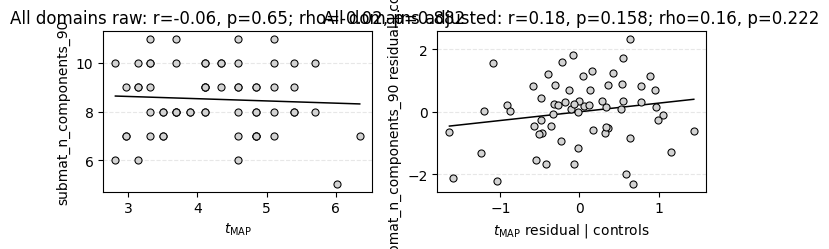

Completeness / quality control figure written to: ../figures/SI_figures/SI_figure_DMS/tmap_vs_submat_n_components_90_adjusted_for_completeness_quality_all_domains.pdf
Per-domain covariates written to: ../figures/SI_figures/SI_figure_DMS/svd_completeness_quality_controls_all_domains.csv
Adjusted-association summary written to: ../figures/SI_figures/SI_figure_DMS/svd_completeness_quality_control_associations_all_domains.csv


In [13]:

# SEARCH_TAG: SVD_COMPLETENESS_QUALITY_CONTROL
# Control: does the SVD-ruggedness association survive after adjusting for
# substitution-matrix completeness and simple measurement-resolution proxies,
# across the full domain set used for the t_MAP analyses?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from scipy.stats import t as student_t
from tqdm.auto import tqdm

SVD_COMPLETENESS_CONTROL_FEATURE = globals().get('FEATURE_TO_PLOT', 'submat_n_components_90')
SVD_COMPLETENESS_OUTDIR = Path('../figures/SI_figures/SI_figure_DMS')
SVD_COMPLETENESS_OUTDIR.mkdir(parents=True, exist_ok=True)
SVD_COMPLETENESS_FIG_PATH = (
    SVD_COMPLETENESS_OUTDIR
    / f'tmap_vs_{SVD_COMPLETENESS_CONTROL_FEATURE}_adjusted_for_completeness_quality_all_domains.pdf'
)
SVD_COMPLETENESS_CONTROL_CSV = (
    SVD_COMPLETENESS_OUTDIR / 'svd_completeness_quality_controls_all_domains.csv'
)
SVD_COMPLETENESS_ASSOC_CSV = (
    SVD_COMPLETENESS_OUTDIR / 'svd_completeness_quality_control_associations_all_domains.csv'
)

if 'dms_subdim_df' not in globals():
    raise RuntimeError('Run Experiment 7 first (requires dms_subdim_df).')
if 'dms_tmap_df' not in globals():
    raise RuntimeError('Run the DMS t_MAP setup cells first (requires dms_tmap_df).')
if 'load_domain_dataframe' not in globals():
    raise RuntimeError('Run the reviewer helper cells first (requires load_domain_dataframe).')

if '_extract_single_mutation_table_sv' in globals():
    _single_mutant_table_fn = _extract_single_mutation_table_sv
elif '_extract_single_mutation_table_local' in globals():
    _single_mutant_table_fn = _extract_single_mutation_table_local
else:
    raise RuntimeError('Need a single-mutant extraction helper; run Experiment 7 or LEFT_SV_STRUCTURAL_CLUSTERING first.')

analysis_files = sorted(
    set(dms_subdim_df['file'].astype(str)).intersection(dms_tmap_df['file'].astype(str))
)
if len(analysis_files) == 0:
    raise RuntimeError('No overlapping domains between dms_subdim_df and dms_tmap_df.')

analysis_dms_subdim_df = dms_subdim_df.loc[dms_subdim_df['file'].astype(str).isin(analysis_files)].copy()
analysis_dms_tmap_df = dms_tmap_df.loc[dms_tmap_df['file'].astype(str).isin(analysis_files)].copy()


def _score_bin_entropy(domain_df):
    if 'DMS_score_bin' not in domain_df.columns:
        return np.nan, np.nan

    bins = domain_df['DMS_score_bin'].dropna().astype(str)
    if len(bins) == 0:
        return np.nan, np.nan

    probs = bins.value_counts(normalize=True).to_numpy(dtype=float)
    n_bins = int(len(probs))
    if n_bins <= 1:
        return 0.0, n_bins

    entropy = float(-(probs * np.log(probs)).sum() / np.log(n_bins))
    return entropy, n_bins


def _zscore_series(values):
    arr = np.asarray(values, dtype=float)
    mu = np.nanmean(arr)
    sigma = np.nanstd(arr, ddof=0)
    if (not np.isfinite(sigma)) or sigma <= 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - mu) / sigma


def _residualize_against_covariates(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    if X.ndim == 1:
        X = X[:, None]

    valid = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    resid = np.full(len(y), np.nan, dtype=float)
    if int(np.sum(valid)) < X.shape[1] + 3:
        return resid, valid

    y_valid = y[valid]
    X_valid = X[valid]
    X_design = np.column_stack([np.ones(len(y_valid)), X_valid])
    beta, *_ = np.linalg.lstsq(X_design, y_valid, rcond=None)
    resid[valid] = y_valid - X_design @ beta
    return resid, valid


def _safe_corr(x, y, method='pearson'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, n_valid

    x = x[valid]
    y = y[valid]
    if np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan, np.nan, n_valid

    if method == 'pearson':
        stat, pval = pearsonr(x, y)
    elif method == 'spearman':
        stat, pval = spearmanr(x, y)
    else:
        raise ValueError(f'Unsupported method: {method}')

    return float(stat), float(pval), n_valid


def _standardized_tmap_coef_with_p(y_feature, x_tmap, covariates):
    y_feature = np.asarray(y_feature, dtype=float)
    x_tmap = np.asarray(x_tmap, dtype=float)
    covariates = np.asarray(covariates, dtype=float)

    if covariates.ndim == 1:
        covariates = covariates[:, None]

    valid = np.isfinite(y_feature) & np.isfinite(x_tmap) & np.all(np.isfinite(covariates), axis=1)
    n_valid = int(np.sum(valid))
    p_cov = int(covariates.shape[1])
    if n_valid < p_cov + 4:
        return np.nan, np.nan, n_valid

    y = _zscore_series(y_feature[valid])
    x = _zscore_series(x_tmap[valid])
    C = np.column_stack([_zscore_series(covariates[valid, j]) for j in range(p_cov)])

    X = np.column_stack([np.ones(n_valid), x, C])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta

    df_resid = n_valid - X.shape[1]
    if df_resid <= 0:
        return np.nan, np.nan, n_valid

    sigma2 = float(np.sum(resid ** 2) / df_resid)
    XtX_inv = np.linalg.pinv(X.T @ X)
    se_tmap = float(np.sqrt(max(0.0, sigma2 * XtX_inv[1, 1])))
    if se_tmap <= 0 or not np.isfinite(se_tmap):
        return np.nan, np.nan, n_valid

    t_stat = float(beta[1] / se_tmap)
    p_value = float(2.0 * student_t.sf(np.abs(t_stat), df=df_resid))
    return float(beta[1]), p_value, n_valid


control_rows = []
for row in tqdm(
    analysis_dms_tmap_df.itertuples(index=False),
    total=len(analysis_dms_tmap_df),
    desc='SVD completeness/quality control (all domains)',
):
    out = {
        'dataset': row.dataset,
        'file': row.file,
        't_map': float(row.t),
        'control_error': '',
    }

    try:
        domain_df = load_domain_dataframe(row.file)
        mut_df = _single_mutant_table_fn(domain_df)

        n_positions_any = int(mut_df['position'].nunique()) if len(mut_df) > 0 else 0
        n_possible_nonwt = int(19 * n_positions_any) if n_positions_any > 0 else 0
        observed_fraction = float(len(mut_df) / n_possible_nonwt) if n_possible_nonwt > 0 else np.nan
        bin_entropy, n_bins_observed = _score_bin_entropy(domain_df)

        if 'domain_fitness_summary' in globals():
            fit_summary = domain_fitness_summary(domain_df)
            fitness_variance = float(fit_summary.get('fitness_variance', np.nan))
        else:
            values = domain_df['DMS_score'].to_numpy(dtype=float)
            fitness_variance = float(np.var(values, ddof=0)) if len(values) else np.nan

        out.update(
            {
                'n_positions_with_any_single_mutant': n_positions_any,
                'n_single_mutants_grouped': int(len(mut_df)),
                'submat_nonwt_observed_fraction': observed_fraction,
                'dms_score_bin_entropy': bin_entropy,
                'n_score_bins_observed': n_bins_observed,
                'fitness_variance_proxy': fitness_variance,
            }
        )
    except Exception as exc:
        out['control_error'] = f'{type(exc).__name__}: {exc}'
        out.update(
            {
                'n_positions_with_any_single_mutant': np.nan,
                'n_single_mutants_grouped': np.nan,
                'submat_nonwt_observed_fraction': np.nan,
                'dms_score_bin_entropy': np.nan,
                'n_score_bins_observed': np.nan,
                'fitness_variance_proxy': np.nan,
            }
        )

    control_rows.append(out)

svd_completeness_quality_df = (
    analysis_dms_subdim_df.merge(pd.DataFrame(control_rows), on=['dataset', 'file', 't_map'], how='left')
    .sort_values('t_map', ascending=False)
    .reset_index(drop=True)
)
svd_completeness_quality_df['submat_rows_pass_fraction'] = (
    svd_completeness_quality_df['submat_rows_used']
    / svd_completeness_quality_df['n_positions_with_any_single_mutant']
)
svd_completeness_quality_df['submat_missing_fraction_nonwt'] = 1.0 - svd_completeness_quality_df['submat_nonwt_observed_fraction']

control_covariates = [
    'submat_nonwt_observed_fraction',
    'submat_rows_pass_fraction',
    'submat_mean_measured_per_row',
    'dms_score_bin_entropy',
    'fitness_variance_proxy',
]

if 'dim_features' in globals():
    control_features = [feat for feat in dim_features if feat in svd_completeness_quality_df.columns]
else:
    control_features = [SVD_COMPLETENESS_CONTROL_FEATURE]

assoc_rows = []
for feat in control_features:
    tmp = svd_completeness_quality_df[['t_map', feat] + control_covariates].copy().dropna()
    if len(tmp) < len(control_covariates) + 4:
        continue
    if np.unique(tmp['t_map'].to_numpy(dtype=float)).size < 2 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    raw_r, raw_r_p, n_raw = _safe_corr(tmp['t_map'], tmp[feat], method='pearson')
    raw_rho, raw_rho_p, _ = _safe_corr(tmp['t_map'], tmp[feat], method='spearman')

    cov_mat = tmp[control_covariates].to_numpy(dtype=float)
    resid_t, _ = _residualize_against_covariates(tmp['t_map'].to_numpy(dtype=float), cov_mat)
    resid_feat, _ = _residualize_against_covariates(tmp[feat].to_numpy(dtype=float), cov_mat)

    adj_r, adj_r_p, n_adj = _safe_corr(resid_t, resid_feat, method='pearson')
    adj_rho, adj_rho_p, _ = _safe_corr(resid_t, resid_feat, method='spearman')
    beta_tmap, beta_tmap_p, n_model = _standardized_tmap_coef_with_p(
        tmp[feat].to_numpy(dtype=float),
        tmp['t_map'].to_numpy(dtype=float),
        cov_mat,
    )

    assoc_rows.append(
        {
            'feature': feat,
            'n_domains_raw': int(n_raw),
            'raw_pearson_r': raw_r,
            'raw_pearson_p': raw_r_p,
            'raw_spearman_rho': raw_rho,
            'raw_spearman_p': raw_rho_p,
            'n_domains_adjusted': int(n_adj),
            'adjusted_pearson_r': adj_r,
            'adjusted_pearson_p': adj_r_p,
            'adjusted_spearman_rho': adj_rho,
            'adjusted_spearman_p': adj_rho_p,
            'std_tmap_coef': beta_tmap,
            'std_tmap_coef_p': beta_tmap_p,
            'n_domains_model': int(n_model),
        }
    )

svd_completeness_quality_assoc_df = pd.DataFrame(assoc_rows)
if len(svd_completeness_quality_assoc_df) > 0:
    svd_completeness_quality_assoc_df = svd_completeness_quality_assoc_df.sort_values(
        'adjusted_spearman_rho', key=np.abs, ascending=False
    ).reset_index(drop=True)

print(
    f'All-domain subset for completeness control: {len(svd_completeness_quality_df)} domains.'
)
print('Completeness / measurement-quality control covariates:')
display(
    svd_completeness_quality_df[
        [
            'dataset', 't_map', 'submat_rows_used', 'submat_mean_measured_per_row',
            'submat_nonwt_observed_fraction', 'submat_rows_pass_fraction',
            'dms_score_bin_entropy', 'fitness_variance_proxy', 'control_error',
        ]
    ]
)
print('Association summary before and after covariate adjustment:')
display(svd_completeness_quality_assoc_df)

svd_completeness_quality_df.to_csv(SVD_COMPLETENESS_CONTROL_CSV, index=False)
svd_completeness_quality_assoc_df.to_csv(SVD_COMPLETENESS_ASSOC_CSV, index=False)

plot_df = svd_completeness_quality_df[['dataset', 't_map', SVD_COMPLETENESS_CONTROL_FEATURE] + control_covariates].copy().dropna()
if len(plot_df) < len(control_covariates) + 4:
    raise RuntimeError(
        f'Not enough complete cases to plot {SVD_COMPLETENESS_CONTROL_FEATURE} after covariate adjustment.'
    )

x_raw = plot_df['t_map'].to_numpy(dtype=float)
y_raw = plot_df[SVD_COMPLETENESS_CONTROL_FEATURE].to_numpy(dtype=float)
raw_r, raw_r_p, _ = _safe_corr(x_raw, y_raw, method='pearson')
raw_rho, raw_rho_p, _ = _safe_corr(x_raw, y_raw, method='spearman')

cov_plot = plot_df[control_covariates].to_numpy(dtype=float)
x_resid, _ = _residualize_against_covariates(x_raw, cov_plot)
y_resid, _ = _residualize_against_covariates(y_raw, cov_plot)
adj_r, adj_r_p, _ = _safe_corr(x_resid, y_resid, method='pearson')
adj_rho, adj_rho_p, _ = _safe_corr(x_resid, y_resid, method='spearman')
beta_tmap, beta_tmap_p, _ = _standardized_tmap_coef_with_p(y_raw, x_raw, cov_plot)

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6))
ax_raw, ax_adj = axes

# Raw correlation across all domains.
ax_raw.scatter(x_raw, y_raw, s=26, facecolor='lightgrey', edgecolor='black', linewidth=0.75, zorder=3)
coef_raw = np.polyfit(x_raw, y_raw, deg=1)
x_line = np.linspace(np.min(x_raw), np.max(x_raw), 200)
ax_raw.plot(x_line, coef_raw[0] * x_line + coef_raw[1], color='black', linewidth=1.1)
ax_raw.set_xlabel(r'$t_{\mathrm{MAP}}$')
ax_raw.set_ylabel(SVD_COMPLETENESS_CONTROL_FEATURE)
ax_raw.set_title(f'All domains raw: r={raw_r:.2f}, p={raw_r_p:.3g}; rho={raw_rho:.2f}, p={raw_rho_p:.3g}')
ax_raw.grid(axis='y', linestyle='--', alpha=0.3)

# Residualized correlation across all domains.
valid_resid = np.isfinite(x_resid) & np.isfinite(y_resid)
ax_adj.scatter(
    x_resid[valid_resid],
    y_resid[valid_resid],
    s=26,
    facecolor='lightgrey',
    edgecolor='black',
    linewidth=0.75,
    zorder=3,
)
coef_adj = np.polyfit(x_resid[valid_resid], y_resid[valid_resid], deg=1)
xr_line = np.linspace(np.min(x_resid[valid_resid]), np.max(x_resid[valid_resid]), 200)
ax_adj.plot(xr_line, coef_adj[0] * xr_line + coef_adj[1], color='black', linewidth=1.1)
ax_adj.set_xlabel(r'$t_{\mathrm{MAP}}$ residual | controls')
ax_adj.set_ylabel(f'{SVD_COMPLETENESS_CONTROL_FEATURE} residual | controls')
ax_adj.set_title(
    f'All domains adjusted: r={adj_r:.2f}, p={adj_r_p:.3g}; rho={adj_rho:.2f}, p={adj_rho_p:.3g}'
)
ax_adj.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(SVD_COMPLETENESS_FIG_PATH)
plt.show()

print(f'Completeness / quality control figure written to: {SVD_COMPLETENESS_FIG_PATH}')
print(f'Per-domain covariates written to: {SVD_COMPLETENESS_CONTROL_CSV}')
print(f'Adjusted-association summary written to: {SVD_COMPLETENESS_ASSOC_CSV}')


In [14]:
# SEARCH_TAG: LEFT_SV_DOMAIN_VIS_AMFR_4G3O
# Experiment 8b: Domain-specific LEFT-SV structural visualization
import re
import binascii
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from scipy.spatial.distance import pdist, squareform

TARGET_DOMAIN_FILE = 'RL20_AQUAE_Tsuboyama_2023_1GYZ.csv'
TARGET_TOP_K = 3
TARGET_TOP_LOADING_QUANTILE = 0.75
TARGET_NULL_REPS = 500
TARGET_MIN_MEASURED_PER_ROW = 5
TARGET_MIN_ROWS_FOR_SVD = 8
TARGET_RANDOM_SEED = 2026
OUTDIR = Path('../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes')
OUTDIR.mkdir(parents=True, exist_ok=True)

AA20_VIS = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_VIS = re.compile(r'([A-Z])([0-9]+)([A-Z])')

def _parse_single_mutant_token_vis(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None
    m = MUT_TOKEN_RE_VIS.fullmatch(tokens[0])
    if m is None:
        return None
    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa

def _extract_single_mutation_table_vis(domain_df):
    if '_extract_single_mutation_table_sv' in globals():
        return _extract_single_mutation_table_sv(domain_df)
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_vis(getattr(row, 'mutant', ''))
        if parsed is None:
            continue
        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_VIS:
            continue
        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue
        rows.append({'position': int(position), 'wt_aa': wt_aa, 'mut_aa': mut_aa, 'DMS_score': score})
    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])
    mut_df = pd.DataFrame(rows)
    mut_df = mut_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return mut_df

def _infer_wt_sequence_vis(mut_df):
    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    min_pos = int(wt_by_pos.index.min())
    max_pos = int(wt_by_pos.index.max())
    if min_pos != 1:
        raise ValueError('WT sequence fallback expects positions starting at 1.')
    return ''.join(wt_by_pos.reindex(range(1, max_pos + 1)).fillna('X').tolist())

def _mean_pairwise_ca_distance(coords, idx):
    idx = np.asarray(sorted(set(idx)), dtype=int)
    if len(idx) < 2:
        return np.nan
    pts = coords[idx]
    d = squareform(pdist(pts))
    tri = np.triu_indices(len(idx), k=1)
    return float(np.mean(d[tri]))

def _filter_to_first_model_main_chain_pdb(pdb_text_in, chain_id):
    out_lines = []
    has_model_records = False
    in_first_model = True
    for line in pdb_text_in.splitlines():
        rec = line[:6].strip()
        if rec == 'MODEL':
            has_model_records = True
            try:
                model_no = int(line[10:14].strip())
            except Exception:
                model_no = 1
            in_first_model = (model_no == 1)
            continue
        if rec == 'ENDMDL':
            if has_model_records and in_first_model:
                break
            continue
        if has_model_records and not in_first_model:
            continue
        if rec in {'ATOM', 'HETATM', 'TER'}:
            if len(line) < 22:
                continue
            line_chain = (line[21].strip() or '_')
            if line_chain != chain_id:
                continue
            out_lines.append(line)
    if len(out_lines) == 0:
        raise ValueError(f'No atoms found for selected chain {chain_id} in first model.')
    out_lines.append('END')
    return '\n'.join(out_lines) + '\n'

# ── Coolwarm colour mapping ──
_COOLWARM_CMAP = cm.get_cmap('coolwarm')

def _loading_to_rgb_hex(value, vmax):
    """Map a loading value to a coolwarm hex colour string for ChimeraX."""
    t = np.clip(value / vmax, -1.0, 1.0)
    # Map from [-1, 1] to [0, 1] for the colourmap
    cmap_val = (t + 1.0) / 2.0
    r, g, b, _ = _COOLWARM_CMAP(cmap_val)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

required = ['load_domain_dataframe', 'extract_pdb_id_from_file', 'fetch_pdb_text',
            'extract_main_chain_ensemble', 'align_dms_to_structure_positions']
missing_required = [name for name in required if name not in globals()]
if missing_required:
    raise RuntimeError(f'Run prerequisite reviewer cells first; missing symbols: {missing_required}')

if 'dms_tmap_df' in globals() and TARGET_DOMAIN_FILE in set(dms_tmap_df['file']):
    t_value = float(dms_tmap_df.loc[dms_tmap_df['file'] == TARGET_DOMAIN_FILE, 't'].iloc[0])
else:
    t_value = np.nan

# Build substitution matrix and LEFT singular vectors.
domain_df = load_domain_dataframe(TARGET_DOMAIN_FILE)
mut_df = _extract_single_mutation_table_vis(domain_df)
if len(mut_df) == 0:
    raise ValueError('No usable single-mutant records for target domain.')

submat_df = (
    mut_df
    .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
    .reindex(columns=AA20_VIS)
    .sort_index()
).copy(deep=True)

wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}
arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)

for r_i, pos in enumerate(submat_df.index.to_numpy()):
    wt = wt_by_pos.get(int(pos), None)
    c_i = col_to_idx.get(wt, None)
    if c_i is not None:
        arr_all[r_i, c_i] = np.nan

measured_per_row = np.isfinite(arr_all).sum(axis=1)
keep_mask = measured_per_row >= TARGET_MIN_MEASURED_PER_ROW
kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

if arr.shape[0] < TARGET_MIN_ROWS_FOR_SVD:
    raise ValueError(f'Insufficient rows after filtering: {arr.shape[0]} < {TARGET_MIN_ROWS_FOR_SVD}.')

row_means = np.nanmean(arr, axis=1)
nan_mask = ~np.isfinite(arr)
if nan_mask.any():
    arr[nan_mask] = row_means[np.where(nan_mask)[0]]

arr = arr - np.mean(arr, axis=1, keepdims=True)
if not np.isfinite(arr).all() or np.allclose(arr, 0.0):
    raise ValueError('Centered substitution matrix is degenerate.')

U, S, Vt = np.linalg.svd(arr, full_matrices=False)
power = S**2
power_frac = power / np.sum(power)

# Map DMS positions to structure positions.
pdb_id = extract_pdb_id_from_file(TARGET_DOMAIN_FILE)
pdb_text, cache_path = fetch_pdb_text(pdb_id)
residue_df, coords_models, model_ids, main_chain, structure_seq = extract_main_chain_ensemble(pdb_text)
pdb_text_main_chain = _filter_to_first_model_main_chain_pdb(pdb_text, main_chain)
coords = np.asarray(coords_models[0], dtype=float)

if 'infer_wildtype_sequence' in globals():
    wt_seq = infer_wildtype_sequence(domain_df)
else:
    wt_seq = _infer_wt_sequence_vis(mut_df)

dms_to_struct_map, seq_ident = align_dms_to_structure_positions(wt_seq, structure_seq)

mapped_mask = np.array([int(p) in dms_to_struct_map for p in kept_positions], dtype=bool)
if mapped_mask.sum() < TARGET_MIN_ROWS_FOR_SVD:
    raise ValueError('Too few mapped positions for the target domain.')

mapped_dms_positions = kept_positions[mapped_mask]
mapped_struct_idx = np.array([int(dms_to_struct_map[int(p)]) for p in mapped_dms_positions], dtype=int)
U_map = U[mapped_mask, :]

# Aggregate duplicate structure mappings.
k_eff = int(min(TARGET_TOP_K, U_map.shape[1]))
unique_struct = np.array(sorted(set(mapped_struct_idx.tolist())), dtype=int)
loadings_by_axis = np.full((k_eff, len(residue_df)), np.nan, dtype=float)
top_mask_by_axis = np.zeros((k_eff, len(residue_df)), dtype=bool)
axis_stats_rows = []

seed = TARGET_RANDOM_SEED + int(binascii.crc32(TARGET_DOMAIN_FILE.encode('utf-8')) % 1_000_000)
rng = np.random.default_rng(seed)

for ax in range(k_eff):
    ser = pd.DataFrame({'struct_idx': mapped_struct_idx, 'loading': U_map[:, ax]}).groupby('struct_idx', as_index=False)['loading'].mean()
    struct_idx_axis = ser['struct_idx'].to_numpy(dtype=int)
    loading_axis = ser['loading'].to_numpy(dtype=float)
    loadings_by_axis[ax, struct_idx_axis] = loading_axis

    n_select = int(max(3, np.ceil((1.0 - TARGET_TOP_LOADING_QUANTILE) * len(loading_axis))))
    top_local_idx = np.argsort(np.abs(loading_axis))[::-1][:n_select]
    top_struct_idx = np.array(sorted(set(struct_idx_axis[top_local_idx].tolist())), dtype=int)
    top_mask_by_axis[ax, top_struct_idx] = True

    obs_dist = _mean_pairwise_ca_distance(coords, top_struct_idx)
    null_vals = []
    pool = unique_struct
    if len(pool) >= len(top_struct_idx) and len(top_struct_idx) >= 3:
        for _ in range(TARGET_NULL_REPS):
            rand_idx = rng.choice(pool, size=len(top_struct_idx), replace=False)
            null_vals.append(_mean_pairwise_ca_distance(coords, rand_idx))

    null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
    if len(null_arr) > 0 and np.isfinite(obs_dist):
        null_mean = float(np.mean(null_arr))
        null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
        p_cluster = float((np.sum(null_arr <= obs_dist) + 1) / (len(null_arr) + 1))
        z_cluster = float((obs_dist - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
    else:
        null_mean, null_std, p_cluster, z_cluster = np.nan, np.nan, np.nan, np.nan

    axis_stats_rows.append({
        'axis': int(ax + 1),
        'explained_power_fraction': float(power_frac[ax]),
        'n_positions_mapped_axis': int(len(struct_idx_axis)),
        'n_positions_topq': int(len(top_struct_idx)),
        'observed_mean_pair_dist': float(obs_dist) if np.isfinite(obs_dist) else np.nan,
        'null_mean_pair_dist': null_mean,
        'null_std_pair_dist': null_std,
        'z_vs_null': z_cluster,
        'p_cluster_one_sided': p_cluster,
    })

axis_stats_df = pd.DataFrame(axis_stats_rows)
axis_stats_df['n_top_ca_atoms_rendered'] = np.asarray(
    [int(np.sum(top_mask_by_axis[ax])) for ax in range(k_eff)], dtype=int)

# Export residue-level loadings.
export_df = residue_df[['position', 'chain', 'resseq', 'icode', 'resname']].copy()
for ax in range(k_eff):
    export_df[f'axis{ax+1}_loading'] = loadings_by_axis[ax]
    export_df[f'axis{ax+1}_topq'] = top_mask_by_axis[ax]

stem = Path(TARGET_DOMAIN_FILE).stem
loadings_csv = OUTDIR / f'{stem}_left_sv_loadings.csv'
axis_stats_csv = OUTDIR / f'{stem}_left_sv_axis_stats.csv'
export_df.to_csv(loadings_csv, index=False)
axis_stats_df.to_csv(axis_stats_csv, index=False)

# ═══════════════════════════════════════════════════════════════════════
# ChimeraX command generation — explicit per-residue coolwarm colouring
# ═══════════════════════════════════════════════════════════════════════

CHIMERAX_MODEL_SPEC = '#1'
CHIMERAX_CHAIN = str(main_chain).strip() or 'A'

def _cx_residue_token(row):
    resseq = str(row['resseq']).strip()
    icode = str(row['icode']).strip()
    if icode.lower() == 'nan' or icode in {'?', '.'}:
        icode = ''
    return f'{resseq}{icode}' if icode else f'{resseq}'

all_finite = loadings_by_axis[np.isfinite(loadings_by_axis)]
vmax_plot = float(np.max(np.abs(all_finite))) if all_finite.size else 1.0
if not np.isfinite(vmax_plot) or vmax_plot <= 0:
    vmax_plot = 1.0

axis_cmd_rows = []
for ax in range(k_eff):
    axis_idx = ax + 1
    row_stats = axis_stats_df.iloc[ax]

    load_vec = loadings_by_axis[ax]
    finite_idx = np.where(np.isfinite(load_vec))[0]
    top_idx = np.where(top_mask_by_axis[ax])[0]

    load_pairs = []
    for idx in finite_idx:
        r = residue_df.iloc[int(idx)]
        token = _cx_residue_token(r)
        load_pairs.append((token, float(load_vec[idx])))

    top_tokens = []
    for idx in top_idx:
        r = residue_df.iloc[int(idx)]
        top_tokens.append(_cx_residue_token(r))
    top_tokens = sorted(set(top_tokens))

    chain_sel = f"{CHIMERAX_MODEL_SPEC}/{CHIMERAX_CHAIN}"

    cmds = []
    cmds.append(f"# ── Axis {axis_idx} | var={row_stats['explained_power_fraction']:.3f}"
                f" | p_cluster={row_stats['p_cluster_one_sided']:.3g}"
                f" | z={row_stats['z_vs_null']:.2f} ──")

    # 1. Reset: show cartoon only, hide all atoms, colour everything light grey
    cmds.append(f"cartoon {chain_sel}")
    cmds.append(f"style {chain_sel} cartoon")
    cmds.append(f"hide atoms {chain_sel}")
    cmds.append(f"color {chain_sel} #d9d9d9 target c")

    # 2. Colour each residue's CARTOON by its loading (coolwarm)
    for token, val in load_pairs:
        hex_col = _loading_to_rgb_hex(val, vmax_plot)
        cmds.append(f"color {chain_sel}:{token} {hex_col} target c")

    # 3. Show top-quartile residues as spheres, coloured by loading (coolwarm)
    if len(top_tokens) > 0:
        top_sel = ','.join(top_tokens)
        cmds.append(f"show {chain_sel}:{top_sel} atoms")
        cmds.append(f"style {chain_sel}:{top_sel} sphere")
        cmds.append(f"size {chain_sel}:{top_sel} atomRadius 0.7")

        # Colour each top-quartile residue's ATOMS by loading
        token_to_val = {tok: val for tok, val in load_pairs}
        for tok in top_tokens:
            val = token_to_val.get(tok, 0.0)
            hex_col = _loading_to_rgb_hex(val, vmax_plot)
            cmds.append(f"color {chain_sel}:{tok} {hex_col} target a")

    cmds.append(f"view {chain_sel}")

    axis_cmd_rows.append({
        'axis': int(axis_idx),
        'n_residues_with_loadings': int(len(load_pairs)),
        'n_top_residues': int(len(top_tokens)),
        'chimeraX_commands': '\n'.join(cmds),
    })

axis_cmd_df = pd.DataFrame(axis_cmd_rows)

print(f"ChimeraX target model: {CHIMERAX_MODEL_SPEC} (chain {CHIMERAX_CHAIN})")
print('Copy/paste one block at a time into the ChimeraX command line.')
for row in axis_cmd_df.itertuples(index=False):
    print(f"\n=== Axis {row.axis} commands (n_load={row.n_residues_with_loadings}, n_top={row.n_top_residues}) ===")
    print(row.chimeraX_commands)

print('\nAxis-level clustering statistics:')
display(axis_stats_df)
print('Axis command summary:')
display(axis_cmd_df[['axis', 'n_residues_with_loadings', 'n_top_residues']])
print(f'Residue loading table written to: {loadings_csv}')
print(f'Axis stats written to: {axis_stats_csv}')
print('Printed ChimeraX commands for each axis.')

ChimeraX target model: #1 (chain A)
Copy/paste one block at a time into the ChimeraX command line.

=== Axis 1 commands (n_load=59, n_top=15) ===
# ── Axis 1 | var=0.552 | p_cluster=0.002 | z=-4.06 ──
cartoon #1/A
style #1/A cartoon
hide atoms #1/A
color #1/A #d9d9d9 target c
color #1/A:59 #d1dae8 target c
color #1/A:60 #d7dbe2 target c
color #1/A:61 #e4d8d1 target c
color #1/A:62 #c8d7ef target c
color #1/A:63 #7598f6 target c
color #1/A:64 #dcdcdd target c
color #1/A:65 #d2dae7 target c
color #1/A:66 #b6cef9 target c
color #1/A:67 #7a9df8 target c
color #1/A:68 #c7d6f0 target c
color #1/A:69 #e1dad6 target c
color #1/A:70 #b8cff8 target c
color #1/A:71 #dadcdf target c
color #1/A:72 #92b4fe target c
color #1/A:73 #d8dbe1 target c
color #1/A:74 #cdd9ec target c
color #1/A:75 #d7dbe2 target c
color #1/A:76 #d2dae7 target c
color #1/A:77 #7ea1f9 target c
color #1/A:78 #b9d0f8 target c
color #1/A:79 #d2dae7 target c
color #1/A:80 #c0d3f5 target c
color #1/A:81 #7b9ef8 target c
color #1/A

/tmp/ipykernel_700224/3991547947.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _COOLWARM_CMAP = cm.get_cmap('coolwarm')


,axis,explained_power_fraction,n_positions_mapped_axis,n_positions_topq,observed_mean_pair_dist,null_mean_pair_dist,null_std_pair_dist,z_vs_null,p_cluster_one_sided,n_top_ca_atoms_rendered
0,1,0.551905,59,15,10.417661,13.183550,0.680595,-4.063927,0.001996,15
1,2,0.170731,59,15,11.464784,13.188074,0.689507,-2.499306,0.007984,15
2,3,0.095327,59,15,10.812636,13.144186,0.697583,-3.342324,0.003992,15


Axis command summary:


,axis,n_residues_with_loadings,n_top_residues
0,1,59,15
1,2,59,15
2,3,59,15


Residue loading table written to: ../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes/RL20_AQUAE_Tsuboyama_2023_1GYZ_left_sv_loadings.csv
Axis stats written to: ../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes/RL20_AQUAE_Tsuboyama_2023_1GYZ_left_sv_axis_stats.csv
Printed ChimeraX commands for each axis.


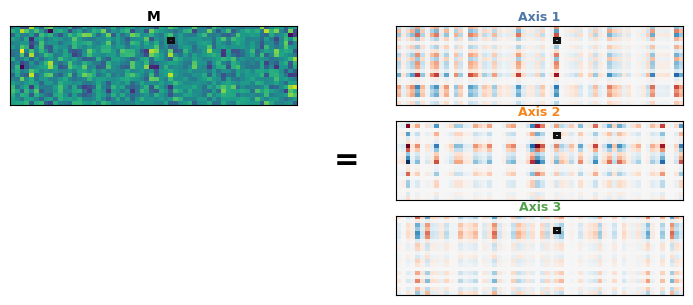

SVD diagram written to: ../figures/figure_2/SVD_diagram.pdf
Selected residue: position 34, amino-acid row 4
Selected component values: [-2.359, -1.548, -0.979]


In [37]:
# SEARCH_TAG: SVD_DIAGRAM_FIRST_HALF
from pathlib import Path
import importlib.util
import sys

module_name = 'svd_diagram_schematics'
module_candidates = [
    Path('svd_diagram_schematics.py'),
    Path('figure_notebooks_rev') / 'svd_diagram_schematics.py',
]
module_path = next((path.resolve() for path in module_candidates if path.exists()), None)
if module_path is None:
    raise FileNotFoundError('Could not locate svd_diagram_schematics.py.')

spec = importlib.util.spec_from_file_location(module_name, module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'Could not load module spec from {module_path}')

svd_diagram_schematics = importlib.util.module_from_spec(spec)
sys.modules[module_name] = svd_diagram_schematics
spec.loader.exec_module(svd_diagram_schematics)

svd_diagram_outdir = next(
    (path for path in [Path('../figures/figure_2'), Path('figures/figure_2')] if path.exists()),
    Path('../figures/figure_2'),
)
svd_diagram_first_half_result = svd_diagram_schematics.render_svd_diagram_first_half(
    outpath=svd_diagram_outdir / 'SVD_diagram.pdf',
    show_plot=True,
)

print(f"SVD diagram written to: {svd_diagram_first_half_result['outpath']}")
print(
    f"Selected residue: position {svd_diagram_first_half_result['selected_position']}, "
    f"amino-acid row {svd_diagram_first_half_result['selected_amino_acid_index']}"
)
print(
    'Selected component values:',
    [round(float(val), 3) for val in svd_diagram_first_half_result['selected_values']],
)


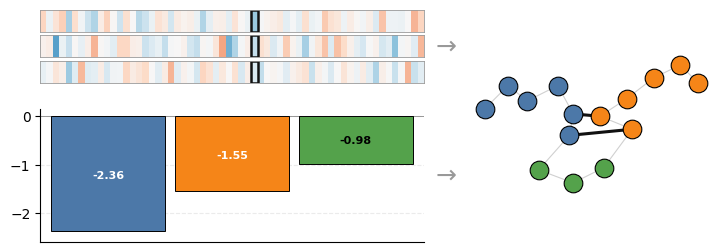

Second-half SVD diagram written to: ../figures/figure_2/SVD_diagram_second_half.pdf
Selected residue: position 34, amino-acid row 4
Selected component values: [-2.359, -1.548, -0.979]


In [6]:
# SEARCH_TAG: SVD_DIAGRAM_SECOND_HALF
from pathlib import Path
import importlib.util
import sys

module_name = 'svd_diagram_schematics'
module_candidates = [
    Path('svd_diagram_schematics.py'),
    Path('figure_notebooks_rev') / 'svd_diagram_schematics.py',
]
module_path = next((path.resolve() for path in module_candidates if path.exists()), None)
if module_path is None:
    raise FileNotFoundError('Could not locate svd_diagram_schematics.py.')

spec = importlib.util.spec_from_file_location(module_name, module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'Could not load module spec from {module_path}')

svd_diagram_schematics = importlib.util.module_from_spec(spec)
sys.modules[module_name] = svd_diagram_schematics
spec.loader.exec_module(svd_diagram_schematics)

svd_diagram_outdir = next(
    (path for path in [Path('../figures/figure_2'), Path('figures/figure_2')] if path.exists()),
    Path('../figures/figure_2'),
)
svd_diagram_second_half_result = svd_diagram_schematics.render_svd_diagram_second_half(
    outpath=svd_diagram_outdir / 'SVD_diagram_second_half.pdf',
    show_plot=True,
)

print(f"Second-half SVD diagram written to: {svd_diagram_second_half_result['outpath']}")
print(
    f"Selected residue: position {svd_diagram_second_half_result['selected_position']}, "
    f"amino-acid row {svd_diagram_second_half_result['selected_amino_acid_index']}"
)
print(
    'Selected component values:',
    [round(float(val), 3) for val in svd_diagram_second_half_result['selected_values']],
)


### SVD-Derived Limiter Boundaries on the Hamming Graph

The cell below implements an SVD analogue of the SH3 limiter idea. It fits a position-by-substitution matrix for each domain, assigns each observed genotype to the singular component with the most negative cumulative contribution, and labels Hamming edges as `boundary` edges when the limiter changes across the edge. The summary tests whether domains with more limiter-boundary structure are also more rugged by `t_MAP`.


SVD limiter boundaries:   0%|          | 0/63 [00:00<?, ?it/s]

Domains processed: 63
Domains with successful limiter-boundary analysis: 63


,dataset,t_map,status,n_components_used,n_genotypes_total,frac_genotypes_unique_limiter,frac_edges_tested,frac_boundary_edges,mean_abs_fitness_delta_boundary,mean_abs_fitness_delta_non_boundary,boundary_abs_fitness_delta_diff,limiter_effective_count,error
0,POLG-PESV,6.343783,ok,5,5131,0.999805,0.988615,0.573646,0.637472,0.472396,0.165077,4.901178,
1,SDA-BACSU,6.009869,ok,5,2771,0.999639,0.981456,0.541537,0.570066,0.519843,0.050223,4.507785,
2,HECD1-HUMAN,5.693530,ok,5,5587,0.996778,0.985268,0.541152,0.528106,0.433145,0.094961,4.888966,
3,YNZC-BACSU,5.693530,ok,5,2301,0.999565,0.980290,0.577821,0.454339,0.386959,0.067380,4.921088,
4,OBSCN-HUMAN,5.393842,ok,5,3198,0.999687,0.975408,0.586985,0.692029,0.527359,0.164670,4.701009,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,5,1009,0.999009,0.897748,0.753672,0.740564,0.597620,0.142944,4.737251,
59,ILF3-HUMAN,2.975646,ok,5,1330,0.999248,0.898642,0.736909,0.552422,0.378091,0.174331,4.747992,
60,OTU7A-HUMAN,2.975646,ok,5,636,0.995283,0.882743,0.747494,0.581257,0.465899,0.115358,4.763381,
61,PKN1-HUMAN,2.819018,ok,5,1302,0.999232,0.896828,0.751967,0.543912,0.448563,0.095348,4.825690,


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,frac_boundary_edges,-0.819005,2.369572e-16,-0.814103,4.958507e-16,63
1,frac_genotypes_unique_limiter,0.190508,1.347681e-01,0.649659,8.381183e-09,63
2,mean_limiter_margin,0.559798,1.842606e-06,0.587090,4.250764e-07,63
3,boundary_abs_fitness_delta_ratio,-0.191551,1.326052e-01,-0.234166,6.471917e-02,63
4,limiter_effective_count,0.132230,3.015718e-01,0.183301,1.504364e-01,63
5,boundary_abs_fitness_delta_diff,-0.063061,6.234305e-01,-0.082439,5.206598e-01,63


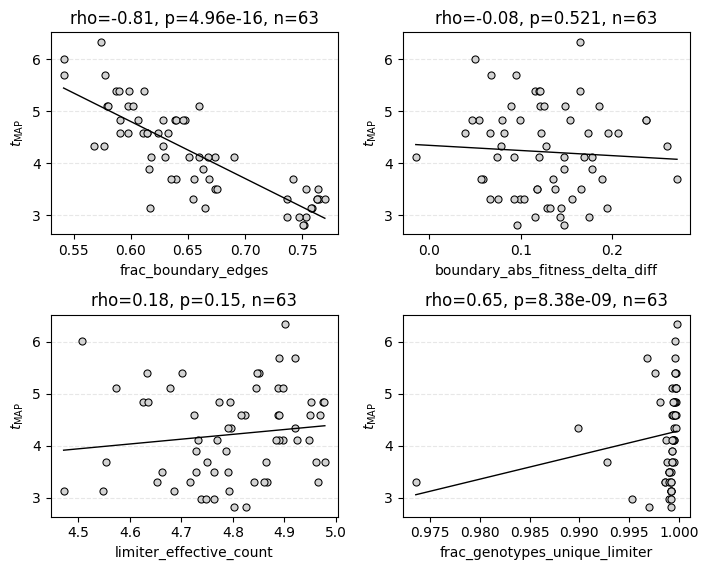

SVD-limiter domain summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_domain_summary.csv
SVD-limiter association summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_associations.csv
SVD-limiter figure written to: ../figures/SI_figures/SI_figure_DMS/tmap_vs_sv_limiter_boundary_metrics.pdf


In [14]:
# SEARCH_TAG: SVD_LIMITER_BOUNDARY_EXPERIMENT
# Experiment 8d: SVD-derived limiter assignments and Hamming-graph boundary edges.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

LIMITER_MIN_MEASURED_PER_ROW = 5
LIMITER_MIN_ROWS_FOR_SVD = 8
LIMITER_VARIANCE_TARGET = 0.90
LIMITER_MIN_COMPONENTS = 2
LIMITER_MAX_COMPONENTS = 5
LIMITER_TIE_TOL = 1e-8
LIMITER_OUTDIR = Path('../figures/SI_figures/SI_figure_DMS')
LIMITER_OUTDIR.mkdir(parents=True, exist_ok=True)
LIMITER_DOMAIN_CSV = LIMITER_OUTDIR / 'sv_limiter_boundary_domain_summary.csv'
LIMITER_ASSOC_CSV = LIMITER_OUTDIR / 'sv_limiter_boundary_associations.csv'
LIMITER_FIG_PATH = LIMITER_OUTDIR / 'tmap_vs_sv_limiter_boundary_metrics.pdf'

if 'dms_tmap_df' not in globals():
    raise RuntimeError('Run the DMS t_MAP setup cells first (requires dms_tmap_df).')
if 'load_domain_dataframe' not in globals():
    raise RuntimeError('Run the reviewer helper cells first (requires load_domain_dataframe).')
if 'build_hamming_landscape_from_df' not in globals():
    raise RuntimeError('Run the reviewer helper cells first (requires build_hamming_landscape_from_df).')
if 'infer_wildtype_sequence' not in globals():
    raise RuntimeError('Run the reviewer helper cells first (requires infer_wildtype_sequence).')

if '_extract_single_mutation_table_sv' in globals():
    _single_mutant_table_limiter = _extract_single_mutation_table_sv
elif '_extract_single_mutation_table_local' in globals():
    _single_mutant_table_limiter = _extract_single_mutation_table_local
else:
    raise RuntimeError('Need a single-mutant extraction helper; run Experiment 7 or LEFT_SV_STRUCTURAL_CLUSTERING first.')

if 'AA20_SV' in globals():
    LIMITER_AA20 = list(AA20_SV)
elif 'AA20_DMS' in globals():
    LIMITER_AA20 = list(AA20_DMS)
else:
    LIMITER_AA20 = list('ACDEFGHIKLMNPQRSTVWY')


def _sequence_mutations_vs_wt(seq, wt_seq):
    seq = str(seq)
    wt_seq = str(wt_seq)
    if len(seq) != len(wt_seq):
        raise ValueError(f'Sequence length mismatch: {len(seq)} vs {len(wt_seq)}.')

    out = []
    for idx, (wt_aa, aa) in enumerate(zip(wt_seq, seq), start=1):
        if aa == wt_aa:
            continue
        out.append((int(idx), wt_aa, aa))
    return out


def _build_limiter_svd_model(domain_df):
    mut_df = _single_mutant_table_limiter(domain_df)
    if len(mut_df) == 0:
        raise ValueError('No usable single-mutation records.')

    submat_df = (
        mut_df
        .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
        .reindex(columns=LIMITER_AA20)
        .sort_index()
    ).copy(deep=True)

    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}

    arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)
    if not arr_all.flags.writeable:
        arr_all = arr_all.copy()

    for r_i, pos in enumerate(submat_df.index.to_numpy(dtype=int)):
        wt_aa = wt_by_pos.get(int(pos), None)
        c_i = col_to_idx.get(wt_aa, None)
        if c_i is not None:
            arr_all[r_i, c_i] = np.nan

    measured_per_row = np.isfinite(arr_all).sum(axis=1)
    keep_mask = measured_per_row >= int(LIMITER_MIN_MEASURED_PER_ROW)
    kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
    arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

    if arr.shape[0] < int(LIMITER_MIN_ROWS_FOR_SVD):
        raise ValueError(
            f'Insufficient rows after filtering: {arr.shape[0]} < {LIMITER_MIN_ROWS_FOR_SVD}.'
        )

    row_means = np.nanmean(arr, axis=1)
    nan_mask = ~np.isfinite(arr)
    if nan_mask.any():
        arr[nan_mask] = row_means[np.where(nan_mask)[0]]

    arr = arr - np.mean(arr, axis=1, keepdims=True)
    if (not np.isfinite(arr).all()) or np.allclose(arr, 0.0):
        raise ValueError('Centered substitution matrix is degenerate.')

    U, S, Vt = np.linalg.svd(arr, full_matrices=False)
    if len(S) < int(LIMITER_MIN_COMPONENTS):
        raise ValueError('Too few singular components for limiter comparison.')

    power = S ** 2
    power_frac = power / power.sum()
    n_components_target = int(np.searchsorted(np.cumsum(power_frac), LIMITER_VARIANCE_TARGET) + 1)
    k_eff = int(min(LIMITER_MAX_COMPONENTS, max(LIMITER_MIN_COMPONENTS, n_components_target), len(S)))
    if k_eff < int(LIMITER_MIN_COMPONENTS):
        raise ValueError('No usable limiter components after truncation.')

    row_sv = U[:, :k_eff] * S[:k_eff]
    position_to_row = {int(pos): i for i, pos in enumerate(kept_positions.astype(int))}
    aa_to_col = {aa: i for i, aa in enumerate(submat_df.columns)}

    return {
        'mut_df': mut_df,
        'wt_seq': infer_wildtype_sequence(domain_df),
        'positions': kept_positions.astype(int),
        'position_to_row': position_to_row,
        'aa_to_col': aa_to_col,
        'row_sv': np.asarray(row_sv, dtype=float),
        'Vt_k': np.asarray(Vt[:k_eff], dtype=float),
        'k_eff': int(k_eff),
        'explained_power_used': float(np.sum(power_frac[:k_eff])),
        'n_components_target_90': int(n_components_target),
        'n_single_mutants': int(len(mut_df)),
        'n_positions_submat': int(len(kept_positions)),
        'mean_measured_per_row': float(np.mean(measured_per_row[keep_mask])) if np.any(keep_mask) else np.nan,
    }


def _assign_limiter_to_sequence(seq, model):
    mutations = _sequence_mutations_vs_wt(seq, model['wt_seq'])
    contributions = np.zeros(model['k_eff'], dtype=float)
    missing_mutations = []

    for pos, wt_aa, mut_aa in mutations:
        row_idx = model['position_to_row'].get(int(pos), None)
        col_idx = model['aa_to_col'].get(mut_aa, None)
        if row_idx is None or col_idx is None:
            missing_mutations.append(f'{wt_aa}{pos}{mut_aa}')
            continue
        contributions += model['row_sv'][row_idx, :] * model['Vt_k'][:, col_idx]

    if len(missing_mutations) > 0:
        return {
            'n_mutations': int(len(mutations)),
            'n_mutations_covered': int(len(mutations) - len(missing_mutations)),
            'all_mutations_covered': False,
            'limiter_component': np.nan,
            'limiter_margin': np.nan,
            'limiter_min_contribution': np.nan,
            'limiter_second_contribution': np.nan,
            'limiter_profile': [float(x) for x in contributions],
            'assignment_status': 'incomplete',
            'missing_mutations': ';'.join(missing_mutations),
        }

    if len(mutations) == 0:
        return {
            'n_mutations': 0,
            'n_mutations_covered': 0,
            'all_mutations_covered': True,
            'limiter_component': np.nan,
            'limiter_margin': np.nan,
            'limiter_min_contribution': 0.0,
            'limiter_second_contribution': 0.0,
            'limiter_profile': [float(x) for x in contributions],
            'assignment_status': 'wt_or_no_mutations',
            'missing_mutations': '',
        }

    order = np.argsort(contributions)
    min_val = float(contributions[order[0]])
    second_val = float(contributions[order[1]]) if len(order) > 1 else np.nan
    margin = float(second_val - min_val) if np.isfinite(second_val) else np.nan

    if (not np.isfinite(margin)) or margin <= float(LIMITER_TIE_TOL):
        limiter_component = np.nan
        assignment_status = 'ambiguous'
    else:
        limiter_component = int(order[0] + 1)
        assignment_status = 'ok'

    return {
        'n_mutations': int(len(mutations)),
        'n_mutations_covered': int(len(mutations)),
        'all_mutations_covered': True,
        'limiter_component': limiter_component,
        'limiter_margin': margin,
        'limiter_min_contribution': min_val,
        'limiter_second_contribution': second_val,
        'limiter_profile': [float(x) for x in contributions],
        'assignment_status': assignment_status,
        'missing_mutations': '',
    }


def _summarize_limiter_boundaries_for_domain(file_name, dataset_name, t_map_value):
    out = {
        'dataset': dataset_name,
        'file': file_name,
        't_map': float(t_map_value),
        'status': 'ok',
        'error': '',
        'n_single_mutants': np.nan,
        'n_positions_submat': np.nan,
        'submat_mean_measured_per_row': np.nan,
        'n_components_used': np.nan,
        'explained_power_fraction_used': np.nan,
        'n_components_target_90': np.nan,
        'n_genotypes_total': np.nan,
        'n_genotypes_unique_limiter': np.nan,
        'n_genotypes_incomplete_limiter': np.nan,
        'n_genotypes_ambiguous_limiter': np.nan,
        'frac_genotypes_unique_limiter': np.nan,
        'n_limiters_observed': np.nan,
        'limiter_entropy': np.nan,
        'limiter_effective_count': np.nan,
        'mean_limiter_margin': np.nan,
        'median_limiter_margin': np.nan,
        'n_edges_total': np.nan,
        'n_edges_tested': np.nan,
        'n_boundary_edges': np.nan,
        'n_non_boundary_edges': np.nan,
        'frac_edges_tested': np.nan,
        'frac_boundary_edges': np.nan,
        'mean_abs_fitness_delta_boundary': np.nan,
        'mean_abs_fitness_delta_non_boundary': np.nan,
        'boundary_abs_fitness_delta_diff': np.nan,
        'boundary_abs_fitness_delta_ratio': np.nan,
    }

    try:
        domain_df = load_domain_dataframe(file_name).reset_index(drop=True)
        model = _build_limiter_svd_model(domain_df)
        landscape, fitness = build_hamming_landscape_from_df(domain_df)
        fitness = np.asarray(fitness, dtype=float)

        genotype_rows = []
        for idx, row in enumerate(domain_df.itertuples(index=False)):
            limiter_out = _assign_limiter_to_sequence(getattr(row, 'mutated_sequence'), model)
            genotype_rows.append(
                {
                    'node_idx': int(idx),
                    'mutant': getattr(row, 'mutant', ''),
                    'mutated_sequence': getattr(row, 'mutated_sequence'),
                    'fitness': float(fitness[idx]),
                    **limiter_out,
                }
            )

        genotype_df = pd.DataFrame(genotype_rows)
        unique_mask = genotype_df['assignment_status'].eq('ok') & genotype_df['limiter_component'].notna()
        incomplete_mask = genotype_df['assignment_status'].eq('incomplete')
        ambiguous_mask = genotype_df['assignment_status'].isin(['ambiguous', 'wt_or_no_mutations'])

        limiter_counts = (
            genotype_df.loc[unique_mask, 'limiter_component']
            .astype(int)
            .value_counts()
            .sort_index()
        )
        if len(limiter_counts) > 0:
            limiter_probs = limiter_counts.to_numpy(dtype=float) / limiter_counts.sum()
            limiter_entropy = float(-(limiter_probs * np.log(limiter_probs)).sum())
            limiter_effective_count = float(np.exp(limiter_entropy))
        else:
            limiter_entropy = np.nan
            limiter_effective_count = np.nan

        boundary_deltas = []
        non_boundary_deltas = []
        n_edges_tested = 0
        for u, v in landscape.graph.edges():
            lim_u = genotype_df.at[int(u), 'limiter_component']
            lim_v = genotype_df.at[int(v), 'limiter_component']
            if not (np.isfinite(lim_u) and np.isfinite(lim_v)):
                continue

            n_edges_tested += 1
            delta = float(abs(fitness[int(u)] - fitness[int(v)]))
            if int(lim_u) != int(lim_v):
                boundary_deltas.append(delta)
            else:
                non_boundary_deltas.append(delta)

        mean_boundary = float(np.mean(boundary_deltas)) if len(boundary_deltas) > 0 else np.nan
        mean_non_boundary = float(np.mean(non_boundary_deltas)) if len(non_boundary_deltas) > 0 else np.nan
        boundary_ratio = (
            float(mean_boundary / mean_non_boundary)
            if np.isfinite(mean_boundary) and np.isfinite(mean_non_boundary) and mean_non_boundary != 0
            else np.nan
        )

        out.update(
            {
                'n_single_mutants': int(model['n_single_mutants']),
                'n_positions_submat': int(model['n_positions_submat']),
                'submat_mean_measured_per_row': float(model['mean_measured_per_row']),
                'n_components_used': int(model['k_eff']),
                'explained_power_fraction_used': float(model['explained_power_used']),
                'n_components_target_90': int(model['n_components_target_90']),
                'n_genotypes_total': int(len(genotype_df)),
                'n_genotypes_unique_limiter': int(unique_mask.sum()),
                'n_genotypes_incomplete_limiter': int(incomplete_mask.sum()),
                'n_genotypes_ambiguous_limiter': int(ambiguous_mask.sum()),
                'frac_genotypes_unique_limiter': float(unique_mask.mean()) if len(genotype_df) > 0 else np.nan,
                'n_limiters_observed': int(len(limiter_counts)) if len(limiter_counts) > 0 else 0,
                'limiter_entropy': limiter_entropy,
                'limiter_effective_count': limiter_effective_count,
                'mean_limiter_margin': float(genotype_df.loc[unique_mask, 'limiter_margin'].mean()) if unique_mask.any() else np.nan,
                'median_limiter_margin': float(genotype_df.loc[unique_mask, 'limiter_margin'].median()) if unique_mask.any() else np.nan,
                'n_edges_total': int(landscape.graph.number_of_edges()),
                'n_edges_tested': int(n_edges_tested),
                'n_boundary_edges': int(len(boundary_deltas)),
                'n_non_boundary_edges': int(len(non_boundary_deltas)),
                'frac_edges_tested': float(n_edges_tested / landscape.graph.number_of_edges()) if landscape.graph.number_of_edges() > 0 else np.nan,
                'frac_boundary_edges': float(len(boundary_deltas) / n_edges_tested) if n_edges_tested > 0 else np.nan,
                'mean_abs_fitness_delta_boundary': mean_boundary,
                'mean_abs_fitness_delta_non_boundary': mean_non_boundary,
                'boundary_abs_fitness_delta_diff': float(mean_boundary - mean_non_boundary) if np.isfinite(mean_boundary) and np.isfinite(mean_non_boundary) else np.nan,
                'boundary_abs_fitness_delta_ratio': boundary_ratio,
            }
        )
    except Exception as exc:
        out['status'] = 'error'
        out['error'] = f'{type(exc).__name__}: {exc}'

    return out


limiter_domain_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='SVD limiter boundaries'):
    limiter_domain_rows.append(
        _summarize_limiter_boundaries_for_domain(row.file, row.dataset, row.t)
    )

sv_limiter_domain_df = pd.DataFrame(limiter_domain_rows).sort_values('t_map', ascending=False).reset_index(drop=True)

limiter_features = [
    'frac_boundary_edges',
    'boundary_abs_fitness_delta_diff',
    'boundary_abs_fitness_delta_ratio',
    'limiter_effective_count',
    'frac_genotypes_unique_limiter',
    'mean_limiter_margin',
]

assoc_rows = []
for feat in limiter_features:
    tmp = sv_limiter_domain_df.loc[
        sv_limiter_domain_df['status'].eq('ok')
        & np.isfinite(sv_limiter_domain_df['t_map'].to_numpy(dtype=float))
        & np.isfinite(sv_limiter_domain_df[feat].to_numpy(dtype=float)),
        ['t_map', feat],
    ].copy()
    if len(tmp) < 5:
        continue
    if np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    pear_r, pear_p = pearsonr(x, y)
    spear_rho, spear_p = spearmanr(x, y)
    assoc_rows.append(
        {
            'feature': feat,
            'pearson_r': float(pear_r),
            'pearson_p': float(pear_p),
            'spearman_rho': float(spear_rho),
            'spearman_p': float(spear_p),
            'n_domains': int(len(tmp)),
        }
    )

sv_limiter_assoc_df = pd.DataFrame(assoc_rows)
if len(sv_limiter_assoc_df) > 0:
    sv_limiter_assoc_df = sv_limiter_assoc_df.sort_values('spearman_rho', key=np.abs, ascending=False).reset_index(drop=True)

print('Domains processed:', len(sv_limiter_domain_df))
print('Domains with successful limiter-boundary analysis:', int((sv_limiter_domain_df['status'] == 'ok').sum()))

display(
    sv_limiter_domain_df[
        [
            'dataset', 't_map', 'status', 'n_components_used', 'n_genotypes_total',
            'frac_genotypes_unique_limiter', 'frac_edges_tested', 'frac_boundary_edges',
            'mean_abs_fitness_delta_boundary', 'mean_abs_fitness_delta_non_boundary',
            'boundary_abs_fitness_delta_diff', 'limiter_effective_count', 'error',
        ]
    ]
)

display(sv_limiter_assoc_df)

sv_limiter_domain_df.to_csv(LIMITER_DOMAIN_CSV, index=False)
sv_limiter_assoc_df.to_csv(LIMITER_ASSOC_CSV, index=False)

plot_features = [
    'frac_boundary_edges',
    'boundary_abs_fitness_delta_diff',
    'limiter_effective_count',
    'frac_genotypes_unique_limiter',
]
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), squeeze=False)

for ax, feat in zip(axes.ravel(), plot_features):
    tmp = sv_limiter_domain_df.loc[
        sv_limiter_domain_df['status'].eq('ok')
        & np.isfinite(sv_limiter_domain_df['t_map'].to_numpy(dtype=float))
        & np.isfinite(sv_limiter_domain_df[feat].to_numpy(dtype=float)),
        ['t_map', feat],
    ].copy()

    if len(tmp) < 3 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        ax.text(0.5, 0.5, f'{feat}: insufficient data', ha='center', va='center')
        ax.set_axis_off()
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    rho, rho_p = spearmanr(x, y)

    ax.scatter(x, y, s=26, facecolor='lightgrey', edgecolor='black', linewidth=0.75, zorder=3)
    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(np.min(x), np.max(x), 200)
    ax.plot(x_line, coef[0] * x_line + coef[1], color='black', linewidth=1.0, zorder=4)
    ax.set_xlabel(feat)
    ax.set_ylabel(r'$t_{\mathrm{MAP}}$')
    ax.set_title(f'rho={rho:.2f}, p={rho_p:.3g}, n={len(tmp)}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(LIMITER_FIG_PATH)
plt.show()

print(f'SVD-limiter domain summary written to: {LIMITER_DOMAIN_CSV}')
print(f'SVD-limiter association summary written to: {LIMITER_ASSOC_CSV}')
print(f'SVD-limiter figure written to: {LIMITER_FIG_PATH}')


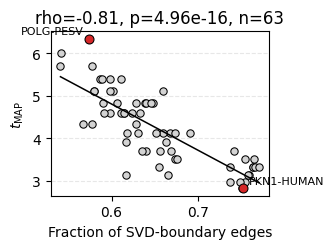

Figure written to: ../figures/figure_2/svd_boundary_edge_fraction_vs_tmap.pdf


In [15]:
# Figure plot for frac_boundary_edges vs t_MAP

from pathlib import Path
from scipy.stats import spearmanr

if 'sv_limiter_domain_df' in globals():
    _sv_boundary_plot_df = sv_limiter_domain_df.copy()
elif 'LIMITER_DOMAIN_CSV' in globals():
    _sv_boundary_plot_df = pd.read_csv(LIMITER_DOMAIN_CSV)
else:
    raise RuntimeError('Run Experiment 8d first (requires sv_limiter_domain_df or LIMITER_DOMAIN_CSV).')

work_df = _sv_boundary_plot_df.loc[
    _sv_boundary_plot_df['status'].eq('ok')
    & np.isfinite(_sv_boundary_plot_df['t_map'].to_numpy(dtype=float))
    & np.isfinite(_sv_boundary_plot_df['frac_boundary_edges'].to_numpy(dtype=float)),
    ['dataset', 'file', 't_map', 'frac_boundary_edges'],
].copy()

if len(work_df) < 3 or np.unique(work_df['frac_boundary_edges'].to_numpy(dtype=float)).size < 2:
    raise RuntimeError('Need at least three valid domains with non-constant frac_boundary_edges.')

work_df = work_df.sort_values(['t_map', 'dataset', 'file']).reset_index(drop=True)
smooth_row = work_df.iloc[0]
rugged_row = work_df.iloc[-1]

x = work_df['frac_boundary_edges'].to_numpy(dtype=float)
y = work_df['t_map'].to_numpy(dtype=float)
rho, rho_p = spearmanr(x, y)
coef = np.polyfit(x, y, deg=1)
x_line = np.linspace(np.min(x), np.max(x), 200)

fig, ax = plt.subplots(figsize=(3.4, 2.6))
ax.scatter(x, y, s=28, facecolor='lightgrey', edgecolor='black', linewidth=0.75, zorder=3)
ax.plot(x_line, coef[0] * x_line + coef[1], color='black', linewidth=1.1, zorder=4)

for row, dx, dy, ha in [
    (smooth_row, 0.006, 0.06, 'left'),
    (rugged_row, -0.006, 0.06, 'right'),
]:
    ax.scatter(
        [row['frac_boundary_edges']],
        [row['t_map']],
        s=42,
        facecolor='#d62728',
        edgecolor='black',
        linewidth=0.75,
        zorder=5,
    )
    ax.text(
        float(row['frac_boundary_edges']) + dx,
        float(row['t_map']) + dy,
        str(row['dataset']),
        fontsize=8,
        ha=ha,
        va='bottom',
    )

ax.set_xlabel('Fraction of SVD-boundary edges')
ax.set_ylabel(r'$t_{\mathrm{MAP}}$')
ax.set_title(f'rho={rho:.2f}, p={rho_p:.3g}, n={len(work_df)}')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'svd_boundary_edge_fraction_vs_tmap.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


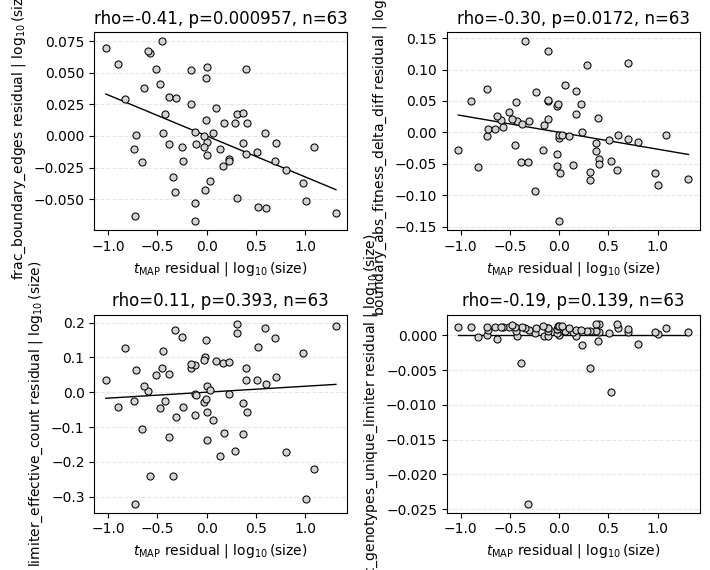

Domains with valid size-control data: 63
Size covariate: log10(n_genotypes_total)


,dataset,t_map,n_genotypes_total,log10_landscape_size,frac_boundary_edges,boundary_abs_fitness_delta_diff,limiter_effective_count,frac_genotypes_unique_limiter
0,POLG-PESV,6.343783,5131,3.710202,0.573646,0.165077,4.901178,0.999805
1,SDA-BACSU,6.009869,2771,3.442637,0.541537,0.050223,4.507785,0.999639
2,HECD1-HUMAN,5.693530,5587,3.747179,0.541152,0.094961,4.888966,0.996778
3,YNZC-BACSU,5.693530,2301,3.361917,0.577821,0.067380,4.921088,0.999565
4,OBSCN-HUMAN,5.393842,3198,3.504878,0.586985,0.164670,4.701009,0.999687
...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,1009,3.003891,0.753672,0.142944,4.737251,0.999009
59,ILF3-HUMAN,2.975646,1330,3.123852,0.736909,0.174331,4.747992,0.999248
60,OTU7A-HUMAN,2.975646,636,2.803457,0.747494,0.115358,4.763381,0.995283
61,PKN1-HUMAN,2.819018,1302,3.114611,0.751967,0.095348,4.825690,0.999232


,feature,size_covariate,n_domains_raw,raw_pearson_r,raw_pearson_p,raw_spearman_rho,raw_spearman_p,n_domains_adjusted,adjusted_pearson_r,adjusted_pearson_p,adjusted_spearman_rho,adjusted_spearman_p,std_tmap_coef,std_tmap_coef_p,n_domains_model
0,frac_boundary_edges,log10_n_genotypes_total,63,-0.819005,2.369572e-16,-0.814103,4.958507e-16,63,-0.457362,0.000164,-0.406154,0.000957,-0.432582,0.000186,63
1,boundary_abs_fitness_delta_ratio,log10_n_genotypes_total,63,-0.191551,1.326052e-01,-0.234166,6.471917e-02,63,-0.287470,0.022343,-0.324117,0.009557,-0.484948,0.023480,63
2,boundary_abs_fitness_delta_diff,log10_n_genotypes_total,63,-0.063061,6.234305e-01,-0.082439,5.206598e-01,63,-0.250797,0.047413,-0.299299,0.017175,-0.420882,0.049283,63
3,mean_limiter_margin,log10_n_genotypes_total,63,0.559798,1.842606e-06,0.587090,4.250764e-07,63,0.222808,0.079225,0.248656,0.049402,0.311750,0.081747,63
4,frac_genotypes_unique_limiter,log10_n_genotypes_total,63,0.190508,1.347681e-01,0.649659,8.381183e-09,63,0.000014,0.999913,-0.188700,0.138577,0.000023,0.999913,63
5,limiter_effective_count,log10_n_genotypes_total,63,0.132230,3.015718e-01,0.183301,1.504364e-01,63,0.071364,0.578346,0.109591,0.392544,0.119672,0.581503,63


Size-control domain summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_size_control_domain_summary.csv
Size-control association summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_size_control_associations.csv
Size-control figure written to: ../figures/SI_figures/SI_figure_DMS/tmap_vs_sv_limiter_boundary_metrics_adjusted_for_size.pdf


In [16]:
# SEARCH_TAG: SVD_LIMITER_BOUNDARY_EXPERIMENT WITH SIZE REGRESSION CONTROL
from pathlib import Path
import importlib.util
import sys

module_name = 'svd_limiter_boundary_size_regression_control'
module_candidates = [
    Path('svd_limiter_boundary_size_regression_control.py'),
    Path('figure_notebooks_rev') / 'svd_limiter_boundary_size_regression_control.py',
]
module_path = next((path.resolve() for path in module_candidates if path.exists()), None)
if module_path is None:
    raise FileNotFoundError('Could not locate svd_limiter_boundary_size_regression_control.py.')

spec = importlib.util.spec_from_file_location(module_name, module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'Could not load module spec from {module_path}')

slb_size = importlib.util.module_from_spec(spec)
sys.modules[module_name] = slb_size
spec.loader.exec_module(slb_size)

limiter_domain_csv = LIMITER_DOMAIN_CSV if 'LIMITER_DOMAIN_CSV' in globals() else next(
    (
        path
        for path in [
            Path('../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_domain_summary.csv'),
            Path('figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_domain_summary.csv'),
        ]
        if path.exists()
    ),
    None,
)
limiter_outdir = LIMITER_OUTDIR if 'LIMITER_OUTDIR' in globals() else next(
    (
        path
        for path in [
            Path('../figures/SI_figures/SI_figure_DMS'),
            Path('figures/SI_figures/SI_figure_DMS'),
        ]
        if path.exists()
    ),
    Path('../figures/SI_figures/SI_figure_DMS'),
)

sv_limiter_size_control_results = slb_size.run_svd_limiter_boundary_size_regression_control(
    sv_limiter_domain_df=sv_limiter_domain_df if 'sv_limiter_domain_df' in globals() else None,
    limiter_domain_csv=limiter_domain_csv,
    outdir=limiter_outdir,
    size_column='n_genotypes_total',
    show_plot=True,
)

sv_limiter_size_control_df = sv_limiter_size_control_results['domain_df']
sv_limiter_size_control_assoc_df = sv_limiter_size_control_results['assoc_df']

print('Domains with valid size-control data:', len(sv_limiter_size_control_df))
print('Size covariate:', r'log10(n_genotypes_total)')

size_control_display_cols = [
    'dataset',
    't_map',
    'n_genotypes_total',
    'log10_landscape_size',
    'frac_boundary_edges',
    'boundary_abs_fitness_delta_diff',
    'limiter_effective_count',
    'frac_genotypes_unique_limiter',
]
display(sv_limiter_size_control_df[[col for col in size_control_display_cols if col in sv_limiter_size_control_df.columns]])
display(sv_limiter_size_control_assoc_df)

print(f"Size-control domain summary written to: {sv_limiter_size_control_results['domain_csv']}")
print(f"Size-control association summary written to: {sv_limiter_size_control_results['assoc_csv']}")
print(f"Size-control figure written to: {sv_limiter_size_control_results['fig_path']}")


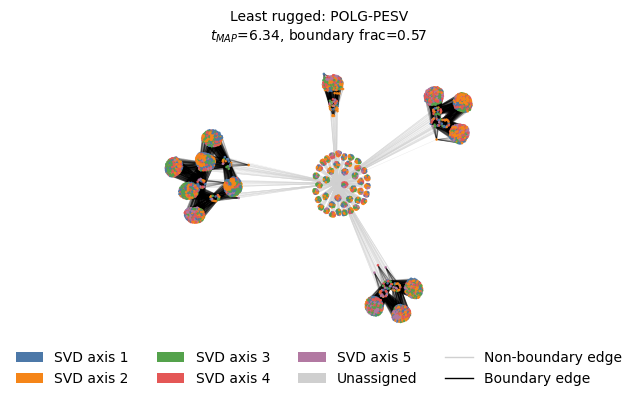

Figure written to: ../figures/figure_2/svd_boundary_example_least_rugged.pdf


In [27]:
# Figure plot for Landscape SVD-axis boundary and paritioning in the least rugged landscape.
# Highest t_map value is treated here as the least rugged example.
# Nodes coloured by the SVD axis they belong to; boundary-crossing edges are black and non-boundary edges are light grey.

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot-size controls.
FIG_WIDTH = 4
FIG_HEIGHT = 4

if 'sv_limiter_domain_df' in globals():
    _sv_limiter_examples_df = sv_limiter_domain_df.copy()
elif 'LIMITER_DOMAIN_CSV' in globals():
    _sv_limiter_examples_df = pd.read_csv(LIMITER_DOMAIN_CSV)
else:
    raise RuntimeError('Run Experiment 8d first (requires sv_limiter_domain_df or LIMITER_DOMAIN_CSV).')

if '_build_limiter_svd_model' not in globals() or '_assign_limiter_to_sequence' not in globals():
    raise RuntimeError('Run Experiment 8d first (needs _build_limiter_svd_model and _assign_limiter_to_sequence).')

if '_reviewer_get_graph_layout' not in globals():
    def _reviewer_get_graph_layout(graph, cache_key, seed=0):
        cache = globals().setdefault('_reviewer_graph_layout_cache', {})
        if cache_key in cache:
            return cache[cache_key]

        pos = None
        for module_name in ('networkx.drawing.nx_agraph', 'networkx.drawing.nx_pydot'):
            try:
                graphviz_layout = __import__(module_name, fromlist=['graphviz_layout']).graphviz_layout
                pos = graphviz_layout(graph, prog='sfdp')
                break
            except Exception:
                continue

        if pos is None:
            try:
                pos = nx.spectral_layout(graph, dim=2)
                pos = nx.spring_layout(graph, seed=seed, pos=pos, iterations=40)
            except Exception:
                pos = nx.spring_layout(graph, seed=seed, iterations=80)

        pos = {int(node): np.asarray(coords, dtype=float)[:2] for node, coords in pos.items()}
        cache[cache_key] = pos
        return pos

work_df = _sv_limiter_examples_df.loc[
    _sv_limiter_examples_df['status'].eq('ok')
    & np.isfinite(_sv_limiter_examples_df['t_map'].to_numpy(dtype=float)),
    ['dataset', 'file', 't_map', 'frac_boundary_edges'],
].copy()
if work_df.empty:
    raise RuntimeError('Need at least one successful SVD-limiter domain for the example plot.')

work_df = work_df.sort_values(['t_map', 'dataset', 'file']).reset_index(drop=True)
least_rugged_row = work_df.iloc[-1]

component_palette = {
    1: '#4C78A8',
    2: '#F58518',
    3: '#54A24B',
    4: '#E45756',
    5: '#B279A2',
    6: '#72B7B2',
}
undefined_color = '#CFCFCF'

domain_df = load_domain_dataframe(least_rugged_row.file).reset_index(drop=True)
landscape, _ = build_hamming_landscape_from_df(domain_df)
model = _build_limiter_svd_model(domain_df)

node_labels = np.full(len(domain_df), np.nan, dtype=float)
for idx, geno_row in enumerate(domain_df.itertuples(index=False)):
    limiter_out = _assign_limiter_to_sequence(getattr(geno_row, 'mutated_sequence'), model)
    limiter_component = limiter_out.get('limiter_component', np.nan)
    if limiter_out.get('assignment_status') == 'ok' and np.isfinite(limiter_component):
        node_labels[int(idx)] = int(limiter_component)

finite_labels = node_labels[np.isfinite(node_labels)]
observed_components = set(int(x) for x in np.unique(finite_labels).astype(int)) if len(finite_labels) > 0 else set()
has_unassigned = bool(np.any(~np.isfinite(node_labels)))

boundary_edges = [
    (int(u), int(v))
    for u, v in landscape.graph.edges()
    if np.isfinite(node_labels[int(u)])
    and np.isfinite(node_labels[int(v)])
    and int(node_labels[int(u)]) != int(node_labels[int(v)])
]
boundary_edge_set = set(boundary_edges)
non_boundary_edges = [
    (int(u), int(v))
    for u, v in landscape.graph.edges()
    if (int(u), int(v)) not in boundary_edge_set
]
pos = _reviewer_get_graph_layout(
    landscape.graph,
    cache_key=(str(least_rugged_row.file), 'svd_limiter_boundary'),
    seed=0,
)

example = {
    'label': 'Least rugged',
    'dataset': str(least_rugged_row.dataset),
    't_map': float(least_rugged_row.t_map),
    'frac_boundary_edges': float(least_rugged_row.frac_boundary_edges),
    'graph': landscape.graph,
    'node_labels': node_labels,
    'boundary_edges': boundary_edges,
    'non_boundary_edges': non_boundary_edges,
    'pos': pos,
}

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

graph = example['graph']
node_order = [int(node) for node in sorted(graph.nodes())]
node_colors = [
    component_palette.get(int(example['node_labels'][node]), undefined_color)
    if np.isfinite(example['node_labels'][node])
    else undefined_color
    for node in node_order
]
node_size = float(np.clip(250.0 / np.sqrt(max(len(node_order), 1)), 3.0, 10.0))

if example['non_boundary_edges']:
    nx.draw_networkx_edges(
        graph,
        example['pos'],
        ax=ax,
        edgelist=example['non_boundary_edges'],
        edge_color='#d0d0d0',
        width=0.22,
        alpha=0.6,
    )
if example['boundary_edges']:
    nx.draw_networkx_edges(
        graph,
        example['pos'],
        ax=ax,
        edgelist=example['boundary_edges'],
        edge_color='black',
        width=0.55,
        alpha=0.22,
    )
nx.draw_networkx_nodes(
    graph,
    example['pos'],
    ax=ax,
    nodelist=node_order,
    node_color=node_colors,
    node_size=node_size,
    linewidths=0.0,
    alpha=0.95,
)
ax.set_title(
    f"{example['label']}: {example['dataset']}\n$t_{{MAP}}$={example['t_map']:.2f}, boundary frac={example['frac_boundary_edges']:.2f}",
    fontsize=10,
)
ax.set_axis_off()

legend_handles = [
    Patch(facecolor=component_palette[k], edgecolor='none', label=f'SVD axis {k}')
    for k in sorted(observed_components)
]
if has_unassigned:
    legend_handles.append(Patch(facecolor=undefined_color, edgecolor='none', label='Unassigned'))
legend_handles.append(Line2D([0], [0], color='#d0d0d0', linewidth=1.0, label='Non-boundary edge'))
legend_handles.append(Line2D([0], [0], color='black', linewidth=1.0, label='Boundary edge'))
fig.legend(handles=legend_handles, loc='lower center', ncol=min(4, len(legend_handles)), frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'svd_boundary_example_least_rugged.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


In [17]:
# SEARCH_TAG: SVD_LIMITER_STRUCTURE_BOUNDARY
# Experiment 8e: structural context of SVD limiter axes and boundary edges.
from pathlib import Path
import importlib
import structural_limiter_boundary_experiments as slbe

required = [
    'dms_tmap_df',
    'load_domain_dataframe',
    'build_hamming_landscape_from_df',
    '_prepare_left_sv_domain_for_pressure_control',
    '_build_limiter_svd_model',
    '_assign_limiter_to_sequence',
]
missing_required = [name for name in required if name not in globals()]
if missing_required:
    raise RuntimeError(f'Run prerequisite cells first; missing symbols: {missing_required}')

importlib.reload(slbe)

sv_limiter_structure_results = slbe.run_structural_limiter_boundary_checks(
    dms_tmap_df=dms_tmap_df,
    load_domain_dataframe=load_domain_dataframe,
    build_hamming_landscape_from_df=build_hamming_landscape_from_df,
    prepare_left_sv_domain_for_pressure_control=_prepare_left_sv_domain_for_pressure_control,
    build_limiter_svd_model=_build_limiter_svd_model,
    assign_limiter_to_sequence=_assign_limiter_to_sequence,
    outdir=Path('../figures/SI_figures/SI_figure_DMS'),
    load_streamed_frames=False,
)

sv_limiter_structure_domain_df = sv_limiter_structure_results['domain_df']
sv_limiter_structure_axis_df = sv_limiter_structure_results['axis_df']
sv_limiter_structure_axis_pair_df = sv_limiter_structure_results['axis_pair_df']
sv_limiter_structure_position_df = sv_limiter_structure_results['position_df']
sv_limiter_structure_edge_df = sv_limiter_structure_results['edge_df']
sv_limiter_structure_exposure_bin_df = sv_limiter_structure_results['exposure_bin_df']
sv_limiter_structure_exposure_bin_domain_df = sv_limiter_structure_results['exposure_bin_domain_df']
sv_limiter_structure_logistic_df = sv_limiter_structure_results['logistic_df']
sv_limiter_structure_mutation_df = sv_limiter_structure_results['mutation_df']
sv_limiter_structure_summary_df = sv_limiter_structure_results['summary_df']

display(sv_limiter_structure_summary_df)
display(sv_limiter_structure_logistic_df)
display(sv_limiter_structure_mutation_df)
display(
    sv_limiter_structure_domain_df[
        [
            'dataset',
            't_map',
            'status',
            'direct_sasa_status',
            'n_axes_profiled',
            'axis1_vs_axis2_exposure_mwu_p',
            'axis1_vs_axis2_relative_sasa_mwu_p',
            'boundary_vs_non_boundary_exposure_mwu_p',
            'boundary_vs_non_boundary_relative_sasa_mwu_p',
            'boundary_vs_non_boundary_abs_exposure_dev_mwu_p',
            'boundary_margin_vs_abs_exposure_dev_spearman_rho',
            'boundary_bin_interior_peak',
            'boundary_axis_exposure_gap_enrichment_diff',
            'boundary_cross_core_surface_switch_fraction',
            'boundary_cross_core_surface_switch_expected_fraction',
            'boundary_cross_core_surface_switch_chisq_p',
            'error',
        ]
    ]
)

print(f"Domain summary written to: {sv_limiter_structure_results['domain_csv']}")
print(f"Axis summary written to: {sv_limiter_structure_results['axis_csv']}")
print(f"Axis-pair summary written to: {sv_limiter_structure_results['axis_pair_csv']}")
print(f"Position summary written to: {sv_limiter_structure_results['position_csv']}")
print(f"Edge details written to: {sv_limiter_structure_results['edge_csv']}")
print(f"Exposure-bin details written to: {sv_limiter_structure_results['exposure_bin_csv']}")
print(f"Exposure-bin domain summary written to: {sv_limiter_structure_results['exposure_bin_domain_csv']}")
print(f"Logistic summary written to: {sv_limiter_structure_results['logistic_csv']}")
print(f"Mutation summary written to: {sv_limiter_structure_results['mutation_csv']}")
print(f"Aggregate summary written to: {sv_limiter_structure_results['summary_csv']}")
print(f"Figure written to: {sv_limiter_structure_results['fig_path']}")


Structural limiter boundaries:   0%|          | 0/63 [00:00<?, ?it/s]

,metric,n_tested,n_positive,fraction_positive,median_effect,median_p_value
0,Axis 1 vs Axis 2 exposure separation (p<0.05),63,1,0.015873,0.352792,4.000000e-01
1,Any leading-axis exposure pair separation (fra...,63,1,0.015873,0.000000,NaN
2,Boundary vs non-boundary edge exposure differs...,63,47,0.746032,0.015180,8.353561e-12
3,Boundary vs non-boundary relative SASA differs...,63,49,0.777778,0.005790,7.021029e-12
4,Boundary edges sit closer to the exposure medi...,63,16,0.253968,0.019546,3.694585e-14
5,Boundary margins increase away from the exposu...,63,12,0.190476,-0.097132,9.967902e-41
6,Boundary incidence peaks at intermediate expos...,63,20,0.317460,0.001068,NaN
7,Boundary switches enriched for core/surface ax...,54,14,0.259259,-0.000147,1.199309e-01
8,Boundary axis exposure gap exceeds the margina...,63,36,0.571429,0.001223,NaN


,feature,standardized_logit_coef,odds_ratio_per_sd,train_auc,group_cv_auc_mean,group_cv_auc_std,n_edges,status
0,edge_position_exposure_knn_distance,-0.047554,0.953559,0.631437,0.6116,0.012569,1514218,ok
1,edge_position_packing_contact_density,-0.009723,0.990324,0.631437,0.6116,0.012569,1514218,ok
2,edge_position_backbone_curvature_deg,-0.055625,0.945894,0.631437,0.6116,0.012569,1514218,ok
3,edge_position_relative_sasa,0.094243,1.098827,0.631437,0.6116,0.012569,1514218,ok
4,mut_abs_hydrophobicity_change,0.336843,1.400519,0.631437,0.6116,0.012569,1514218,ok
5,mut_abs_volume_change,0.293238,1.340761,0.631437,0.6116,0.012569,1514218,ok


,category,n_edges_in_category,boundary_fraction_in_category,n_edges_outside_category,boundary_fraction_outside_category,boundary_fraction_diff,fisher_odds_ratio,fisher_p
0,Hydrophobic class flip,772561,0.694880,741855,0.539198,0.155681,1.946274,0.0
1,Top quartile |delta hydrophobicity|,387911,0.713318,1126505,0.586007,0.127311,1.757815,0.0
2,Top quartile |delta volume|,380664,0.698810,1133752,0.591692,0.107118,1.601075,0.0


,dataset,t_map,status,direct_sasa_status,n_axes_profiled,axis1_vs_axis2_exposure_mwu_p,axis1_vs_axis2_relative_sasa_mwu_p,boundary_vs_non_boundary_exposure_mwu_p,boundary_vs_non_boundary_relative_sasa_mwu_p,boundary_vs_non_boundary_abs_exposure_dev_mwu_p,boundary_margin_vs_abs_exposure_dev_spearman_rho,boundary_bin_interior_peak,boundary_axis_exposure_gap_enrichment_diff,boundary_cross_core_surface_switch_fraction,boundary_cross_core_surface_switch_expected_fraction,boundary_cross_core_surface_switch_chisq_p,error
0,POLG-PESV,6.343783,ok,ok,5,0.400000,1.000000,7.898865e-10,1.880733e-35,4.470186e-115,0.028781,False,0.003575,0.623530,0.611268,2.141469e-08,
1,SDA-BACSU,6.009869,ok,ok,5,0.700000,0.100000,1.453698e-09,4.541891e-14,1.327619e-75,0.061825,False,0.021066,0.268323,0.238350,1.490760e-27,
2,HECD1-HUMAN,5.693530,ok,ok,5,0.857143,1.000000,9.929111e-02,0.000000e+00,1.379832e-29,-0.097132,False,0.012057,0.455663,0.441074,2.506392e-10,
3,YNZC-BACSU,5.693530,ok,ok,5,1.000000,1.000000,7.689899e-01,5.921244e-43,1.474174e-01,0.041608,False,0.008401,0.418783,0.405161,7.051764e-05,
4,OBSCN-HUMAN,5.393842,ok,ok,5,0.228571,0.057143,7.017322e-04,7.888347e-03,7.619171e-23,-0.068437,True,-0.003841,0.512623,0.510904,5.631752e-01,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,ok,5,0.111111,0.063492,7.884756e-01,1.280505e-02,1.224625e-01,-0.210775,False,0.011142,0.468066,0.461443,2.779094e-01,
59,ILF3-HUMAN,2.975646,ok,ok,5,0.400000,0.049746,6.950156e-01,6.970058e-01,6.139353e-02,0.175583,True,0.017727,0.610503,0.579268,3.731269e-09,
60,OTU7A-HUMAN,2.975646,ok,ok,5,0.100000,0.700000,1.447780e-01,3.766953e-02,2.299118e-01,-0.235373,False,0.012005,0.344789,0.327123,2.427891e-02,
61,PKN1-HUMAN,2.819018,ok,ok,5,0.033333,0.033333,4.492368e-01,8.168754e-01,1.697543e-03,-0.090366,False,-0.000705,0.390052,0.386861,5.456895e-01,


Domain summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_domain_summary.csv
Axis summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_axis_summary.csv
Axis-pair summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_axis_pair_tests.csv
Position summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_position_summary.csv
Edge details written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_edge_details.csv
Exposure-bin details written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_exposure_bin_summary.csv
Exposure-bin domain summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_exposure_bin_domain_summary.csv
Logistic summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_structure_boundary_logistic_summary.csv
Mutation summary written to: ../figures/SI_figures/SI_figure_D

In [19]:
# SEARCH_TAG: SVD_LIMITER_BOUNDARY_DIRICHLET_ENERGY
# Experiment 8f: Dirichlet-energy enrichment on SVD limiter boundary edges.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon


def _safe_mannwhitneyu(x, y):
    x = pd.Series(x, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    y = pd.Series(y, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) < 2 or len(y) < 2:
        return np.nan, np.nan, int(len(x)), int(len(y))
    try:
        stat, pval = mannwhitneyu(
            x.to_numpy(dtype=float),
            y.to_numpy(dtype=float),
            alternative='two-sided',
        )
    except ValueError:
        return np.nan, np.nan, int(len(x)), int(len(y))
    return float(stat), float(pval), int(len(x)), int(len(y))


def _safe_wilcoxon_greater(values):
    ser = pd.Series(values, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(ser) < 3:
        return np.nan, np.nan, int(len(ser))
    ser = ser.loc[np.abs(ser.to_numpy(dtype=float)) > 0]
    if len(ser) < 1:
        return 0.0, 1.0, 0
    try:
        stat, pval = wilcoxon(
            ser.to_numpy(dtype=float),
            alternative='greater',
            zero_method='wilcox',
        )
    except ValueError:
        return np.nan, np.nan, int(len(ser))
    return float(stat), float(pval), int(len(ser))


def _safe_ratio(num, den):
    if not np.isfinite(num) or not np.isfinite(den) or den <= 0:
        return np.nan
    return float(num / den)


outdir = Path('../figures/SI_figures/SI_figure_DMS')
edge_csv = outdir / 'sv_limiter_structure_boundary_edge_details.csv'
domain_csv = outdir / 'sv_limiter_structure_boundary_domain_summary.csv'
dirichlet_domain_csv = outdir / 'sv_limiter_boundary_dirichlet_domain_summary.csv'
dirichlet_summary_csv = outdir / 'sv_limiter_boundary_dirichlet_summary.csv'
dirichlet_fig_path = outdir / 'sv_limiter_boundary_dirichlet_summary.pdf'

if 'sv_limiter_structure_edge_df' in globals():
    _svd_boundary_energy_edge_df = sv_limiter_structure_edge_df.copy()
elif edge_csv.exists():
    _svd_boundary_energy_edge_df = pd.read_csv(edge_csv)
else:
    raise RuntimeError('Run Experiment 8e first (requires sv_limiter_structure_edge_df or its cached CSV).')

if 'sv_limiter_structure_domain_df' in globals():
    _svd_boundary_energy_meta_df = sv_limiter_structure_domain_df[['dataset', 'file', 't_map', 'status']].copy()
elif domain_csv.exists():
    _svd_boundary_energy_meta_df = pd.read_csv(domain_csv)[['dataset', 'file', 't_map', 'status']].copy()
else:
    raise RuntimeError('Run Experiment 8e first (requires sv_limiter_structure_domain_df or its cached CSV).')

sv_limiter_boundary_dirichlet_edge_df = _svd_boundary_energy_edge_df.copy()
sv_limiter_boundary_dirichlet_edge_df['edge_has_limiter_labels'] = (
    sv_limiter_boundary_dirichlet_edge_df['edge_has_limiter_labels'].fillna(False).astype(bool)
)
sv_limiter_boundary_dirichlet_edge_df['is_boundary_edge'] = (
    sv_limiter_boundary_dirichlet_edge_df['is_boundary_edge'].fillna(False).astype(bool)
)
sv_limiter_boundary_dirichlet_edge_df['edge_dirichlet_energy'] = np.square(
    pd.to_numeric(sv_limiter_boundary_dirichlet_edge_df['abs_fitness_delta'], errors='coerce')
)
sv_limiter_boundary_dirichlet_edge_df = sv_limiter_boundary_dirichlet_edge_df.loc[
    sv_limiter_boundary_dirichlet_edge_df['edge_has_limiter_labels']
    & np.isfinite(sv_limiter_boundary_dirichlet_edge_df['edge_dirichlet_energy'])
].copy()

if len(sv_limiter_boundary_dirichlet_edge_df) == 0:
    raise RuntimeError('No SVD-limiter edges with finite Dirichlet energy. Run Experiment 8e first.')

_domain_rows = []
for (dataset, file_name), sub in sv_limiter_boundary_dirichlet_edge_df.groupby(['dataset', 'file'], sort=False):
    sub = sub.copy()
    boundary_df = sub.loc[sub['is_boundary_edge']].copy()
    non_boundary_df = sub.loc[~sub['is_boundary_edge']].copy()

    total_energy = float(sub['edge_dirichlet_energy'].sum())
    boundary_energy = float(boundary_df['edge_dirichlet_energy'].sum()) if len(boundary_df) else 0.0
    non_boundary_energy = float(non_boundary_df['edge_dirichlet_energy'].sum()) if len(non_boundary_df) else 0.0
    boundary_edge_fraction = float(len(boundary_df) / len(sub)) if len(sub) else np.nan
    boundary_energy_fraction = _safe_ratio(boundary_energy, total_energy)
    mean_boundary = float(boundary_df['edge_dirichlet_energy'].mean()) if len(boundary_df) else np.nan
    mean_non_boundary = float(non_boundary_df['edge_dirichlet_energy'].mean()) if len(non_boundary_df) else np.nan
    median_boundary = float(boundary_df['edge_dirichlet_energy'].median()) if len(boundary_df) else np.nan
    median_non_boundary = float(non_boundary_df['edge_dirichlet_energy'].median()) if len(non_boundary_df) else np.nan
    mwu_stat, mwu_p, n_b, n_nb = _safe_mannwhitneyu(
        boundary_df['edge_dirichlet_energy'],
        non_boundary_df['edge_dirichlet_energy'],
    )

    _domain_rows.append(
        {
            'dataset': dataset,
            'file': file_name,
            'n_edges_with_limiter_labels': int(len(sub)),
            'n_boundary_edges': int(len(boundary_df)),
            'n_non_boundary_edges': int(len(non_boundary_df)),
            'boundary_edge_fraction': boundary_edge_fraction,
            'total_dirichlet_energy': total_energy,
            'boundary_dirichlet_energy': boundary_energy,
            'non_boundary_dirichlet_energy': non_boundary_energy,
            'boundary_energy_fraction': boundary_energy_fraction,
            'boundary_energy_excess': (
                float(boundary_energy_fraction - boundary_edge_fraction)
                if np.isfinite(boundary_energy_fraction) and np.isfinite(boundary_edge_fraction)
                else np.nan
            ),
            'boundary_energy_enrichment': _safe_ratio(boundary_energy_fraction, boundary_edge_fraction),
            'mean_dirichlet_energy_all': float(sub['edge_dirichlet_energy'].mean()),
            'mean_dirichlet_energy_boundary': mean_boundary,
            'mean_dirichlet_energy_non_boundary': mean_non_boundary,
            'median_dirichlet_energy_boundary': median_boundary,
            'median_dirichlet_energy_non_boundary': median_non_boundary,
            'boundary_minus_non_boundary_mean_dirichlet_energy': (
                float(mean_boundary - mean_non_boundary)
                if np.isfinite(mean_boundary) and np.isfinite(mean_non_boundary)
                else np.nan
            ),
            'boundary_minus_non_boundary_median_dirichlet_energy': (
                float(median_boundary - median_non_boundary)
                if np.isfinite(median_boundary) and np.isfinite(median_non_boundary)
                else np.nan
            ),
            'boundary_to_non_boundary_mean_dirichlet_ratio': _safe_ratio(mean_boundary, mean_non_boundary),
            'boundary_to_non_boundary_median_dirichlet_ratio': _safe_ratio(median_boundary, median_non_boundary),
            'boundary_vs_non_boundary_dirichlet_mwu_stat': mwu_stat,
            'boundary_vs_non_boundary_dirichlet_mwu_p': mwu_p,
            'n_boundary_edges_mwu': n_b,
            'n_non_boundary_edges_mwu': n_nb,
        }
    )

sv_limiter_boundary_dirichlet_domain_df = pd.DataFrame(_domain_rows)
sv_limiter_boundary_dirichlet_domain_df = sv_limiter_boundary_dirichlet_domain_df.merge(
    _svd_boundary_energy_meta_df,
    on=['dataset', 'file'],
    how='left',
)
sv_limiter_boundary_dirichlet_domain_df['log2_boundary_energy_enrichment'] = np.log2(
    sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'].where(
        sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'] > 0
    )
)
sv_limiter_boundary_dirichlet_domain_df['log2_boundary_to_non_boundary_mean_dirichlet_ratio'] = np.log2(
    sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_mean_dirichlet_ratio'].where(
        sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_mean_dirichlet_ratio'] > 0
    )
)
sv_limiter_boundary_dirichlet_domain_df['log2_boundary_to_non_boundary_median_dirichlet_ratio'] = np.log2(
    sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'].where(
        sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'] > 0
    )
)
sv_limiter_boundary_dirichlet_domain_df = sv_limiter_boundary_dirichlet_domain_df.sort_values(
    't_map',
    ascending=False,
).reset_index(drop=True)

_overall_boundary_mask = sv_limiter_boundary_dirichlet_edge_df['is_boundary_edge'].to_numpy(dtype=bool)
_overall_boundary_fraction = float(np.mean(_overall_boundary_mask))
_overall_total_energy = float(sv_limiter_boundary_dirichlet_edge_df['edge_dirichlet_energy'].sum())
_overall_boundary_energy_fraction = float(
    sv_limiter_boundary_dirichlet_edge_df.loc[_overall_boundary_mask, 'edge_dirichlet_energy'].sum() / _overall_total_energy
)
_overall_mean_boundary = float(
    sv_limiter_boundary_dirichlet_edge_df.loc[_overall_boundary_mask, 'edge_dirichlet_energy'].mean()
)
_overall_mean_non_boundary = float(
    sv_limiter_boundary_dirichlet_edge_df.loc[~_overall_boundary_mask, 'edge_dirichlet_energy'].mean()
)
sv_limiter_boundary_dirichlet_overall_df = pd.DataFrame(
    [
        {
            'n_edges_with_limiter_labels': int(len(sv_limiter_boundary_dirichlet_edge_df)),
            'n_boundary_edges': int(np.sum(_overall_boundary_mask)),
            'boundary_edge_fraction': _overall_boundary_fraction,
            'boundary_energy_fraction': _overall_boundary_energy_fraction,
            'boundary_energy_enrichment': _safe_ratio(
                _overall_boundary_energy_fraction,
                _overall_boundary_fraction,
            ),
            'mean_dirichlet_energy_boundary': _overall_mean_boundary,
            'mean_dirichlet_energy_non_boundary': _overall_mean_non_boundary,
            'boundary_to_non_boundary_mean_dirichlet_ratio': _safe_ratio(
                _overall_mean_boundary,
                _overall_mean_non_boundary,
            ),
        }
    ]
)

_enrichment_stat, _enrichment_p, _enrichment_n = _safe_wilcoxon_greater(
    sv_limiter_boundary_dirichlet_domain_df['log2_boundary_energy_enrichment']
)
_mean_ratio_stat, _mean_ratio_p, _mean_ratio_n = _safe_wilcoxon_greater(
    sv_limiter_boundary_dirichlet_domain_df['log2_boundary_to_non_boundary_mean_dirichlet_ratio']
)
_median_ratio_stat, _median_ratio_p, _median_ratio_n = _safe_wilcoxon_greater(
    sv_limiter_boundary_dirichlet_domain_df['log2_boundary_to_non_boundary_median_dirichlet_ratio']
)

sv_limiter_boundary_dirichlet_summary_df = pd.DataFrame(
    [
        {
            'metric': 'Boundary edges capture more Dirichlet energy than expected from edge share',
            'n_tested': int(sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'].notna().sum()),
            'n_positive': int((sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'] > 1.0).sum()),
            'fraction_positive': float((sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'] > 1.0).mean()),
            'median_effect': float(sv_limiter_boundary_dirichlet_domain_df['boundary_energy_enrichment'].median()),
            'median_p_value': np.nan,
            'global_signed_rank_p': _enrichment_p,
            'global_signed_rank_n': _enrichment_n,
        },
        {
            'metric': 'Boundary edges have higher mean Dirichlet energy than non-boundary edges (MWU p<0.05)',
            'n_tested': int(sv_limiter_boundary_dirichlet_domain_df['boundary_vs_non_boundary_dirichlet_mwu_p'].notna().sum()),
            'n_positive': int(
                (
                    (sv_limiter_boundary_dirichlet_domain_df['boundary_vs_non_boundary_dirichlet_mwu_p'] < 0.05)
                    & (sv_limiter_boundary_dirichlet_domain_df['boundary_minus_non_boundary_mean_dirichlet_energy'] > 0)
                ).sum()
            ),
            'fraction_positive': float(
                (
                    (sv_limiter_boundary_dirichlet_domain_df['boundary_vs_non_boundary_dirichlet_mwu_p'] < 0.05)
                    & (sv_limiter_boundary_dirichlet_domain_df['boundary_minus_non_boundary_mean_dirichlet_energy'] > 0)
                ).mean()
            ),
            'median_effect': float(sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_mean_dirichlet_ratio'].median()),
            'median_p_value': float(sv_limiter_boundary_dirichlet_domain_df['boundary_vs_non_boundary_dirichlet_mwu_p'].median()),
            'global_signed_rank_p': _mean_ratio_p,
            'global_signed_rank_n': _mean_ratio_n,
        },
        {
            'metric': 'Boundary edges have higher median Dirichlet energy than non-boundary edges',
            'n_tested': int(sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'].notna().sum()),
            'n_positive': int((sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'] > 1.0).sum()),
            'fraction_positive': float((sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'] > 1.0).mean()),
            'median_effect': float(sv_limiter_boundary_dirichlet_domain_df['boundary_to_non_boundary_median_dirichlet_ratio'].median()),
            'median_p_value': np.nan,
            'global_signed_rank_p': _median_ratio_p,
            'global_signed_rank_n': _median_ratio_n,
        },
    ]
)

sv_limiter_boundary_dirichlet_domain_df.to_csv(dirichlet_domain_csv, index=False)
sv_limiter_boundary_dirichlet_summary_df.to_csv(dirichlet_summary_csv, index=False)

display(sv_limiter_boundary_dirichlet_summary_df)
display(sv_limiter_boundary_dirichlet_overall_df)
display(
    sv_limiter_boundary_dirichlet_domain_df[
        [
            'dataset',
            't_map',
            'status',
            'n_edges_with_limiter_labels',
            'n_boundary_edges',
            'boundary_edge_fraction',
            'boundary_energy_fraction',
            'boundary_energy_enrichment',
            'mean_dirichlet_energy_boundary',
            'mean_dirichlet_energy_non_boundary',
            'boundary_to_non_boundary_mean_dirichlet_ratio',
            'boundary_vs_non_boundary_dirichlet_mwu_p',
        ]
    ]
)

print(f'Dirichlet-energy domain summary written to: {dirichlet_domain_csv}')
print(f'Dirichlet-energy summary written to: {dirichlet_summary_csv}')


,metric,n_tested,n_positive,fraction_positive,median_effect,median_p_value,global_signed_rank_p,global_signed_rank_n
0,Boundary edges capture more Dirichlet energy t...,63,63,1.000000,1.130255,NaN,2.584197e-12,63
1,Boundary edges have higher mean Dirichlet ener...,63,63,1.000000,1.515811,1.230355e-38,2.584197e-12,63
2,Boundary edges have higher median Dirichlet en...,63,62,0.984127,1.621029,NaN,3.447940e-12,63


,n_edges_with_limiter_labels,n_boundary_edges,boundary_edge_fraction,boundary_energy_fraction,boundary_energy_enrichment,mean_dirichlet_energy_boundary,mean_dirichlet_energy_non_boundary,boundary_to_non_boundary_mean_dirichlet_ratio
0,1514416,936844,0.618617,0.714448,1.15491,0.78563,0.509325,1.542494


,dataset,t_map,status,n_edges_with_limiter_labels,n_boundary_edges,boundary_edge_fraction,boundary_energy_fraction,boundary_energy_enrichment,mean_dirichlet_energy_boundary,mean_dirichlet_energy_non_boundary,boundary_to_non_boundary_mean_dirichlet_ratio,boundary_vs_non_boundary_dirichlet_mwu_p
0,POLG-PESV,6.343783,ok,86400,49563,0.573646,0.697395,1.215724,0.788922,0.460579,1.712891,0.000000e+00
1,SDA-BACSU,6.009869,ok,44141,23904,0.541537,0.578168,1.067641,0.602917,0.519599,1.160351,2.275687e-30
2,HECD1-HUMAN,5.693530,ok,85671,46361,0.541152,0.619142,1.144119,0.521033,0.377997,1.378406,2.763654e-221
3,YNZC-BACSU,5.693530,ok,35511,20519,0.577821,0.647556,1.120686,0.383047,0.285339,1.342427,2.672344e-50
4,OBSCN-HUMAN,5.393842,ok,48112,28241,0.586985,0.694805,1.183686,0.842608,0.526017,1.601864,3.061665e-223
...,...,...,...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,8850,6670,0.753672,0.820441,1.088591,1.286856,0.861705,1.493383,1.690613e-09
59,ILF3-HUMAN,2.975646,ok,11783,8683,0.736909,0.842175,1.142848,0.754485,0.396032,1.905109,7.407678e-29
60,OTU7A-HUMAN,2.975646,ok,4788,3579,0.747494,0.813911,1.088854,0.636544,0.430831,1.477480,7.879336e-11
61,PKN1-HUMAN,2.819018,ok,11309,8504,0.751967,0.805238,1.070842,0.702453,0.515096,1.363734,2.711596e-15


Dirichlet-energy domain summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_dirichlet_domain_summary.csv
Dirichlet-energy summary written to: ../figures/SI_figures/SI_figure_DMS/sv_limiter_boundary_dirichlet_summary.csv


Dirichlet-energy share figure written to: ../figures/figure_2/sv_limiter_boundary_dirichlet_energy_share_panel.pdf


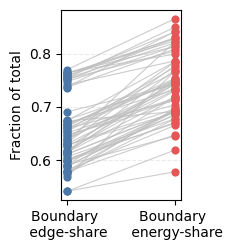

In [27]:
# SEARCH_TAG: SVD_LIMITER_BOUNDARY_DIRICHLET_ENERGY_SHARE
# Figure for Experiment 8f: boundary edge share vs boundary Dirichlet-energy share.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dirichlet_energy_share_fig_path = Path('../figures/figure_2/sv_limiter_boundary_dirichlet_energy_share_panel.pdf')
dirichlet_domain_csv = Path('../figures/figure_2/sv_limiter_boundary_dirichlet_domain_summary.csv')

if 'sv_limiter_boundary_dirichlet_domain_df' in globals():
    _dirichlet_share_df = sv_limiter_boundary_dirichlet_domain_df.copy()
elif dirichlet_domain_csv.exists():
    _dirichlet_share_df = pd.read_csv(dirichlet_domain_csv)
else:
    raise RuntimeError('Run Experiment 8f first (requires sv_limiter_boundary_dirichlet_domain_df or its cached CSV).')

_share_df = _dirichlet_share_df.loc[
    np.isfinite(_dirichlet_share_df['boundary_edge_fraction'].to_numpy(dtype=float))
    & np.isfinite(_dirichlet_share_df['boundary_energy_fraction'].to_numpy(dtype=float))
].copy()

fig, ax = plt.subplots(figsize=(2.4, 2.6))
if len(_share_df) > 0:
    for row in _share_df.itertuples(index=False):
        ax.plot(
            [0, 1],
            [float(row.boundary_edge_fraction), float(row.boundary_energy_fraction)],
            color='0.75',
            linewidth=0.8,
            alpha=0.8,
        )
    ax.scatter(
        np.zeros(len(_share_df)),
        _share_df['boundary_edge_fraction'].to_numpy(dtype=float),
        color='#4C78A8',
        s=24,
        zorder=3,
    )
    ax.scatter(
        np.ones(len(_share_df)),
        _share_df['boundary_energy_fraction'].to_numpy(dtype=float),
        color='#E45756',
        s=24,
        zorder=3,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Boundary \n edge-share', 'Boundary \n energy-share'])
    ax.set_ylabel('Fraction of total')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
else:
    ax.text(0.5, 0.5, 'No boundary-energy comparisons', ha='center', va='center')
    ax.set_axis_off()

fig.tight_layout()
fig.savefig(dirichlet_energy_share_fig_path, bbox_inches='tight')
print(f'Dirichlet-energy share figure written to: {dirichlet_energy_share_fig_path}')


In [8]:
# SEARCH_TAG: SPECTRAL_PARTITION_BOUNDARY_TMAP
# Experiment 9a: spectral partitioning on the fitness-weighted Hamming graph.
from pathlib import Path
import importlib
import spectral_boundary_experiments as sbe

importlib.reload(sbe)

spectral_partition_results = sbe.run_spectral_partition_boundary_tmap(
    dms_tmap_df=dms_tmap_df,
    load_domain_dataframe=load_domain_dataframe,
    build_hamming_landscape_from_df=build_hamming_landscape_from_df,
    compute_tmap_on_landscape_values=compute_tmap_on_landscape_values,
    outdir=Path('../figures/SI_figures/SI_figure_DMS'),
    load_streamed_frames=False,
)

spectral_partition_domain_df = spectral_partition_results['domain_df']
spectral_partition_assoc_df = spectral_partition_results['assoc_df']
spectral_partition_domain_csv = spectral_partition_results['domain_csv']
spectral_partition_edge_csv = spectral_partition_results['edge_csv']
spectral_partition_component_csv = spectral_partition_results['component_csv']
spectral_partition_edge_df = None
spectral_partition_component_df = None

print('Domains processed:', len(spectral_partition_domain_df))
print('Successful spectral partitions:', int((spectral_partition_domain_df['status'] == 'ok').sum()))
display(
    spectral_partition_domain_df[
        [
            'dataset', 'observed_t_map', 'status', 'partition_size_left', 'partition_size_right',
            'n_cut_edges', 'cut_energy_enrichment', 'post_partition_t_map',
            'post_partition_t_map_gain', 'post_partition_t_map_ratio',
            'partition_tmap_node_coverage', 'error',
        ]
    ]
)
display(spectral_partition_assoc_df)
print(f"Spectral partition domain summary written to: {spectral_partition_domain_csv}")
print(f"Spectral partition edge details streamed to: {spectral_partition_edge_csv}")
print(f"Spectral partition component summary streamed to: {spectral_partition_component_csv}")
print(f"Spectral partition association summary written to: {spectral_partition_results['assoc_csv']}")
print(f"Spectral partition figure written to: {spectral_partition_results['fig_path']}")


Spectral partitioning:   0%|          | 0/63 [00:00<?, ?it/s]

Domains processed: 63
Successful spectral partitions: 63


,dataset,observed_t_map,status,partition_size_left,partition_size_right,n_cut_edges,cut_energy_enrichment,post_partition_t_map,post_partition_t_map_gain,post_partition_t_map_ratio,partition_tmap_node_coverage,error
0,POLG-PESV,6.343783,ok,2566,2565,3464,4.922897,6.556013,0.212229,1.033455,1.000000,
1,SDA-BACSU,6.009869,ok,1386,1385,4425,3.194384,5.520076,-0.489793,0.918502,1.000000,
2,HECD1-HUMAN,5.693530,ok,2794,2793,4915,2.267260,5.457600,-0.235930,0.958562,1.000000,
3,YNZC-BACSU,5.693530,ok,1151,1150,1143,2.443085,4.718714,-0.974816,0.828785,0.998696,
4,OBSCN-HUMAN,5.393842,ok,1599,1599,1756,3.695583,5.213872,-0.179970,0.966634,1.000000,
...,...,...,...,...,...,...,...,...,...,...,...,...
58,DN7A-SACS2,2.975646,ok,505,504,1565,2.647730,1.856283,-1.119362,0.623825,0.994054,
59,ILF3-HUMAN,2.975646,ok,665,665,2712,1.746748,2.076766,-0.898879,0.697921,0.990977,
60,OTU7A-HUMAN,2.975646,ok,318,318,788,2.834627,1.662975,-1.312670,0.558862,0.996855,
61,PKN1-HUMAN,2.819018,ok,651,651,2114,2.225600,1.757953,-1.061065,0.623605,0.995392,


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,post_partition_t_map_ratio,0.602417,1.755563e-07,0.564090,0.000001,63
1,post_partition_t_map_gain,0.432435,4.010764e-04,0.438806,0.000321,63
2,cut_energy_enrichment,0.268713,3.321562e-02,0.256588,0.042362,63
3,partition_balance,0.072036,5.747662e-01,-0.001437,0.991082,63


Spectral partition domain summary written to: ../figures/SI_figures/SI_figure_DMS/spectral_partition_boundary_tmap_domain_summary.csv
Spectral partition edge details streamed to: ../figures/SI_figures/SI_figure_DMS/spectral_partition_boundary_tmap_edge_details.csv
Spectral partition component summary streamed to: ../figures/SI_figures/SI_figure_DMS/spectral_partition_boundary_tmap_component_summary.csv
Spectral partition association summary written to: ../figures/SI_figures/SI_figure_DMS/spectral_partition_boundary_tmap_associations.csv
Spectral partition figure written to: ../figures/SI_figures/SI_figure_DMS/spectral_partition_boundary_tmap.pdf


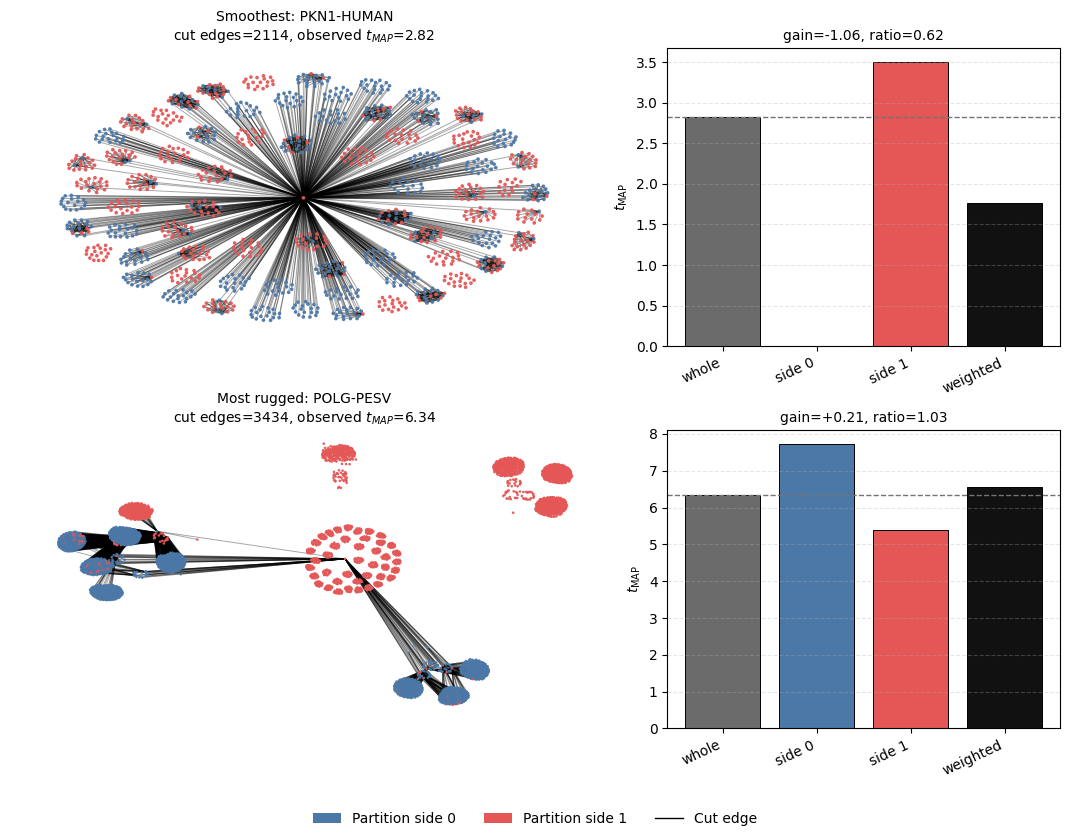

Figure written to: ../figures/figure_2/spectral_partition_examples_most_vs_smoothest.pdf


In [13]:
# Figure plot for spectral partitioning results: Single most rugged and single smoothest example, network graphs showing the partitioning and cut edges, and t_MAP values before and after partitioning.

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import spectral_boundary_experiments as sbe

if 'spectral_partition_domain_df' in globals():
    _spectral_examples_df = spectral_partition_domain_df.copy()
elif 'spectral_partition_domain_csv' in globals():
    _spectral_examples_df = pd.read_csv(spectral_partition_domain_csv)
else:
    raise RuntimeError('Run Experiment 9a first (requires spectral_partition_domain_df or spectral_partition_domain_csv).')

if '_reviewer_get_graph_layout' not in globals():
    def _reviewer_get_graph_layout(graph, cache_key, seed=0):
        cache = globals().setdefault('_reviewer_graph_layout_cache', {})
        if cache_key in cache:
            return cache[cache_key]

        pos = None
        for module_name in ('networkx.drawing.nx_agraph', 'networkx.drawing.nx_pydot'):
            try:
                graphviz_layout = __import__(module_name, fromlist=['graphviz_layout']).graphviz_layout
                pos = graphviz_layout(graph, prog='sfdp')
                break
            except Exception:
                continue

        if pos is None:
            try:
                pos = nx.spectral_layout(graph, dim=2)
                pos = nx.spring_layout(graph, seed=seed, pos=pos, iterations=40)
            except Exception:
                pos = nx.spring_layout(graph, seed=seed, iterations=80)

        pos = {int(node): np.asarray(coords, dtype=float)[:2] for node, coords in pos.items()}
        cache[cache_key] = pos
        return pos

work_df = _spectral_examples_df.loc[
    _spectral_examples_df['status'].eq('ok')
    & np.isfinite(_spectral_examples_df['observed_t_map'].to_numpy(dtype=float)),
].copy()
if len(work_df) < 2:
    raise RuntimeError('Need at least two successful spectral partitions for example plots.')

work_df = work_df.sort_values(['observed_t_map', 'dataset', 'file']).reset_index(drop=True)
example_rows = [
    ('Smoothest', work_df.iloc[0]),
    ('Most rugged', work_df.iloc[-1]),
]
side_palette = {0: '#4C78A8', 1: '#E45756'}
example_data = []

for label, row in example_rows:
    domain_df = load_domain_dataframe(row.file).reset_index(drop=True)
    landscape, fitness = build_hamming_landscape_from_df(domain_df)
    labels, edge_records, _ = sbe._spectral_build_cut(landscape.graph, fitness)
    cut_edges = [
        (int(rec['u']), int(rec['v']))
        for rec in edge_records
        if bool(rec['is_cut'])
    ]
    pos = _reviewer_get_graph_layout(
        landscape.graph,
        cache_key=(str(row.file), 'spectral_partition_boundary'),
        seed=1,
    )

    example_data.append(
        {
            'label': label,
            'dataset': str(row.dataset),
            'observed_t_map': float(row.observed_t_map),
            'post_partition_t_map': float(row.post_partition_t_map),
            'post_partition_t_map_ratio': float(row.post_partition_t_map_ratio),
            'side_0_t_map': float(row.side_0_t_map),
            'side_1_t_map': float(row.side_1_t_map),
            'graph': landscape.graph,
            'labels': labels,
            'cut_edges': cut_edges,
            'pos': pos,
        }
    )

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.8, 8.4),
    gridspec_kw={'width_ratios': [1.5, 1.0]},
)

for row_idx, ex in enumerate(example_data):
    ax_graph = axes[row_idx, 0]
    ax_bar = axes[row_idx, 1]
    graph = ex['graph']
    node_order = [int(node) for node in sorted(graph.nodes())]
    node_colors = [side_palette[int(ex['labels'][node])] for node in node_order]
    node_size = float(np.clip(250.0 / np.sqrt(max(len(node_order), 1)), 3.0, 10.0))

    if ex['cut_edges']:
        nx.draw_networkx_edges(
            graph,
            ex['pos'],
            ax=ax_graph,
            edgelist=ex['cut_edges'],
            edge_color='black',
            width=0.7,
            alpha=0.35,
        )
    nx.draw_networkx_nodes(
        graph,
        ex['pos'],
        ax=ax_graph,
        nodelist=node_order,
        node_color=node_colors,
        node_size=node_size,
        linewidths=0.0,
        alpha=0.95,
    )
    ax_graph.set_title(
        f"{ex['label']}: {ex['dataset']}\ncut edges={len(ex['cut_edges'])}, observed $t_{{MAP}}$={ex['observed_t_map']:.2f}",
        fontsize=10,
    )
    ax_graph.set_axis_off()

    bar_labels = ['whole', 'side 0', 'side 1', 'weighted']
    bar_values = [
        ex['observed_t_map'],
        ex['side_0_t_map'],
        ex['side_1_t_map'],
        ex['post_partition_t_map'],
    ]
    bar_colors = ['#6B6B6B', side_palette[0], side_palette[1], '#111111']
    bar_x = np.arange(len(bar_labels))

    ax_bar.bar(bar_x, bar_values, color=bar_colors, edgecolor='black', linewidth=0.7)
    ax_bar.axhline(ex['observed_t_map'], color='0.45', linestyle='--', linewidth=1.0)
    ax_bar.set_xticks(bar_x)
    ax_bar.set_xticklabels(bar_labels, rotation=25, ha='right')
    ax_bar.set_ylabel(r'$t_{\mathrm{MAP}}$')
    ax_bar.set_title(
        f"gain={ex['post_partition_t_map'] - ex['observed_t_map']:+.2f}, ratio={ex['post_partition_t_map_ratio']:.2f}",
        fontsize=10,
    )
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)

legend_handles = [
    Patch(facecolor=side_palette[0], edgecolor='none', label='Partition side 0'),
    Patch(facecolor=side_palette[1], edgecolor='none', label='Partition side 1'),
    Line2D([0], [0], color='black', linewidth=1.0, label='Cut edge'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'spectral_partition_examples_most_vs_smoothest.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


In [9]:
# SEARCH_TAG: SPECTRAL_CUT_DISTANCE_PROFILE
# Experiment 9b: edge energy as a function of graph distance from the spectral cut.
from pathlib import Path
import importlib
import spectral_boundary_experiments as sbe

importlib.reload(sbe)

spectral_profile_results = sbe.run_spectral_cut_distance_profile(
    spectral_partition_domain_df=spectral_partition_domain_df,
    spectral_partition_edge_csv=spectral_partition_edge_csv,
    outdir=Path('../figures/SI_figures/SI_figure_DMS'),
)

spectral_shell_profile_df = spectral_profile_results['profile_df']
spectral_shell_domain_df = spectral_profile_results['domain_df']
spectral_shell_assoc_df = spectral_profile_results['assoc_df']

print('Domains with shell profiles:', len(spectral_shell_domain_df))
if len(spectral_shell_assoc_df) > 0:
    display(spectral_shell_assoc_df)
display(spectral_shell_domain_df.sort_values('boundary_peak_enrichment', ascending=False))
print(f"Shell-profile summary written to: {spectral_profile_results['profile_csv']}")
print(f"Shell-domain summary written to: {spectral_profile_results['domain_csv']}")
print(f"Shell-profile figure written to: {spectral_profile_results['fig_path']}")


Domains with shell profiles: 63


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,boundary_peak_enrichment,-0.38254,0.001974,-0.387845,0.001685,63


,file,dataset,observed_t_map,cut_shell_norm_energy,near_shell_norm_energy,far_shell_norm_energy,boundary_peak_enrichment,max_shell_observed
9,DN7A_SACS2_Tsuboyama_2023_1JIC.csv,DN7A-SACS2,2.975646,2.647730,0.838458,0.128818,20.554022,2
60,VRPI_BPT7_Tsuboyama_2023_2WNM.csv,VRPI-BPT7,3.499704,2.598796,0.883506,0.144336,18.005181,2
41,RS15_GEOSE_Tsuboyama_2023_1A32.csv,RS15-GEOSE,3.140976,2.675000,0.743891,0.175748,15.220666,2
36,RCRO_LAMBD_Tsuboyama_2023_1ORC.csv,RCRO-LAMBD,4.840960,8.443415,1.274146,0.611087,13.817035,3
1,ARGR_ECOLI_Tsuboyama_2023_1AOY.csv,ARGR-ECOLI,3.315492,2.663993,0.745146,0.198752,13.403580,2
...,...,...,...,...,...,...,...,...
33,PSAE_SYNP2_Tsuboyama_2023_1PSE.csv,PSAE-SYNP2,4.116057,1.439995,1.063743,0.803121,1.793000,3
22,NKX31_HUMAN_Tsuboyama_2023_2L9R.csv,NKX31-HUMAN,4.586149,1.803613,0.642244,1.151866,1.565819,2
35,RCD1_ARATH_Tsuboyama_2023_5OAO.csv,RCD1-ARATH,3.140976,1.430726,0.867298,1.031946,1.386435,3
4,CATR_CHLRE_Tsuboyama_2023_2AMI.csv,CATR-CHLRE,4.116057,1.434011,0.735211,1.139491,1.258467,3


Shell-profile summary written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_distance_shell_profiles.csv
Shell-domain summary written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_distance_domain_metrics.csv
Shell-profile figure written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_distance_profile.pdf


In [ ]:
# Figure plot for spectral cut distance: Most rugged example showing the edge energy profile as a function of distance from the spectral cut, with the network graph and edges coloured by energy.

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import spectral_boundary_experiments as sbe

if 'spectral_shell_domain_df' in globals():
    _spectral_shell_examples_df = spectral_shell_domain_df.copy()
elif 'spectral_profile_results' in globals():
    _spectral_shell_examples_df = spectral_profile_results['domain_df'].copy()
else:
    raise RuntimeError('Run Experiment 9b first (requires spectral_shell_domain_df or spectral_profile_results).')

if 'spectral_shell_profile_df' in globals():
    _spectral_shell_profile_plot_df = spectral_shell_profile_df.copy()
elif 'spectral_profile_results' in globals():
    _spectral_shell_profile_plot_df = spectral_profile_results['profile_df'].copy()
else:
    raise RuntimeError('Run Experiment 9b first (requires spectral_shell_profile_df or spectral_profile_results).')

if '_reviewer_get_graph_layout' not in globals():
    def _reviewer_get_graph_layout(graph, cache_key, seed=0):
        cache = globals().setdefault('_reviewer_graph_layout_cache', {})
        if cache_key in cache:
            return cache[cache_key]

        pos = None
        for module_name in ('networkx.drawing.nx_agraph', 'networkx.drawing.nx_pydot'):
            try:
                graphviz_layout = __import__(module_name, fromlist=['graphviz_layout']).graphviz_layout
                pos = graphviz_layout(graph, prog='sfdp')
                break
            except Exception:
                continue

        if pos is None:
            try:
                pos = nx.spectral_layout(graph, dim=2)
                pos = nx.spring_layout(graph, seed=seed, pos=pos, iterations=40)
            except Exception:
                pos = nx.spring_layout(graph, seed=seed, iterations=80)

        pos = {int(node): np.asarray(coords, dtype=float)[:2] for node, coords in pos.items()}
        cache[cache_key] = pos
        return pos

work_df = _spectral_shell_examples_df.loc[
    np.isfinite(_spectral_shell_examples_df['observed_t_map'].to_numpy(dtype=float)),
].copy()
if len(work_df) == 0:
    raise RuntimeError('No shell-profile domains available for plotting.')

work_df = work_df.sort_values(['observed_t_map', 'dataset', 'file']).reset_index(drop=True)
example_row = work_df.iloc[-1]

profile_df = _spectral_shell_profile_plot_df.loc[
    _spectral_shell_profile_plot_df['file'].astype(str).eq(str(example_row.file))
].copy()
profile_df = profile_df.sort_values('shell_plot').reset_index(drop=True)
if len(profile_df) == 0:
    raise RuntimeError('No shell profile found for the selected rugged example.')

domain_df = load_domain_dataframe(example_row.file).reset_index(drop=True)
landscape, fitness = build_hamming_landscape_from_df(domain_df)
labels, edge_records, _ = sbe._spectral_build_cut(landscape.graph, fitness)
edge_df = pd.DataFrame(edge_records)
pos = _reviewer_get_graph_layout(
    landscape.graph,
    cache_key=(str(example_row.file), 'spectral_cut_distance_energy'),
    seed=2,
)

side_palette = {0: '#4C78A8', 1: '#E45756'}
node_order = [int(node) for node in sorted(landscape.graph.nodes())]
node_colors = [side_palette[int(labels[node])] for node in node_order]
node_size = float(np.clip(250.0 / np.sqrt(max(len(node_order), 1)), 3.0, 10.0))

edges = list(zip(edge_df['u'].astype(int), edge_df['v'].astype(int)))
energy_raw = np.maximum(edge_df['edge_energy'].to_numpy(dtype=float), 1e-12)
energy_plot = np.log10(energy_raw)
cut_mask = edge_df['is_cut'].to_numpy(dtype=bool)
noncut_mask = ~cut_mask
norm = plt.Normalize(
    vmin=float(np.nanpercentile(energy_plot, 5)),
    vmax=float(np.nanpercentile(energy_plot, 99)),
)
edge_rgba = plt.cm.magma(norm(energy_plot))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.6),
    gridspec_kw={'width_ratios': [1.35, 1.0]},
)
ax_graph, ax_profile = axes

if np.any(noncut_mask):
    nx.draw_networkx_edges(
        landscape.graph,
        pos,
        ax=ax_graph,
        edgelist=[edges[i] for i in np.flatnonzero(noncut_mask)],
        edge_color=[edge_rgba[i] for i in np.flatnonzero(noncut_mask)],
        width=0.2,
        alpha=0.35,
    )
if np.any(cut_mask):
    nx.draw_networkx_edges(
        landscape.graph,
        pos,
        ax=ax_graph,
        edgelist=[edges[i] for i in np.flatnonzero(cut_mask)],
        edge_color=[edge_rgba[i] for i in np.flatnonzero(cut_mask)],
        width=0.85,
        alpha=0.95,
    )
nx.draw_networkx_nodes(
    landscape.graph,
    pos,
    ax=ax_graph,
    nodelist=node_order,
    node_color=node_colors,
    node_size=node_size,
    linewidths=0.0,
    alpha=0.9,
)
ax_graph.set_title(
    f"Most rugged: {example_row.dataset}\nobserved $t_{{MAP}}$={float(example_row.observed_t_map):.2f}",
    fontsize=10,
)
ax_graph.set_axis_off()

shell_x = profile_df['shell_plot'].to_numpy(dtype=int)
shell_y = profile_df['mean_edge_energy_norm'].to_numpy(dtype=float)
ax_profile.plot(shell_x, shell_y, color='black', linewidth=1.5, marker='o')
ax_profile.axhline(1.0, color='0.5', linestyle='--', linewidth=1.0)
ax_profile.set_xlabel('Graph distance from spectral cut')
ax_profile.set_ylabel('Mean edge energy / domain mean')
ax_profile.set_xticks(shell_x)
ax_profile.set_xticklabels([
    str(x) if x < int(getattr(sbe, 'SPECTRAL_MAX_SHELL_PLOT', 6)) else f"{int(getattr(sbe, 'SPECTRAL_MAX_SHELL_PLOT', 6))}+"
    for x in shell_x
])
ax_profile.set_title(
    f"peak enrichment={float(example_row.boundary_peak_enrichment):.2f}",
    fontsize=10,
)
ax_profile.grid(axis='y', linestyle='--', alpha=0.3)

sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.magma)
sm.set_array([])
fig.colorbar(sm, ax=ax_graph, fraction=0.046, pad=0.02, label=r'$\log_{10}$(edge energy)')

legend_handles = [
    Patch(facecolor=side_palette[0], edgecolor='none', label='Partition side 0'),
    Patch(facecolor=side_palette[1], edgecolor='none', label='Partition side 1'),
    Line2D([0], [0], color='black', linewidth=1.2, label='Shell profile'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'spectral_cut_distance_most_rugged_example.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,boundary_peak_enrichment,-0.382601,0.00197,-0.387845,0.001685,63


In [ ]:
# Figure plot for spectral bipartitioning: paired dot plot of mean edge energy on vs off the cut.

from pathlib import Path

if 'spectral_partition_domain_df' in globals():
    _spectral_pair_df = spectral_partition_domain_df.copy()
elif 'spectral_partition_results' in globals():
    _spectral_pair_df = spectral_partition_results['domain_df'].copy()
else:
    raise RuntimeError('Run Experiment 9a first (requires spectral_partition_domain_df or spectral_partition_results).')

work_df = _spectral_pair_df.loc[
    _spectral_pair_df['status'].eq('ok')
    & np.isfinite(_spectral_pair_df['mean_edge_energy_all'].to_numpy(dtype=float))
    & np.isfinite(_spectral_pair_df['mean_edge_energy_cut'].to_numpy(dtype=float))
    & np.isfinite(_spectral_pair_df['mean_edge_energy_noncut'].to_numpy(dtype=float))
    & (_spectral_pair_df['mean_edge_energy_all'].to_numpy(dtype=float) > 0),
    [
        'dataset',
        'file',
        'observed_t_map',
        'mean_edge_energy_all',
        'mean_edge_energy_cut',
        'mean_edge_energy_noncut',
    ],
].copy()
if len(work_df) == 0:
    raise RuntimeError('No valid spectral bipartition edge-energy summaries available for plotting.')

work_df = work_df.sort_values(['observed_t_map', 'dataset', 'file']).reset_index(drop=True)
work_df['cut_mean_norm'] = work_df['mean_edge_energy_cut'] / work_df['mean_edge_energy_all']
work_df['noncut_mean_norm'] = work_df['mean_edge_energy_noncut'] / work_df['mean_edge_energy_all']

x = np.array([0.0, 1.0], dtype=float)

fig, ax = plt.subplots(figsize=(3.3, 4.0))
for row in work_df.itertuples(index=False):
    y = np.asarray([row.cut_mean_norm, row.noncut_mean_norm], dtype=float)
    ax.plot(x, y, color='0.85', linewidth=1.0, alpha=0.9, zorder=1)

ax.scatter(
    np.full(len(work_df), x[0]),
    work_df['cut_mean_norm'].to_numpy(dtype=float),
    s=52,
    color='#4C78A8',
    edgecolor='none',
    zorder=3,
)
ax.scatter(
    np.full(len(work_df), x[1]),
    work_df['noncut_mean_norm'].to_numpy(dtype=float),
    s=52,
    color='#E45756',
    edgecolor='none',
    zorder=3,
)

ax.axhline(1.0, color='0.9', linestyle='--', linewidth=1.0, zorder=0)
ax.set_xlim(-0.15, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(['Bipartition
edges', 'Off
bipartition'])
ax.set_ylabel('Mean edge energy / domain mean')
ax.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'spectral_bipartition_edge_energy_paired.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


In [ ]:
# Figure plot for at, near, far profiles energies for all landscapes as lineplot, with each landscape as a separate line.

from pathlib import Path

if 'spectral_shell_domain_df' in globals():
    _spectral_profile_line_df = spectral_shell_domain_df.copy()
elif 'spectral_profile_results' in globals():
    _spectral_profile_line_df = spectral_profile_results['domain_df'].copy()
else:
    raise RuntimeError('Run Experiment 9b first (requires spectral_shell_domain_df or spectral_profile_results).')

work_df = _spectral_profile_line_df.loc[
    np.isfinite(_spectral_profile_line_df['observed_t_map'].to_numpy(dtype=float))
    & np.isfinite(_spectral_profile_line_df['cut_shell_norm_energy'].to_numpy(dtype=float))
    & np.isfinite(_spectral_profile_line_df['near_shell_norm_energy'].to_numpy(dtype=float))
    & np.isfinite(_spectral_profile_line_df['far_shell_norm_energy'].to_numpy(dtype=float)),
    [
        'dataset',
        'file',
        'observed_t_map',
        'cut_shell_norm_energy',
        'near_shell_norm_energy',
        'far_shell_norm_energy',
    ],
].copy()
if len(work_df) == 0:
    raise RuntimeError('No valid at/near/far shell profiles available for plotting.')

work_df = work_df.sort_values(['observed_t_map', 'dataset', 'file']).reset_index(drop=True)
x = np.arange(3)
xticklabels = ['At cut', 'Near', 'Far']

fig, ax = plt.subplots(figsize=(5.4, 3.6))
for row in work_df.itertuples(index=False):
    y = np.asarray([
        row.cut_shell_norm_energy,
        row.near_shell_norm_energy,
        row.far_shell_norm_energy,
    ], dtype=float)
    ax.plot(x, y, color='0.45', linewidth=0.9, alpha=0.45)

ax.axhline(1.0, color='0.2', linestyle='--', linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Distance bin from spectral cut')
ax.set_ylabel('Mean edge energy / domain mean')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
out_dir = Path('../figures/figure_2')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'spectral_cut_at_near_far_profiles_all_domains.pdf'
plt.savefig(out_path)
plt.show()
print(f'Figure written to: {out_path}')


In [10]:
# SEARCH_TAG: SPECTRAL_CHEEGER_ENRICHMENT
# Experiment 9c: Cheeger-style enrichment of Dirichlet energy on the spectral cut.
from pathlib import Path
import importlib
import spectral_boundary_experiments as sbe

importlib.reload(sbe)

spectral_cheeger_results = sbe.run_spectral_cheeger_enrichment(
    spectral_partition_domain_df=spectral_partition_domain_df,
    outdir=Path('../figures/SI_figures/SI_figure_DMS'),
)

spectral_cheeger_df = spectral_cheeger_results['summary_df']
spectral_cheeger_stats_df = spectral_cheeger_results['stats_df']

print('Median cut-energy enrichment:', float(spectral_cheeger_df['cut_energy_enrichment'].median()))
print('Domains with enrichment > 1:', int((spectral_cheeger_df['cut_energy_enrichment'] > 1).sum()), '/', len(spectral_cheeger_df))
display(spectral_cheeger_df.sort_values('cut_energy_enrichment', ascending=False))
display(spectral_cheeger_stats_df)
print(f"Cheeger-style summary written to: {spectral_cheeger_results['summary_csv']}")
print(f"Cheeger-style stats written to: {spectral_cheeger_results['stats_csv']}")
print(f"Cheeger-style figure written to: {spectral_cheeger_results['fig_path']}")


Median cut-energy enrichment: 2.8346267562627654
Domains with enrichment > 1: 62 / 63


,dataset,file,observed_t_map,cut_edge_fraction,cut_energy_fraction,cut_energy_enrichment,n_cut_edges,n_edges,partition_balance,log2_cut_energy_enrichment
16,RCRO-LAMBD,RCRO_LAMBD_Tsuboyama_2023_1ORC.csv,4.840960,0.030603,0.258390,8.443415,1028,33592,0.999123,3.077827
22,SPA-STAAU,SPA_STAAU_Tsuboyama_2023_1LP1.csv,4.586149,0.020831,0.150792,7.238948,656,31492,1.000000,2.855780
6,DNJA1-HUMAN,DNJA1_HUMAN_Tsuboyama_2023_2LO1.csv,5.393842,0.026790,0.185224,6.913887,871,32512,0.999117,2.789497
41,NUSG-MYCTU,NUSG_MYCTU_Tsuboyama_2023_2MI6.csv,3.694151,0.033701,0.211275,6.269045,580,17210,0.998553,2.648246
7,VILI-CHICK,VILI_CHICK_Tsuboyama_2023_1YU5.csv,5.393842,0.013864,0.074542,5.376606,529,38156,0.999222,2.426696
...,...,...,...,...,...,...,...,...,...,...
15,PR40A-HUMAN,PR40A_HUMAN_Tsuboyama_2023_1UZC.csv,4.840960,0.064173,0.110910,1.728296,1719,26787,1.000000,0.789350
33,PSAE-SYNP2,PSAE_SYNP2_Tsuboyama_2023_1PSE.csv,4.116057,0.144492,0.208067,1.439995,2728,18880,1.000000,0.526064
34,CATR-CHLRE,CATR_CHLRE_Tsuboyama_2023_2AMI.csv,4.116057,0.107312,0.153887,1.434011,2329,21703,1.000000,0.520056
54,RCD1-ARATH,RCD1_ARATH_Tsuboyama_2023_5OAO.csv,3.140976,0.117596,0.168248,1.430726,1501,12764,1.000000,0.516747


,test,statistic,p_value,n_domains,pearson_r,pearson_p,spearman_rho,spearman_p
0,wilcoxon_greater_than_1,2015.0,2.711739e-12,63,NaN,NaN,NaN,NaN
1,correlation_with_t_map,NaN,NaN,63,0.268713,0.033216,0.256588,0.042362


Cheeger-style summary written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_cheeger_enrichment_summary.csv
Cheeger-style stats written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_cheeger_enrichment_stats.csv
Cheeger-style figure written to: ../figures/SI_figures/SI_figure_DMS/spectral_cut_cheeger_enrichment.pdf


In [27]:
# SEARCH_TAG: SVD_SPECTRAL_BOUNDARY_ALIGNMENT
# Experiment 9d: overlap between spectral cut edges and SVD-limiter boundaries.
from pathlib import Path
import numpy as np
import importlib
import spectral_boundary_experiments as sbe

SVD_SPECTRAL_OVERLAP_N_PERM = 500
SVD_SPECTRAL_OVERLAP_SEED = 2026

required = [
    'dms_tmap_df',
    'load_domain_dataframe',
    '_build_limiter_svd_model',
    '_assign_limiter_to_sequence',
    'spectral_partition_edge_csv',
]
missing_required = [name for name in required if name not in globals()]
if missing_required:
    raise RuntimeError(f'Run prerequisite cells first; missing symbols: {missing_required}')

importlib.reload(sbe)

svd_spectral_overlap_results = sbe.run_svd_spectral_boundary_alignment(
    dms_tmap_df=dms_tmap_df,
    load_domain_dataframe=load_domain_dataframe,
    build_limiter_svd_model=_build_limiter_svd_model,
    assign_limiter_to_sequence=_assign_limiter_to_sequence,
    spectral_partition_edge_csv=spectral_partition_edge_csv,
    outdir=Path('../figures/SI_figures/SI_figure_DMS'),
    n_permutations=SVD_SPECTRAL_OVERLAP_N_PERM,
    seed=SVD_SPECTRAL_OVERLAP_SEED,
    load_null_samples=False,
)

svd_spectral_overlap_domain_df = svd_spectral_overlap_results['domain_df']
svd_spectral_overlap_assoc_df = svd_spectral_overlap_results['assoc_df']
svd_spectral_overlap_stats_df = svd_spectral_overlap_results['stats_df']
svd_spectral_overlap_null_csv = svd_spectral_overlap_results['null_csv']

print('Domains processed:', len(svd_spectral_overlap_domain_df))
print(
    'Domains with successful overlap analysis:',
    int((svd_spectral_overlap_domain_df['status'] == 'ok').sum()),
)
print(
    'Domains with Fisher p<0.05:',
    int((svd_spectral_overlap_domain_df['fisher_p_greater'] < 0.05).sum()),
    '/',
    int(np.isfinite(svd_spectral_overlap_domain_df['fisher_p_greater']).sum()),
)
display(
    svd_spectral_overlap_domain_df[
        [
            'dataset', 'observed_t_map', 'status', 'frac_edges_with_both_labels',
            'jaccard_overlap', 'odds_ratio_raw', 'log_odds_ratio_corrected',
            'fisher_p_greater', 'frac_cut_edges_svd_boundary',
            'perm_p_log_odds_ratio_corrected_greater', 'error',
        ]
    ].sort_values('log_odds_ratio_corrected', ascending=False)
)
if len(svd_spectral_overlap_assoc_df) > 0:
    display(svd_spectral_overlap_assoc_df)
if len(svd_spectral_overlap_stats_df) > 0:
    display(svd_spectral_overlap_stats_df)
print(f"SVD/spectral overlap domain summary written to: {svd_spectral_overlap_results['domain_csv']}")
print(f"SVD/spectral overlap association summary written to: {svd_spectral_overlap_results['assoc_csv']}")
print(f"SVD/spectral overlap stats written to: {svd_spectral_overlap_results['stats_csv']}")
print(f"SVD/spectral overlap null samples written to: {svd_spectral_overlap_null_csv}")
print(f"SVD/spectral overlap figure written to: {svd_spectral_overlap_results['fig_path']}")


SVD/spectral overlap:   0%|          | 0/63 [00:00<?, ?it/s]

Domains processed: 63
Domains with successful overlap analysis: 63
Domains with Fisher p<0.05: 45 / 63


,dataset,observed_t_map,status,frac_edges_with_both_labels,jaccard_overlap,odds_ratio_raw,log_odds_ratio_corrected,fisher_p_greater,frac_cut_edges_svd_boundary,perm_p_log_odds_ratio_corrected_greater,error
41,NUSG-MYCTU,3.694151,ok,0.940790,0.020759,4.064710,1.387550,7.131875e-17,0.884000,0.001996,
35,CUE1-YEAST,4.116057,ok,0.953889,0.027958,3.157770,1.143104,8.035386e-21,0.857143,0.001996,
18,SR43C-ARATH,4.840960,ok,0.959933,0.034040,2.923764,1.068550,3.070143e-25,0.835420,0.001996,
19,TCRG1-MOUSE,4.840960,ok,0.951834,0.026854,2.776832,1.012135,1.671591e-11,0.832685,0.001996,
3,YNZC-BACSU,5.693530,ok,0.980290,0.024449,2.756262,1.011204,9.257583e-30,0.787832,0.001996,
...,...,...,...,...,...,...,...,...,...,...,...
42,SAV1-MOUSE,3.694151,ok,0.937500,0.007670,0.874664,-0.140980,7.603615e-01,0.638554,0.662675,
26,NKX31-HUMAN,4.586149,ok,0.969020,0.092392,0.867093,-0.142668,9.999798e-01,0.566879,1.000000,
20,UBE4B-HUMAN,4.586149,ok,0.978921,0.029463,0.853690,-0.158309,9.992629e-01,0.553497,0.992016,
1,SDA-BACSU,6.009869,ok,0.981456,0.083975,0.828140,-0.188567,1.000000e+00,0.499203,0.998004,


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,jaccard_overlap,-0.554740,0.000002,-0.564571,0.000001,63
1,frac_cut_edges_svd_boundary,-0.444588,0.000262,-0.354874,0.004319,63
2,log_odds_ratio_corrected,0.128124,0.316962,0.163553,0.200261,63


,test,statistic,p_value,n_domains,median_value,n_significant,expected_under_null,mean_value
0,wilcoxon_log_odds_ratio_corrected_greater_than_0,1907.0,3.762231e-10,63,0.362701,NaN,NaN,NaN
1,count_fisher_p_greater_lt_0.05,NaN,2.983887e-44,63,NaN,45.0,3.15,NaN
2,median_log_odds_ratio_corrected,NaN,NaN,63,0.362701,NaN,NaN,0.411294
3,median_jaccard_overlap,NaN,NaN,63,0.063258,NaN,NaN,0.072262
4,median_frac_cut_edges_svd_boundary,NaN,NaN,63,0.762126,NaN,NaN,0.731370


SVD/spectral overlap domain summary written to: ../figures/SI_figures/SI_figure_DMS/svd_spectral_boundary_overlap_domain_summary.csv
SVD/spectral overlap association summary written to: ../figures/SI_figures/SI_figure_DMS/svd_spectral_boundary_overlap_associations.csv
SVD/spectral overlap stats written to: ../figures/SI_figures/SI_figure_DMS/svd_spectral_boundary_overlap_stats.csv
SVD/spectral overlap null samples written to: ../figures/SI_figures/SI_figure_DMS/svd_spectral_boundary_overlap_null_samples.csv
SVD/spectral overlap figure written to: ../figures/SI_figures/SI_figure_DMS/svd_spectral_boundary_overlap_summary.pdf
